In [1]:
# ===================================================================
# THESIS: Predictive Performance Evaluation and Interpretation 
#         Validity of the TabNet Model for Forecasting IHSG
# PAPER: A Hybrid Attentive-Convolutional Architecture for 
#        Financial Time Series Forecasting
# PIPELINE: TabNet | LSTM | TCN | TabNet-LSTM | TabNet-TCN | XGBoost
# VERSION: 5.0 - Fully Modular Implementation
# ===================================================================

import warnings
warnings.filterwarnings('ignore')

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from functools import wraps
from typing import Tuple, Dict, List, Optional

# Data & Preprocessing
import yfinance as yf
from fredapi import Fred
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

# Statistical Tests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim import Adam, AdamW

# TabNet
from pytorch_tabnet.tab_model import TabNetRegressor
from pytorch_tabnet.abstract_model import TabModel

# Hyperparameter Optimization
import optuna
optuna.logging.set_verbosity(optuna.logging.INFO)

# Statistical Tests
from scipy import stats
from scipy.stats import wilcoxon, ttest_rel, norm, shapiro, normaltest

# XGBoost
from xgboost import XGBRegressor

# ===================================================================
# GLOBAL CONFIGURATION (MINIMAL - No Model-Specific Settings)
# ===================================================================

class Config:
    # Reproducibility
    SEED = 42
    
    # Hardware
    NUM_THREADS = 12
    NUM_WORKERS = 8
    DEVICE = torch.device('cpu')
    DTYPE = torch.float32
    
    # Data
    START_DATE = "2010-01-01"
    FRED_API_KEY = 'eceded1789eb5832d183da55288beb80'
    
    # Training
    TRAIN_SPLIT = 0.8
    N_SPLITS = 3  # TimeSeriesSplit
    
    # Forecasting Horizons
    HORIZONS = {
        '1-day': 1,
        '3-day': 3,
        '5-day': 5
    }
    
    # Timesteps to test
    TIMESTEP_CANDIDATES = [30, 60, 90]
    
    # Economic Analysis - Based on Indonesian Market Conditions (2024)
    # Transaction costs include: broker fees (0.15-0.19%), VAT (0.011%), 
    # exchange fees (0.004%), and settlement fees (0.01%)
    # Total typical cost: ~0.19% + 0.011% + 0.004% + 0.01% ≈ 0.215%
    # We use conservative 0.1% (0.001) for round-trip transaction
    TRANSACTION_COST = 0.001  # 0.1% per transaction
    
    # Risk-free rate based on Indonesian Government Bond 10-year yield
    # As of 2024, Indonesia's 10Y bond yield is approximately 6.5-7.0%
    # We use 6% as conservative estimate
    RISK_FREE_RATE = 0.06  # 6% annual (Indonesian 10Y Govt Bond)
    
    # Output
    OUTPUT_DIR = 'exports'
    os.makedirs(f'{OUTPUT_DIR}/data', exist_ok=True)
    os.makedirs(f'{OUTPUT_DIR}/models', exist_ok=True)
    os.makedirs(f'{OUTPUT_DIR}/visualizations', exist_ok=True)
    os.makedirs(f'{OUTPUT_DIR}/eda', exist_ok=True)

config = Config()

# Set seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(config.SEED)
torch.set_num_threads(config.NUM_THREADS)

# Plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)
plt.rcParams['font.size'] = 10

print("="*70)
print("PYTORCH TABNET-TCN HYBRID FOR IHSG FORECASTING")
print("="*70)
print(f"Device: {config.DEVICE}")
print(f"Threads: {config.NUM_THREADS}")
print(f"Workers: {config.NUM_WORKERS}")
print(f"Seed: {config.SEED}")
print(f"Transaction Cost: {config.TRANSACTION_COST*100}% per trade")
print(f"Risk-Free Rate: {config.RISK_FREE_RATE*100}% annual")
print("="*70)

# ===================================================================
# SECTION 1: DATA ACQUISITION WITH RETRY LOGIC
# ===================================================================

def retry_on_failure(max_retries=3, delay=2, backoff=2, exceptions=(Exception,)):
    """Decorator for retrying functions that may fail"""
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            _delay = delay
            for attempt in range(max_retries + 1):
                try:
                    return func(*args, **kwargs)
                except exceptions as e:
                    if attempt == max_retries:
                        print(f"✗ Failed after {max_retries} retries: {str(e)}")
                        raise
                    print(f"  Attempt {attempt + 1}/{max_retries + 1} failed: {str(e)}")
                    print(f"  Retrying in {_delay} seconds...")
                    time.sleep(_delay)
                    _delay *= backoff
            return None
        return wrapper
    return decorator


@retry_on_failure(max_retries=3, delay=3, backoff=2, exceptions=(Exception,))
def fetch_yahoo_data(tickers, start_date, end_date, data_type='Close'):
    """Fetch data from Yahoo Finance with retry logic"""
    print(f"  Fetching {data_type} data for {len(tickers)} tickers...")
    
    data = yf.download(
        tickers=tickers,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False,
    )
    
    if data.empty:
        raise ValueError(f"No data returned for {data_type}")
    
    if data_type in data.columns.levels[0]:
        result = data[data_type].copy()
    else:
        raise ValueError(f"Data type '{data_type}' not found")
    
    print(f"  ✓ Successfully fetched {data_type} data: {result.shape}")
    return result


@retry_on_failure(max_retries=3, delay=2, backoff=2, exceptions=(Exception,))
def fetch_fred_series(fred_client, series_name, series_id, start_date, end_date):
    """Fetch a single FRED series with retry logic"""
    print(f"  Fetching {series_name} ({series_id})...")
    
    series_data = fred_client.get_series(
        series_id,
        observation_start=start_date,
        observation_end=end_date
    )
    
    if series_data is None or len(series_data) == 0:
        raise ValueError(f"No data returned for {series_name}")
    
    print(f"  ✓ Successfully fetched {series_name}: {len(series_data)} observations")
    return series_data


print("\n" + "="*70)
print("SECTION 1: DATA ACQUISITION")
print("="*70)

end_date = datetime.now().strftime('%Y-%m-%d')
print(f"\nDate range: {config.START_DATE} to {end_date}")

# Market Variables
variables = {
    # Global & Regional Indices
    "IHSG": "^JKSE",
    "S&P 500": "^GSPC",
    "VIX": "^VIX",
    "Hang Seng": "^HSI",
    "Nikkei 225": "^N225",
    "Shanghai": "000001.SS",
    "FTSE 100": "^FTSE",
    
    # Commodities
    "Crude Oil (Brent)": "BZ=F",
    "Gold": "GC=F",
    "Natural Gas": "NG=F",
    "Coal": "MTF=F",
    "Palm Oil": "EWM",
    "Nickel": "VALE",
    "Copper": "HG=F",
    
    # Currencies
    "USD/IDR": "IDR=X",
    "EUR/USD": "EURUSD=X",
    "GBP/USD": "GBPUSD=X",
    "USD/JPY": "JPY=X"
}

# Fetch Yahoo Finance data
print("\n[1.1] Fetching market data from Yahoo Finance...")
all_tickers = list(variables.values())

try:
    close_data = fetch_yahoo_data(all_tickers, config.START_DATE, end_date, 'Close')
    volume_data = fetch_yahoo_data(all_tickers, config.START_DATE, end_date, 'Volume')
    
    # Rename columns
    reverse_map = {v: k for k, v in variables.items()}
    close_data.rename(columns=reverse_map, inplace=True)
    volume_data.rename(columns={v: f"{k}_Volume" for k, v in reverse_map.items()}, inplace=True)
    
    # Combine
    data = close_data.join(volume_data)
    print(f"\n✓ Yahoo Finance data acquired: {data.shape}")
    
except Exception as e:
    print(f"\n✗ FATAL: Yahoo Finance acquisition failed: {e}")
    raise

print("\n[1.2] Top 5 rows after data fetch:")
print(data.head())

# Fetch FRED data
print("\n[1.3] Fetching FRED data...")
fred = Fred(api_key=config.FRED_API_KEY)

fred_series = {
    'Federal Funds Rate': 'FEDFUNDS',
    'BI Rate': 'INTDSRIDM193N'
}

fred_data = {}
for name, series_id in fred_series.items():
    try:
        series_data = fetch_fred_series(fred, name, series_id, config.START_DATE, end_date)
        fred_data[name] = series_data
    except Exception as e:
        print(f"✗ Failed to fetch {name}: {e}")

if fred_data:
    fred_df = pd.DataFrame(fred_data)
    data = data.join(fred_df)
    print(f"\n✓ FRED data merged: {len(fred_data)} series")

print(f"\n✓ Combined data shape: {data.shape}")

# ===================================================================
# SECTION 2: DATA PREPROCESSING
# ===================================================================

print("\n" + "="*70)
print("SECTION 2: DATA PREPROCESSING")
print("="*70)

# Remove columns with all NaN
initial_cols = data.shape[1]
data.dropna(axis=1, how='all', inplace=True)
dropped_cols = initial_cols - data.shape[1]
if dropped_cols > 0:
    print(f"\n✓ Removed {dropped_cols} empty columns")

# Handle missing values: ffill then bfill
print("\n[2.1] Handling missing values with ffill → bfill...")
missing_before = data.isnull().sum().sum()
data = data.ffill().bfill()
missing_after = data.isnull().sum().sum()
print(f"  Missing values before: {missing_before:,}")
print(f"  Missing values after: {missing_after:,}")

# Feature Engineering (Technical Indicators FIRST)
print("\n[2.2] Creating technical indicators on original prices...")
exp1 = data['IHSG'].ewm(span=12, adjust=False).mean()
exp2 = data['IHSG'].ewm(span=26, adjust=False).mean()
data['MACD'] = exp1 - exp2
data['MACD_Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()

delta = data['IHSG'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

data['BB_Middle'] = data['IHSG'].rolling(window=20).mean()
bb_std = data['IHSG'].rolling(window=20).std()
data['BB_Upper'] = data['BB_Middle'] + (bb_std * 2)
data['BB_Lower'] = data['BB_Middle'] - (bb_std * 2)

data['SMA_5'] = data['IHSG'].rolling(window=5).mean()
data['SMA_20'] = data['IHSG'].rolling(window=20).mean()
data['EMA_12'] = data['IHSG'].ewm(span=12, adjust=False).mean()
print(f"✓ Created 9 technical indicators")

# Create target variable (future returns) BEFORE converting other features
print("\n[2.3] Creating target variable (percentage returns)...")
data['Target'] = data['IHSG'].pct_change().shift(-1)

# Convert price/level features to stationary returns
print("\n[2.4] Converting price-based features to percentage returns...")
price_columns = [
    "S&P 500", "VIX", "Hang Seng", "Nikkei 225", "Shanghai", "FTSE 100",
    "Crude Oil (Brent)", "Gold", "Natural Gas", "Coal", "Palm Oil", "Nickel", "Copper",
    "USD/IDR", "EUR/USD", "GBP/USD", "USD/JPY"
]

for col in price_columns:
    if col in data.columns and col != 'Target':
        data[f'{col}_return'] = data[col].pct_change()

# Drop original price columns (except IHSG for reconstruction)
feature_price_cols_to_drop = [p for p in price_columns if p in data.columns]
data.drop(columns=feature_price_cols_to_drop, inplace=True, errors='ignore')

# Lagged Features
print("\n[2.5] Creating lagged features...")
lag_features = ['S&P 500_return', 'VIX_return', 'Gold_return', 'Crude Oil (Brent)_return', 'USD/IDR_return']
for col in lag_features:
    if col in data.columns:
        for lag in [1, 5]:
            data[f'{col}_lag{lag}'] = data[col].shift(lag)
print(f"✓ Created lagged features")

# Time Features
print("\n[2.6] Creating time features...")
data['DayOfWeek'] = data.index.dayofweek
data['Month'] = data.index.month
data['Quarter'] = data.index.quarter
data['DayOfMonth'] = data.index.day
data['WeekOfYear'] = data.index.isocalendar().week.astype(np.int64)

# Clean up any NaNs
data.replace([np.inf, -np.inf], np.nan, inplace=True)
initial_rows = len(data)
data = data.dropna()
dropped_rows = initial_rows - len(data)
print(f"\n✓ Dropped {dropped_rows} total rows with NaN")
print(f"✓ Final data shape: {data.shape}")

# Save the transformed data
data.to_csv(f'{config.OUTPUT_DIR}/data/01_preprocessed_data_stationary.csv')
print(f"\n✓ Saved: {config.OUTPUT_DIR}/data/01_preprocessed_data_stationary.csv")


PYTORCH TABNET-TCN HYBRID FOR IHSG FORECASTING
Device: cpu
Threads: 12
Workers: 8
Seed: 42
Transaction Cost: 0.1% per trade
Risk-Free Rate: 6.0% annual

SECTION 1: DATA ACQUISITION

Date range: 2010-01-01 to 2025-10-12

[1.1] Fetching market data from Yahoo Finance...
  Fetching Close data for 18 tickers...
  ✓ Successfully fetched Close data: (4116, 18)
  Fetching Volume data for 18 tickers...
  ✓ Successfully fetched Volume data: (4116, 18)

✓ Yahoo Finance data acquired: (4116, 36)

[1.2] Top 5 rows after data fetch:
Ticker         Shanghai  Crude Oil (Brent)   EUR/USD   Palm Oil   GBP/USD  \
Date                                                                        
2010-01-01          NaN                NaN  1.438994        NaN  1.613294   
2010-01-04  3243.760010          80.120003  1.442398  43.759998  1.611370   
2010-01-05  3282.178955          80.589996  1.436596  44.320000  1.599079   
2010-01-06  3254.215088          81.889999  1.440403  44.400002  1.602384   
2010-01-07  


SECTION 2.5: ENHANCED EXPLORATORY DATA ANALYSIS (EDA)

[2.5.0] Feature columns identified: 61 features
['000001.SS', 'BZ=F', 'EURUSD=X', 'EWM', 'GBPUSD=X', 'GC=F', 'HG=F', 'IDR=X', 'JPY=X', 'MTF=F', 'NG=F', 'VALE', '^FTSE', '^GSPC', '^HSI', '^JKSE', '^N225', '^VIX', 'Federal Funds Rate', 'BI Rate', 'MACD', 'MACD_Signal', 'RSI', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'SMA_5', 'SMA_20', 'EMA_12', 'S&P 500_return', 'VIX_return', 'Hang Seng_return', 'Nikkei 225_return', 'Shanghai_return', 'FTSE 100_return', 'Crude Oil (Brent)_return', 'Gold_return', 'Natural Gas_return', 'Coal_return', 'Palm Oil_return', 'Nickel_return', 'Copper_return', 'USD/IDR_return', 'EUR/USD_return', 'GBP/USD_return', 'USD/JPY_return', 'S&P 500_return_lag1', 'S&P 500_return_lag5', 'VIX_return_lag1', 'VIX_return_lag5', 'Gold_return_lag1', 'Gold_return_lag5', 'Crude Oil (Brent)_return_lag1', 'Crude Oil (Brent)_return_lag5', 'USD/IDR_return_lag1', 'USD/IDR_return_lag5', 'DayOfWeek', 'Month', 'Quarter', 'DayOfMonth', 'Wee

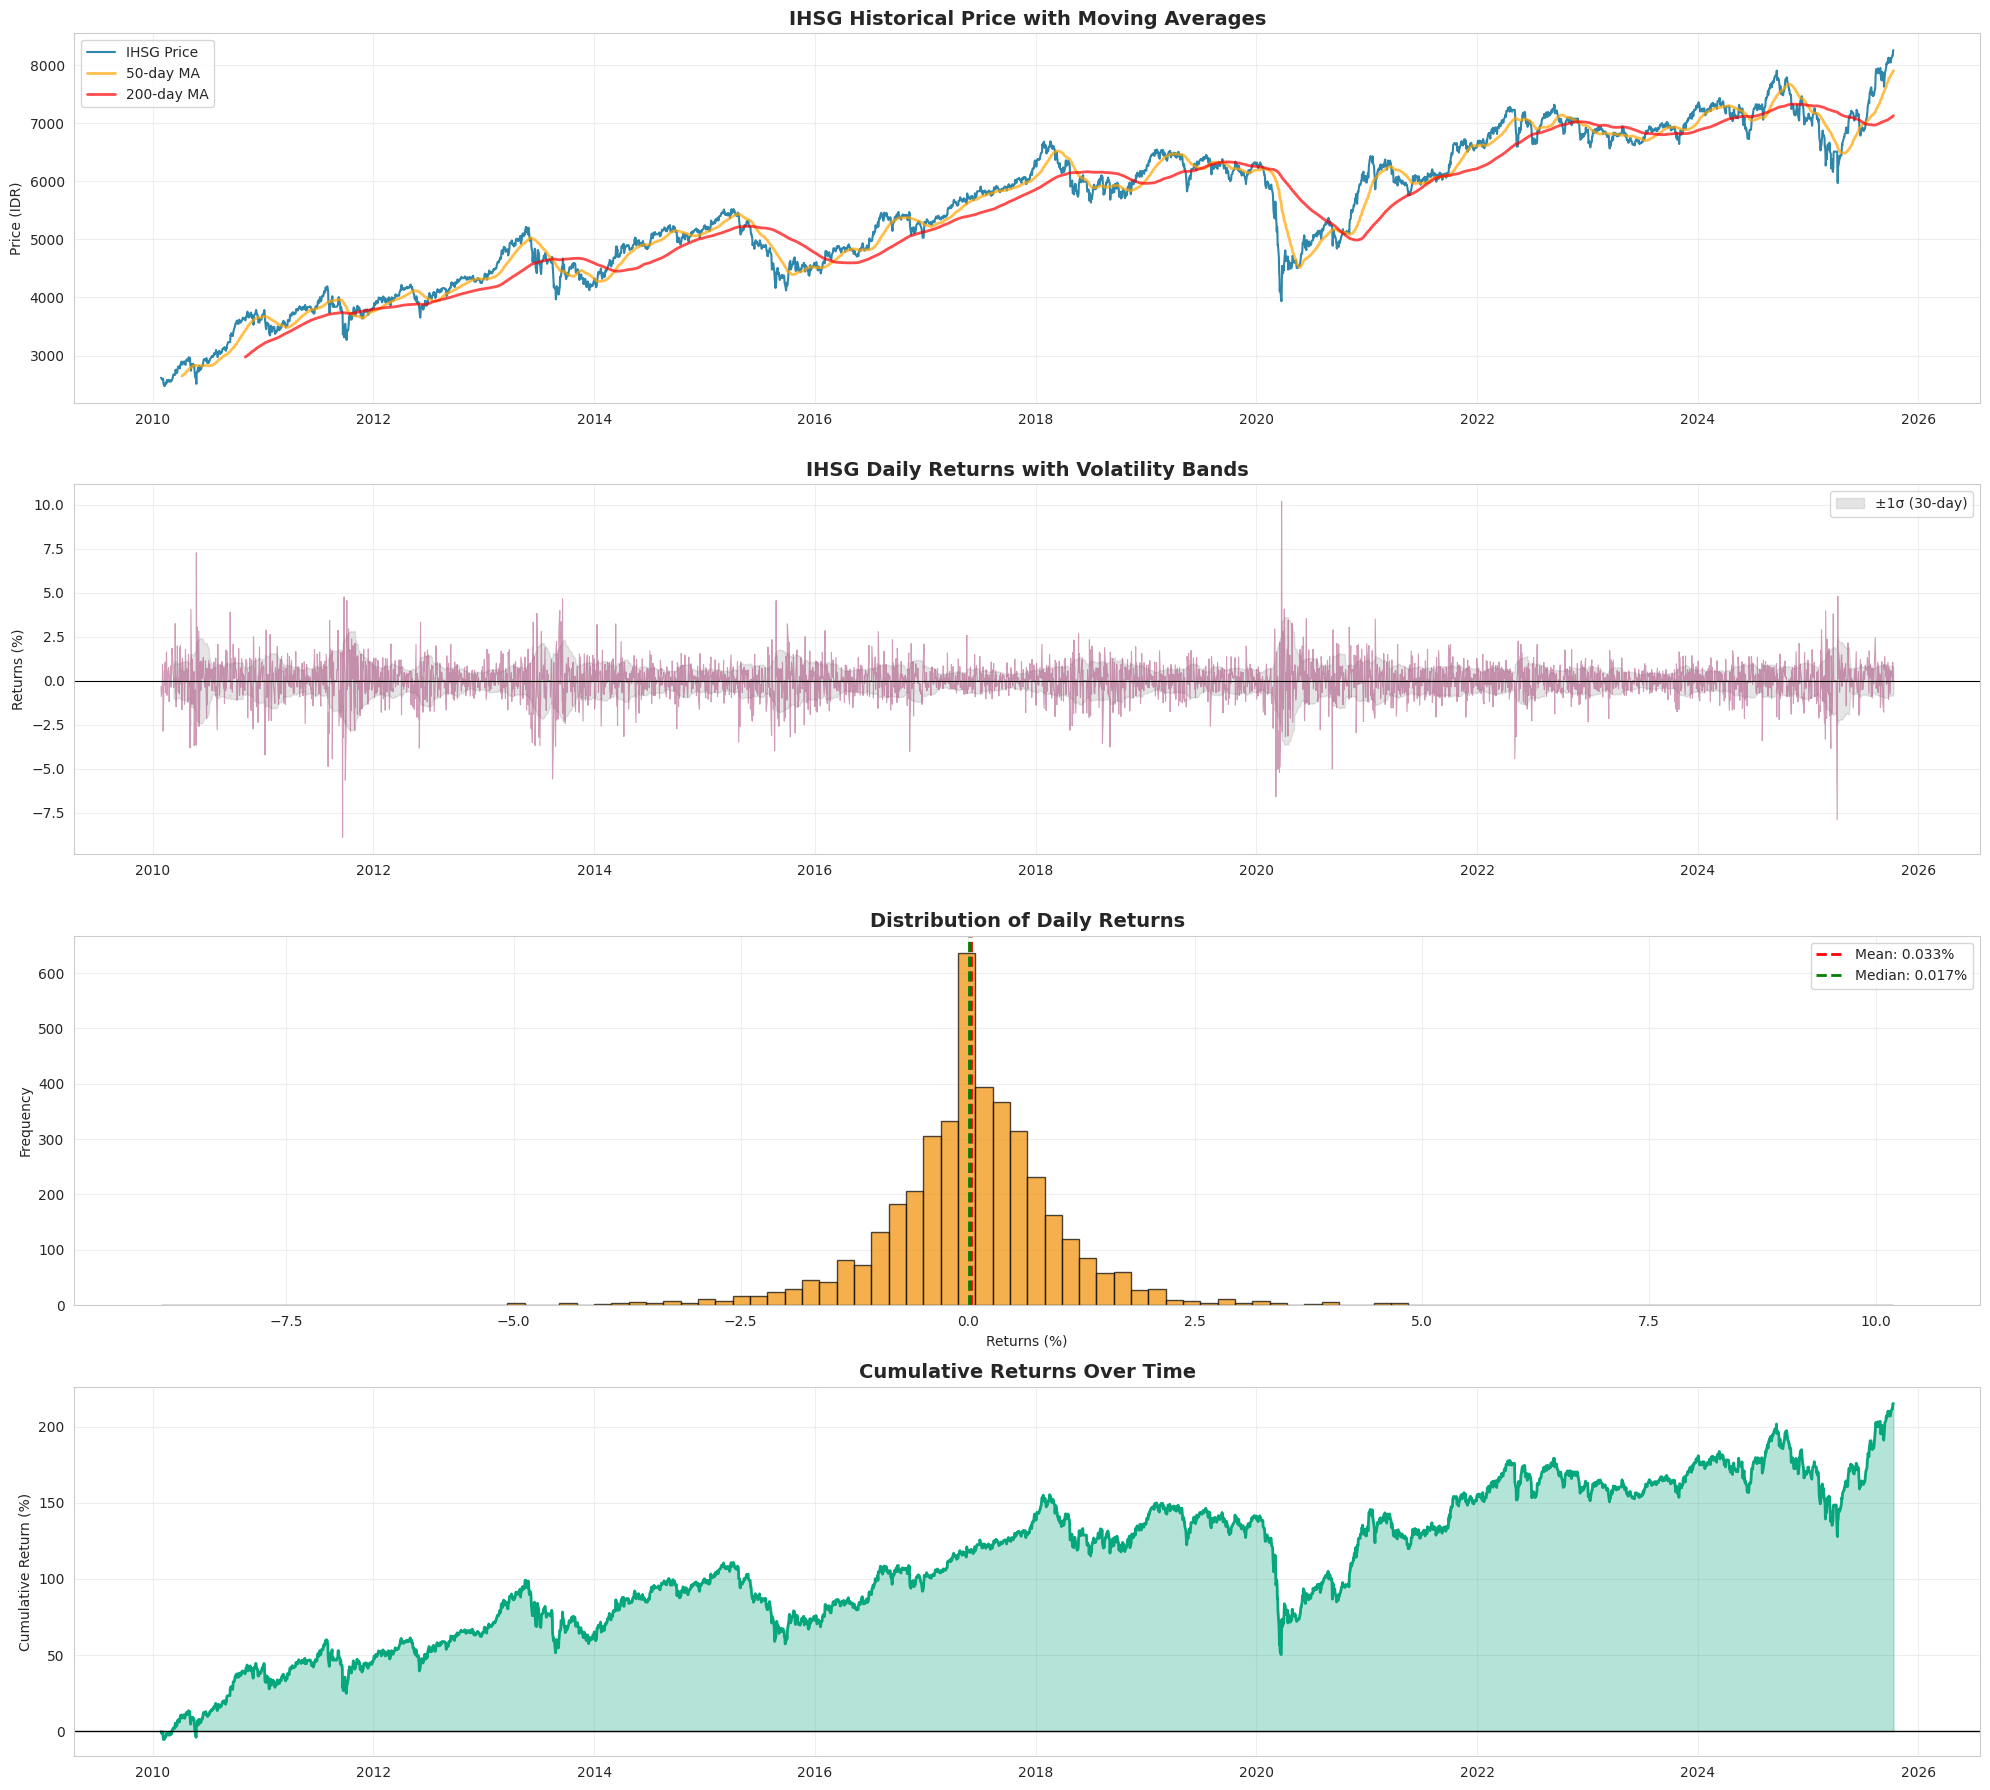

✓ Saved: eda/02_ihsg_timeseries_enhanced.png

[2.5.3] Market Regime Analysis

[Market Regime Statistics]
         Count  Mean_Return_%  Std_Return_%  Min_Return_%  Max_Return_%
Regime                                                                 
Bear      1638      -0.811844      0.821888     -8.880362     -0.052653
Bull      1638       0.867134      0.700765      0.217311     10.190686
Neutral    820       0.055415      0.074044     -0.052254      0.217065

Interpretation:
  • Bull Market Days: 1638 (40.0%)
  • Bear Market Days: 1638 (40.0%)
  • Neutral Days: 820 (20.0%)

✓ Saved: eda/03_market_regime_analysis.csv

[2.5.4] Enhanced Correlation Analysis
✓ Analyzing correlations for features in the dataset...
  Total numeric features available: 58
  Selected 27 features for visualization
  Feature categories:
    - Technical Indicators: 9
    - Return Features: 15
    - Rate Features: 2
    - Lag Features: 5


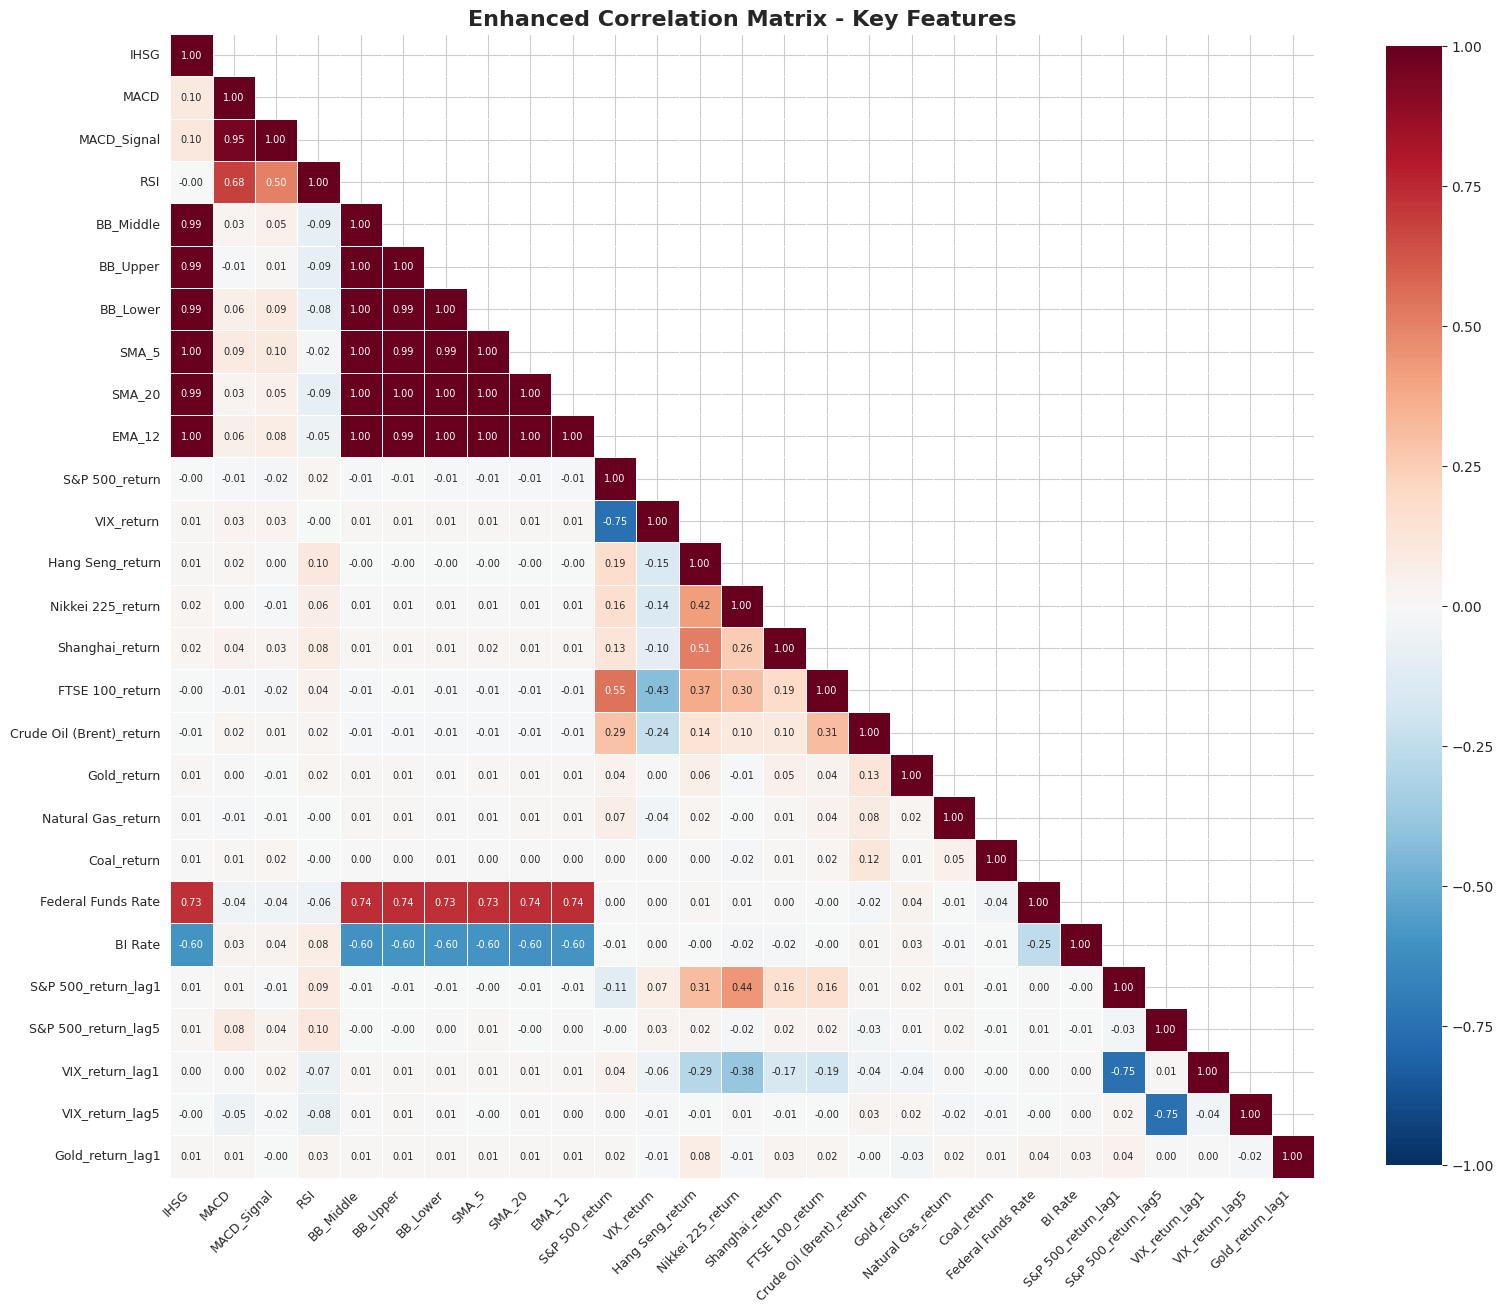

✓ Saved: eda/04_correlation_heatmap_enhanced.png

[Creating full correlation matrix for ALL features...]
  Full correlation matrix size: (58, 58)
✓ Saved: eda/04_correlation_matrix_full.csv (complete correlation matrix)

[Top 30 Features Correlated with IHSG]
IHSG                   1.000000
SMA_5                  0.998931
EMA_12                 0.997842
BB_Middle              0.994796
SMA_20                 0.994796
BB_Lower               0.992807
BB_Upper               0.989443
Federal Funds Rate     0.732322
BZ=F                   0.621471
000001.SS              0.610062
^HSI                   0.400901
VALE                   0.228578
^JKSE                  0.175261
NG=F                   0.145026
MACD_Signal            0.102482
MACD                   0.100275
^GSPC                  0.053552
Shanghai_return        0.021917
USD/JPY_return         0.020054
Nikkei 225_return      0.016314
Gold_return_lag5       0.016192
WeekOfYear             0.014888
Gold_return_lag1       0.013980
S&P 

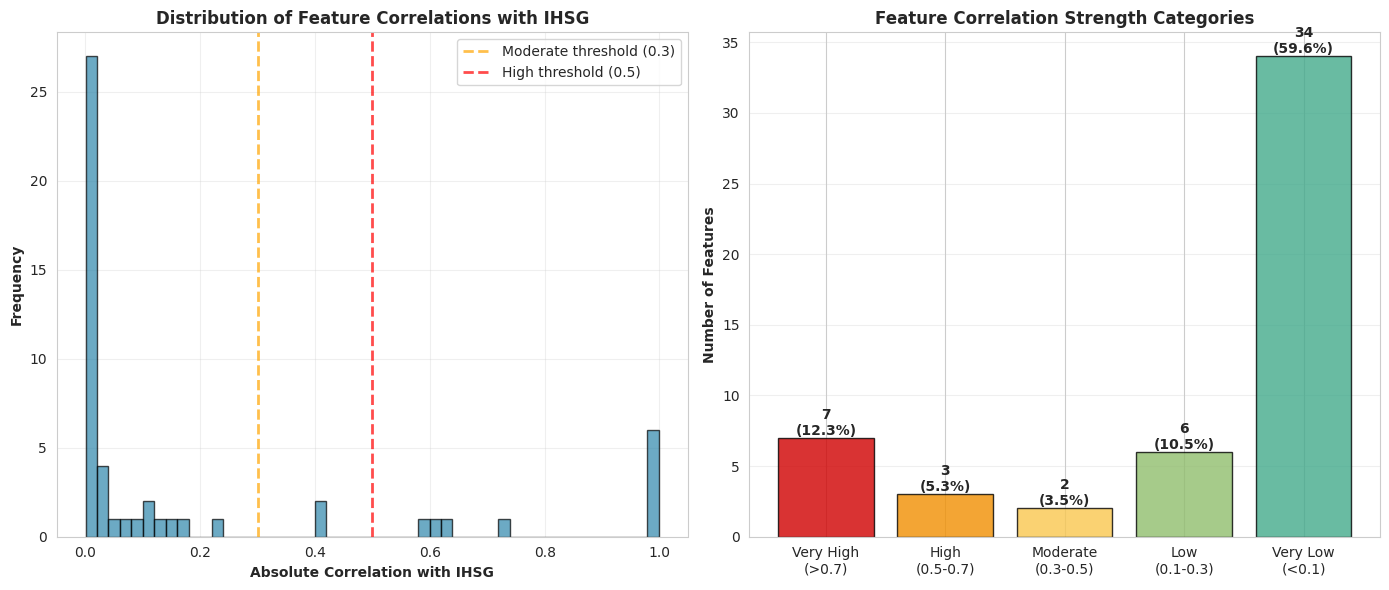

✓ Saved: eda/05_correlation_distribution.png

[Feature Category Correlation Summary]

Correlation by Feature Category:
                      Mean_Abs_Corr  Max_Abs_Corr  Feature_Count
Category                                                        
Technical Indicators          0.686         0.999              9
Interest Rates                0.665         0.732              2
Other Market Data             0.237         0.621             12
Currencies                    0.019         0.027              6
Global Markets                0.016         0.084             11
Temporal                      0.015         0.015              1
Commodities                   0.007         0.016             11

✓ Saved: eda/05_correlation_by_category.csv

[Interpretation]:
  • Highest average correlation: Technical Indicators (mean=0.686)
  • This suggests technical indicators features are most linearly related to IHSG

✓ Enhanced correlation analysis complete with ALL features

[2.5.5] Multicollinear

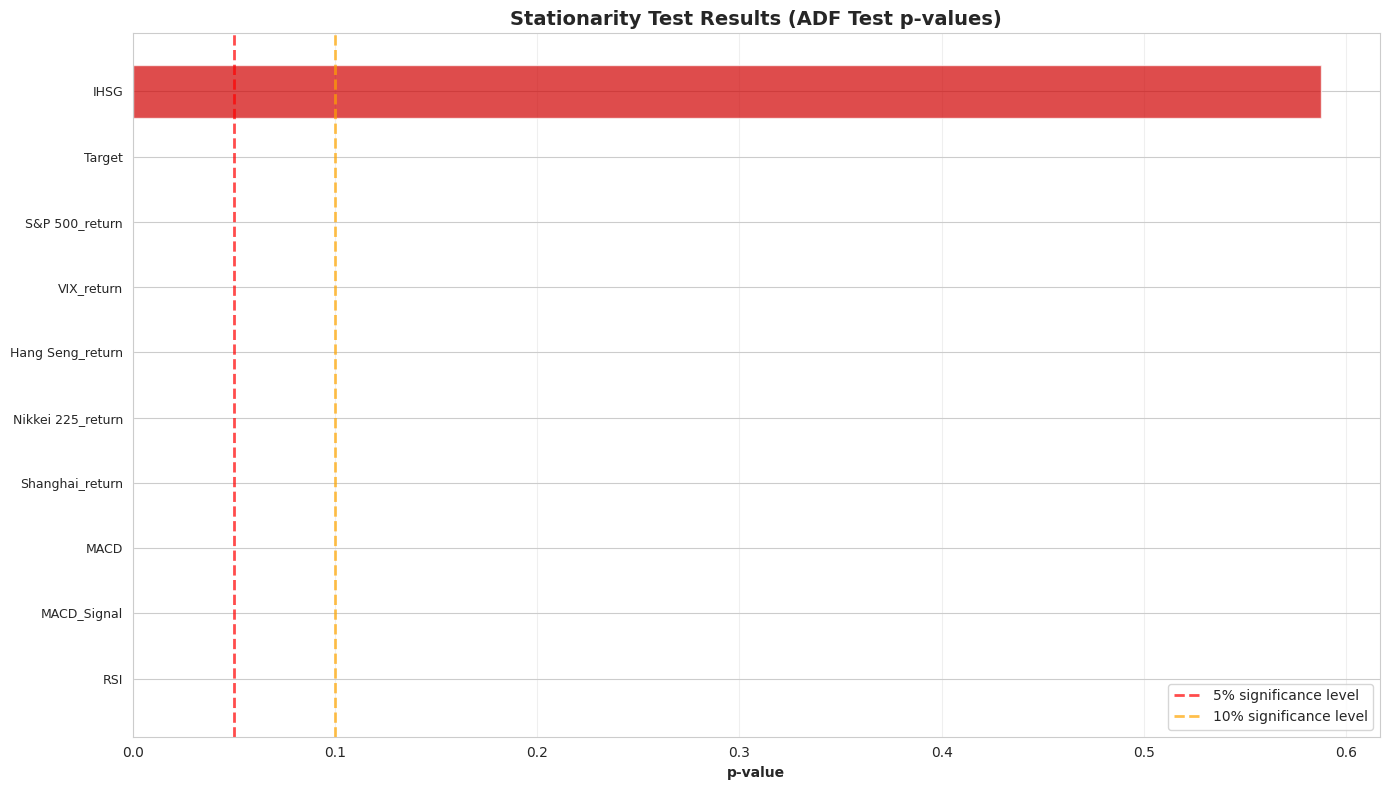

✓ Saved: eda/07_stationarity_visualization.png

ENHANCED EDA COMPLETE


In [18]:
# ===================================================================
# SECTION 2.5: ENHANCED EXPLORATORY DATA ANALYSIS (EDA)
# ===================================================================

print("\n" + "="*70)
print("SECTION 2.5: ENHANCED EXPLORATORY DATA ANALYSIS (EDA)")
print("="*70)

# Build feature_cols list BEFORE using it
feature_cols = [col for col in data.columns if col not in ['IHSG', 'Target']]

print(f"\n[2.5.0] Feature columns identified: {len(feature_cols)} features")
print(feature_cols)

# ---------------------------------------------------------------
# 2.5.1 Dataset Overview with Statistical Summary
# ---------------------------------------------------------------
print("\n[2.5.1] Comprehensive Dataset Overview")

print(f"\nDataset Shape: {data.shape}")
print(f"Date Range: {data.index[0].date()} to {data.index[-1].date()}")
print(f"Total Trading Days: {len(data)}")
print(f"Number of Features: {len(feature_cols)}")

# Target Variable Comprehensive Statistics
print("\n[Target Variable Analysis - IHSG Returns]")
target_stats = data['Target'].describe()
print(target_stats)

# Additional statistical measures
print(f"\nSkewness: {data['Target'].skew():.4f}")
print(f"Kurtosis: {data['Target'].kurtosis():.4f}")
print(f"Interpretation:")
if abs(data['Target'].skew()) < 0.5:
    print("  - Distribution is approximately symmetric")
elif data['Target'].skew() > 0:
    print("  - Distribution is right-skewed (positive tail)")
else:
    print("  - Distribution is left-skewed (negative tail)")

if data['Target'].kurtosis() > 3:
    print("  - Heavy-tailed distribution (more extreme values than normal)")
elif data['Target'].kurtosis() < 3:
    print("  - Light-tailed distribution (fewer extreme values than normal)")

# Save enhanced overview
overview_df = pd.DataFrame({
    'Metric': ['Start Date', 'End Date', 'Total Days', 'Features', 
               'Min IHSG', 'Max IHSG', 'Mean IHSG', 'Std IHSG',
               'Target Skewness', 'Target Kurtosis', 'Target Volatility (Std)'],
    'Value': [
        data.index[0].date(),
        data.index[-1].date(),
        len(data),
        len(feature_cols),
        f"{data['IHSG'].min():.2f}",
        f"{data['IHSG'].max():.2f}",
        f"{data['IHSG'].mean():.2f}",
        f"{data['IHSG'].std():.2f}",
        f"{data['Target'].skew():.4f}",
        f"{data['Target'].kurtosis():.4f}",
        f"{data['Target'].std():.4f}"
    ]
})
overview_df.to_csv(f'{config.OUTPUT_DIR}/eda/01_dataset_overview_enhanced.csv', index=False)
print("\n✓ Saved: eda/01_dataset_overview_enhanced.csv")

# ---------------------------------------------------------------
# 2.5.2 Enhanced Time Series Visualization with Regime Analysis
# ---------------------------------------------------------------
print("\n[2.5.2] Enhanced Time Series Visualization")

fig, axes = plt.subplots(4, 1, figsize=(20, 18))

# Plot 1: IHSG Price with Moving Averages
axes[0].plot(data.index, data['IHSG'], linewidth=1.5, color='#2E86AB', label='IHSG Price')
axes[0].plot(data.index, data['IHSG'].rolling(50).mean(), 
             linewidth=2, color='orange', alpha=0.7, label='50-day MA')
axes[0].plot(data.index, data['IHSG'].rolling(200).mean(), 
             linewidth=2, color='red', alpha=0.7, label='200-day MA')
axes[0].set_title('IHSG Historical Price with Moving Averages', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (IDR)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Daily Returns with Volatility Regimes
daily_returns = data['Target'] * 100
rolling_vol = daily_returns.rolling(30).std()
axes[1].plot(data.index, daily_returns, linewidth=0.8, color='#A23B72', alpha=0.5)
axes[1].fill_between(data.index, rolling_vol, -rolling_vol, alpha=0.2, color='gray', label='±1σ (30-day)')
axes[1].set_title('IHSG Daily Returns with Volatility Bands', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Returns (%)')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Plot 3: Return Distribution
axes[2].hist(daily_returns, bins=100, color='#F18F01', alpha=0.7, edgecolor='black')
axes[2].axvline(daily_returns.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {daily_returns.mean():.3f}%')
axes[2].axvline(daily_returns.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {daily_returns.median():.3f}%')
axes[2].set_title('Distribution of Daily Returns', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Returns (%)')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Plot 4: Cumulative Returns
cumulative_returns = (1 + data['Target']).cumprod() - 1
axes[3].plot(data.index, cumulative_returns * 100, linewidth=2, color='#06A77D')
axes[3].fill_between(data.index, 0, cumulative_returns * 100, alpha=0.3, color='#06A77D')
axes[3].set_title('Cumulative Returns Over Time', fontsize=14, fontweight='bold')
axes[3].set_ylabel('Cumulative Return (%)')
axes[3].grid(True, alpha=0.3)
axes[3].axhline(y=0, color='black', linestyle='-', linewidth=1)

plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/eda/02_ihsg_timeseries_enhanced.png', dpi=600, bbox_inches='tight')
plt.show()
print("✓ Saved: eda/02_ihsg_timeseries_enhanced.png")

# ---------------------------------------------------------------
# 2.5.3 Market Regime Analysis
# ---------------------------------------------------------------
print("\n[2.5.3] Market Regime Analysis")

# Define regimes based on returns
bull_threshold = data['Target'].quantile(0.60)
bear_threshold = data['Target'].quantile(0.40)

regime = []
for ret in data['Target']:
    if ret > bull_threshold:
        regime.append('Bull')
    elif ret < bear_threshold:
        regime.append('Bear')
    else:
        regime.append('Neutral')

data_temp = data.copy()
data_temp['Regime'] = regime

regime_stats = data_temp.groupby('Regime')['Target'].agg([
    ('Count', 'count'),
    ('Mean_Return_%', lambda x: x.mean() * 100),
    ('Std_Return_%', lambda x: x.std() * 100),
    ('Min_Return_%', lambda x: x.min() * 100),
    ('Max_Return_%', lambda x: x.max() * 100)
])

print("\n[Market Regime Statistics]")
print(regime_stats)
print("\nInterpretation:")
print(f"  • Bull Market Days: {regime_stats.loc['Bull', 'Count']} ({regime_stats.loc['Bull', 'Count']/len(data)*100:.1f}%)")
print(f"  • Bear Market Days: {regime_stats.loc['Bear', 'Count']} ({regime_stats.loc['Bear', 'Count']/len(data)*100:.1f}%)")
print(f"  • Neutral Days: {regime_stats.loc['Neutral', 'Count']} ({regime_stats.loc['Neutral', 'Count']/len(data)*100:.1f}%)")

regime_stats.to_csv(f'{config.OUTPUT_DIR}/eda/03_market_regime_analysis.csv')
print("\n✓ Saved: eda/03_market_regime_analysis.csv")

# ---------------------------------------------------------------
# 2.5.4 Enhanced Correlation Analysis with Interpretation
# ---------------------------------------------------------------
print("\n[2.5.4] Enhanced Correlation Analysis")

# IMPORTANT: We need to include ALL features that actually exist in the data
# Not just the original variable names, but also transformed features

# Build a comprehensive list of features actually in the dataset
print(f"✓ Analyzing correlations for features in the dataset...")

# Get all numeric features (exclude IHSG and Target)
all_numeric_features = [col for col in data.columns 
                       if col not in ['Target'] and data[col].dtype in ['float64', 'int64']]

print(f"  Total numeric features available: {len(all_numeric_features)}")

# Filter to most relevant features for visualization
# Include: IHSG, technical indicators, and top return features
technical_indicators = ['MACD', 'MACD_Signal', 'RSI', 'BB_Middle', 
                        'BB_Upper', 'BB_Lower', 'SMA_5', 'SMA_20', 'EMA_12']

# Get return-based features
return_features = [col for col in all_numeric_features if 'return' in col.lower()]

# Get rate features
rate_features = [col for col in all_numeric_features if 'rate' in col.lower() or 'BI' in col or 'Federal' in col]

# Get volume features (first few)
volume_features = [col for col in all_numeric_features if 'volume' in col.lower()][:3]

# Get lag features (first few)
lag_features = [col for col in all_numeric_features if 'lag' in col.lower()][:5]

# Combine all feature categories
selected_features = ['IHSG']  # Start with IHSG

# Add technical indicators that exist
selected_features.extend([f for f in technical_indicators if f in data.columns])

# Add top return features (limit to avoid overcrowding)
selected_features.extend(return_features[:10])

# Add rate features
selected_features.extend([f for f in rate_features if f in data.columns])

# Add some lag features
selected_features.extend([f for f in lag_features if f in data.columns])

# Add some volume features
selected_features.extend([f for f in volume_features if f in data.columns])

# Remove duplicates while preserving order
selected_features = list(dict.fromkeys(selected_features))

# Ensure all selected features exist
selected_features = [f for f in selected_features if f in data.columns]

print(f"  Selected {len(selected_features)} features for visualization")
print(f"  Feature categories:")
print(f"    - Technical Indicators: {len([f for f in selected_features if f in technical_indicators])}")
print(f"    - Return Features: {len([f for f in selected_features if 'return' in f])}")
print(f"    - Rate Features: {len([f for f in selected_features if 'rate' in f.lower() or 'BI' in f or 'Federal' in f])}")
print(f"    - Lag Features: {len([f for f in selected_features if 'lag' in f])}")

# Create correlation matrix
correlation_data = data[selected_features].copy()
corr_matrix = correlation_data.corr()

# Enhanced heatmap with better size management
fig_width = max(16, len(selected_features) * 0.6)
fig_height = max(14, len(selected_features) * 0.55)

plt.figure(figsize=(fig_width, fig_height))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# Adjust annotation size based on number of features
annot_size = 7 if len(selected_features) > 20 else 8 if len(selected_features) > 15 else 9

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=.5,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": annot_size})
plt.title('Enhanced Correlation Matrix - Key Features', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/eda/04_correlation_heatmap_enhanced.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: eda/04_correlation_heatmap_enhanced.png")

# ---------------------------------------------------------------
# Additional: Full correlation matrix for ALL features (saved to CSV)
# ---------------------------------------------------------------
print("\n[Creating full correlation matrix for ALL features...]")

# Create full correlation matrix (may be large)
full_corr_matrix = data[all_numeric_features].corr()

print(f"  Full correlation matrix size: {full_corr_matrix.shape}")

# Save full matrix to CSV for detailed analysis
full_corr_matrix.to_csv(f'{config.OUTPUT_DIR}/eda/04_correlation_matrix_full.csv')
print("✓ Saved: eda/04_correlation_matrix_full.csv (complete correlation matrix)")

# ---------------------------------------------------------------
# Top correlations with IHSG (from all features)
# ---------------------------------------------------------------
if 'IHSG' in full_corr_matrix.columns:
    ihsg_corr = full_corr_matrix['IHSG'].sort_values(ascending=False)
    
    print("\n[Top 30 Features Correlated with IHSG]")
    print(ihsg_corr.head(31).to_string())  # 31 to include IHSG itself
    
    print("\n[Interpretation of Key Correlations]:")
    
    # Positive correlations (excluding IHSG itself)
    top_positive = ihsg_corr[ihsg_corr > 0].iloc[1:6]  # Skip IHSG itself, get top 5
    if len(top_positive) > 0:
        print(f"\nStrongest Positive Correlations:")
        for feat, corr_val in top_positive.items():
            # Identify feature type
            if 'return' in feat:
                feat_type = "(Return feature)"
            elif any(ind in feat for ind in ['MACD', 'RSI', 'BB_', 'SMA', 'EMA']):
                feat_type = "(Technical indicator)"
            elif 'lag' in feat:
                feat_type = "(Lagged feature)"
            else:
                feat_type = ""
            print(f"  • {feat} {feat_type}: {corr_val:.3f}")
    
    # Negative correlations
    top_negative = ihsg_corr[ihsg_corr < 0].head(5)
    if len(top_negative) > 0:
        print(f"\nStrongest Negative Correlations:")
        for feat, corr_val in top_negative.items():
            if 'return' in feat:
                feat_type = "(Return feature)"
            elif any(ind in feat for ind in ['MACD', 'RSI', 'BB_', 'SMA', 'EMA']):
                feat_type = "(Technical indicator)"
            elif 'lag' in feat:
                feat_type = "(Lagged feature)"
            elif 'VIX' in feat:
                feat_type = "(Volatility index - inverse relationship expected)"
            else:
                feat_type = ""
            print(f"  • {feat} {feat_type}: {corr_val:.3f}")
    
    # Save correlation summary
    corr_summary = pd.DataFrame({
        'Feature': ihsg_corr.index,
        'Correlation_with_IHSG': ihsg_corr.values,
        'Abs_Correlation': abs(ihsg_corr.values)
    }).sort_values('Abs_Correlation', ascending=False)
    
    corr_summary.to_csv(f'{config.OUTPUT_DIR}/eda/05_correlation_summary.csv', index=False)
    print("\n✓ Saved: eda/05_correlation_summary.csv")
    
    # ---------------------------------------------------------------
    # Correlation Strength Distribution
    # ---------------------------------------------------------------
    print("\n[Correlation Strength Distribution with IHSG]")
    
    # Categorize correlations (excluding IHSG itself)
    corr_values = abs(ihsg_corr.values[1:])  # Exclude IHSG's self-correlation
    
    very_high = sum(corr_values > 0.7)
    high = sum((corr_values > 0.5) & (corr_values <= 0.7))
    moderate = sum((corr_values > 0.3) & (corr_values <= 0.5))
    low = sum((corr_values > 0.1) & (corr_values <= 0.3))
    very_low = sum(corr_values <= 0.1)
    
    print(f"  Very High (>0.7): {very_high} features ({very_high/len(corr_values)*100:.1f}%)")
    print(f"  High (0.5-0.7): {high} features ({high/len(corr_values)*100:.1f}%)")
    print(f"  Moderate (0.3-0.5): {moderate} features ({moderate/len(corr_values)*100:.1f}%)")
    print(f"  Low (0.1-0.3): {low} features ({low/len(corr_values)*100:.1f}%)")
    print(f"  Very Low (<0.1): {very_low} features ({very_low/len(corr_values)*100:.1f}%)")
    
    # Visualization of correlation distribution
    plt.figure(figsize=(14, 6))
    
    # Plot 1: Histogram of absolute correlations
    plt.subplot(1, 2, 1)
    plt.hist(abs(ihsg_corr.values[1:]), bins=50, color='#2E86AB', alpha=0.7, edgecolor='black')
    plt.axvline(x=0.3, color='orange', linestyle='--', linewidth=2, label='Moderate threshold (0.3)', alpha=0.7)
    plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='High threshold (0.5)', alpha=0.7)
    plt.xlabel('Absolute Correlation with IHSG', fontweight='bold')
    plt.ylabel('Frequency', fontweight='bold')
    plt.title('Distribution of Feature Correlations with IHSG', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Bar chart of correlation categories
    plt.subplot(1, 2, 2)
    categories = ['Very High\n(>0.7)', 'High\n(0.5-0.7)', 'Moderate\n(0.3-0.5)', 'Low\n(0.1-0.3)', 'Very Low\n(<0.1)']
    counts = [very_high, high, moderate, low, very_low]
    colors_cat = ['#D00000', '#F18F01', '#F9C74F', '#90BE6D', '#43AA8B']
    
    plt.bar(categories, counts, color=colors_cat, alpha=0.8, edgecolor='black')
    plt.ylabel('Number of Features', fontweight='bold')
    plt.title('Feature Correlation Strength Categories', fontsize=12, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (cat, count) in enumerate(zip(categories, counts)):
        plt.text(i, count, f'{count}\n({count/len(corr_values)*100:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f'{config.OUTPUT_DIR}/eda/05_correlation_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: eda/05_correlation_distribution.png")

else:
    print("\n⚠ Warning: IHSG not found in correlation matrix")

# ---------------------------------------------------------------
# Feature Category Correlation Summary
# ---------------------------------------------------------------
print("\n[Feature Category Correlation Summary]")

def categorize_feature_for_corr(feature_name):
    """Categorize features for correlation analysis - FIXED VERSION"""
    feature_lower = feature_name.lower()
    
    if feature_name == 'IHSG':
        return 'Target (IHSG)'
    
    # Priority-based (specific → general)
    
    # 1. Technical Indicators
    if any(ind in feature_name for ind in ['MACD', 'RSI', 'BB_', 'SMA', 'EMA']):
        return 'Technical Indicators'
    
    # 2. Global Markets (BEFORE checking "return")
    if any(market in feature_name for market in ['S&P 500', 'S&P', 'VIX', 'Hang Seng', 
                                                   'Nikkei', 'Shanghai', 'FTSE']):
        return 'Global Markets'
    
    # 3. Commodities (BEFORE checking "return")
    if any(commodity in feature_name for commodity in ['Gold', 'Oil', 'Brent', 'Coal', 
                                                         'Nickel', 'Copper', 'Palm', 'Natural Gas']):
        return 'Commodities'
    
    # 4. Currencies (BEFORE checking "return")
    if any(curr in feature_name for curr in ['IDR', 'USD', 'EUR', 'GBP', 'JPY']):
        return 'Currencies'
    
    # 5. Interest Rates
    if 'rate' in feature_lower or 'BI' in feature_name or 'Federal' in feature_name:
        return 'Interest Rates'
    
    # 6. Volume
    if 'volume' in feature_lower:
        return 'Volume'
    
    # 7. Temporal
    if any(t in feature_name for t in ['DayOfWeek', 'Month', 'Quarter', 'DayOfMonth', 'WeekOfYear']):
        return 'Temporal'
    
    # 8. Lagged features (BEFORE generic "return")
    if 'lag' in feature_lower:
        return 'Lagged Features'
    
    # 9. Generic returns (only if not caught above)
    if 'return' in feature_lower:
        return 'Other Returns'
    
    return 'Other Market Data'

if 'IHSG' in full_corr_matrix.columns:
    # Categorize and analyze
    ihsg_corr_analysis = pd.DataFrame({
        'Feature': full_corr_matrix['IHSG'].index,
        'Correlation': full_corr_matrix['IHSG'].values,
        'Abs_Correlation': abs(full_corr_matrix['IHSG'].values)
    })
    
    ihsg_corr_analysis['Category'] = ihsg_corr_analysis['Feature'].apply(categorize_feature_for_corr)
    
    # Group by category
    category_stats = ihsg_corr_analysis[ihsg_corr_analysis['Feature'] != 'IHSG'].groupby('Category').agg({
        'Abs_Correlation': ['mean', 'max', 'count']
    }).round(3)
    
    category_stats.columns = ['Mean_Abs_Corr', 'Max_Abs_Corr', 'Feature_Count']
    category_stats = category_stats.sort_values('Mean_Abs_Corr', ascending=False)
    
    print("\nCorrelation by Feature Category:")
    print(category_stats.to_string())
    
    # Save
    category_stats.to_csv(f'{config.OUTPUT_DIR}/eda/05_correlation_by_category.csv')
    print("\n✓ Saved: eda/05_correlation_by_category.csv")
    
    print("\n[Interpretation]:")
    best_category = category_stats.index[0]
    best_corr = category_stats.loc[best_category, 'Mean_Abs_Corr']
    print(f"  • Highest average correlation: {best_category} (mean={best_corr:.3f})")
    print(f"  • This suggests {best_category.lower()} features are most linearly related to IHSG")

print("\n✓ Enhanced correlation analysis complete with ALL features")

# ---------------------------------------------------------------
# 2.5.5 VIF Analysis with Interpretation
# ---------------------------------------------------------------
print("\n[2.5.5] Multicollinearity Analysis (VIF)")

vif_features = [f for f in feature_cols if f in data.columns][:20]  # Limit for computation
vif_data = data[vif_features].dropna()

vif_results = []
for i, col in enumerate(vif_data.columns):
    vif_value = variance_inflation_factor(vif_data.values, i)
    vif_results.append({'Feature': col, 'VIF': vif_value})

vif_df = pd.DataFrame(vif_results).sort_values('VIF', ascending=False)
print("\n[VIF Scores - Multicollinearity Assessment]")
print(vif_df.to_string(index=False))

# Categorize VIF levels
high_vif = vif_df[vif_df['VIF'] >= 10]
moderate_vif = vif_df[(vif_df['VIF'] >= 5) & (vif_df['VIF'] < 10)]
low_vif = vif_df[vif_df['VIF'] < 5]

print("\n[Interpretation]:")
print(f"  • Low Multicollinearity (VIF < 5): {len(low_vif)} features")
print(f"  • Moderate Multicollinearity (5 ≤ VIF < 10): {len(moderate_vif)} features")
print(f"  • High Multicollinearity (VIF ≥ 10): {len(high_vif)} features")

if len(high_vif) > 0:
    print(f"\n  ⚠ Features with high multicollinearity:")
    for _, row in high_vif.iterrows():
        print(f"    - {row['Feature']}: VIF = {row['VIF']:.2f}")
    print("  Note: High VIF may affect model interpretability but TabNet's sparse attention can handle this.")

vif_df.to_csv(f'{config.OUTPUT_DIR}/eda/06_vif_analysis_enhanced.csv', index=False)
print("\n✓ Saved: eda/06_vif_analysis_enhanced.csv")

# ---------------------------------------------------------------
# 2.5.6 Stationarity Tests
# ---------------------------------------------------------------
print("\n[2.5.6] Stationarity Analysis (ADF Test)")

def perform_adf_test(series, name):
    """Perform Augmented Dickey-Fuller test with error handling"""
    try:
        # Remove NaN values
        series_clean = series.dropna()
        
        # Check if series is constant
        if len(series_clean) == 0:
            print(f"\n{name}:")
            print(f"  ✗ SKIPPED: No valid data after removing NaN")
            return {
                'Feature': name,
                'ADF_Statistic': np.nan,
                'p_value': np.nan,
                'Stationary': 'N/A - No Data'
            }
        
        if series_clean.nunique() <= 1:
            print(f"\n{name}:")
            print(f"  ✗ SKIPPED: Series is constant (no variation)")
            print(f"  Unique values: {series_clean.nunique()}")
            return {
                'Feature': name,
                'ADF_Statistic': np.nan,
                'p_value': np.nan,
                'Stationary': 'N/A - Constant'
            }
        
        # Check for sufficient variation
        if series_clean.std() < 1e-10:
            print(f"\n{name}:")
            print(f"  ✗ SKIPPED: Series has insufficient variation (std={series_clean.std():.2e})")
            return {
                'Feature': name,
                'ADF_Statistic': np.nan,
                'p_value': np.nan,
                'Stationary': 'N/A - Low Variance'
            }
        
        # Perform ADF test
        result = adfuller(series_clean, autolag='AIC')
        
        print(f"\n{name}:")
        print(f"  ADF Statistic: {result[0]:.6f}")
        print(f"  p-value: {result[1]:.6f}")
        print(f"  Critical Values:")
        for key, value in result[4].items():
            print(f"    {key}: {value:.3f}")
        
        if result[1] <= 0.05:
            print(f"  ✓ Stationary (reject null hypothesis at 5% level)")
            is_stationary = "Yes"
        elif result[1] <= 0.10:
            print(f"  ~ Marginally Stationary (p-value at 10% level)")
            is_stationary = "Marginal"
        else:
            print(f"  ✗ Non-stationary (fail to reject null hypothesis)")
            is_stationary = "No"
        
        return {
            'Feature': name,
            'ADF_Statistic': result[0],
            'p_value': result[1],
            'Critical_Value_1%': result[4]['1%'],
            'Critical_Value_5%': result[4]['5%'],
            'Critical_Value_10%': result[4]['10%'],
            'Stationary': is_stationary,
            'N_Observations': len(series_clean)
        }
        
    except Exception as e:
        print(f"\n{name}:")
        print(f"  ✗ ERROR: {str(e)}")
        return {
            'Feature': name,
            'ADF_Statistic': np.nan,
            'p_value': np.nan,
            'Stationary': f'Error: {str(e)[:50]}'
        }

# Test key features - be more selective
print("\nTesting stationarity for key features...")

# Start with essential features
test_features = ['IHSG', 'Target']

# Add return-based features (more likely to be stationary)
return_features = [f for f in feature_cols if 'return' in f.lower()][:5]
test_features.extend(return_features)

# Add a few technical indicators
technical_features = [f for f in feature_cols if any(ind in f for ind in ['MACD', 'RSI', 'SMA'])][:3]
test_features.extend(technical_features)

# Remove duplicates and ensure they exist
test_features = list(dict.fromkeys(test_features))  # Remove duplicates while preserving order
test_features = [f for f in test_features if f in data.columns]

print(f"Testing {len(test_features)} features: {test_features[:5]}...")

adf_results = []

for feat in test_features:
    if feat in data.columns:
        adf_result = perform_adf_test(data[feat], feat)
        adf_results.append(adf_result)

# Create DataFrame with results
adf_df = pd.DataFrame(adf_results)

# Summary statistics
print("\n" + "="*70)
print("STATIONARITY TEST SUMMARY")
print("="*70)

if len(adf_df) > 0:
    stationary_count = len(adf_df[adf_df['Stationary'] == 'Yes'])
    non_stationary_count = len(adf_df[adf_df['Stationary'] == 'No'])
    marginal_count = len(adf_df[adf_df['Stationary'] == 'Marginal'])
    skipped_count = len(adf_df[adf_df['Stationary'].str.contains('N/A|Error', na=False)])
    
    print(f"\nTotal features tested: {len(adf_df)}")
    print(f"  ✓ Stationary: {stationary_count}")
    print(f"  ✗ Non-stationary: {non_stationary_count}")
    print(f"  ~ Marginal: {marginal_count}")
    print(f"  ⚠ Skipped/Error: {skipped_count}")
    
    # Show stationary features
    if stationary_count > 0:
        print(f"\nStationary Features:")
        stationary_features = adf_df[adf_df['Stationary'] == 'Yes']['Feature'].tolist()
        for feat in stationary_features:
            print(f"  • {feat}")
    
    # Show non-stationary features that need attention
    if non_stationary_count > 0:
        print(f"\nNon-Stationary Features:")
        non_stationary_features = adf_df[adf_df['Stationary'] == 'No']['Feature'].tolist()
        for feat in non_stationary_features[:5]:  # Show first 5
            print(f"  • {feat}")
        if non_stationary_count > 5:
            print(f"  ... and {non_stationary_count - 5} more")
    
    # Interpretation
    print(f"\n[Interpretation]")
    if stationary_count / len(adf_df) > 0.7:
        print("  ✓ Most features are stationary - good for time series modeling")
    elif stationary_count / len(adf_df) > 0.5:
        print("  ~ Mixed stationarity - acceptable for deep learning models")
    else:
        print("  ⚠ Many non-stationary features - consider differencing or using models that handle non-stationarity")
    
    print("\nNote: Non-stationary features are acceptable for:")
    print("  • Deep learning models (LSTM, TCN) that can learn temporal patterns")
    print("  • TabNet which uses attention mechanisms")
    print("  • Models trained on returns rather than raw prices")

# Save results
adf_df.to_csv(f'{config.OUTPUT_DIR}/eda/07_stationarity_tests.csv', index=False)
print("\n✓ Saved: eda/07_stationarity_tests.csv")

# Optional: Visualize stationarity results
if len(adf_df) > 0:
    plt.figure(figsize=(14, 8))
    
    # Filter out error/NA cases for visualization
    valid_results = adf_df[adf_df['Stationary'].isin(['Yes', 'No', 'Marginal'])].copy()
    
    if len(valid_results) > 0:
        # Create color map
        color_map = {'Yes': '#06A77D', 'No': '#D00000', 'Marginal': '#F18F01'}
        colors = [color_map.get(s, '#8D99AE') for s in valid_results['Stationary']]
        
        # Plot p-values
        plt.barh(range(len(valid_results)), valid_results['p_value'], color=colors, alpha=0.7)
        plt.yticks(range(len(valid_results)), valid_results['Feature'], fontsize=9)
        plt.xlabel('p-value', fontweight='bold')
        plt.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='5% significance level', alpha=0.7)
        plt.axvline(x=0.10, color='orange', linestyle='--', linewidth=2, label='10% significance level', alpha=0.7)
        plt.title('Stationarity Test Results (ADF Test p-values)', fontsize=14, fontweight='bold')
        plt.legend()
        plt.gca().invert_yaxis()
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{config.OUTPUT_DIR}/eda/07_stationarity_visualization.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ Saved: eda/07_stationarity_visualization.png")

print("\n" + "="*70)
print("ENHANCED EDA COMPLETE")
print("="*70)


SECTION 3: DATA PREPARATION

[3.1] Features: 61
[3.2] Samples: 4096

✓ Train size: 3276 (80.0%)
✓ Test size: 820 (20.0%)
✓ Last actual price before test set: 7186.56

[3.3] Scaling data...
✓ Features scaled with MinMaxScaler, Target (returns) scaled with StandardScaler

✓ Saved: exports/data/02_train_test_split.npz

SECTION 3.5: BASELINE FEATURE IMPORTANCE ANALYSIS

WHY THIS ANALYSIS:
  1. Establishes baseline feature importance BEFORE deep learning models
  2. Provides comparison point for TabNet's feature selection
  3. Validates if traditional ML sees similar important features
  4. Random Forest is interpretable and handles non-linearity well

[3.5.1] Training Random Forest for Feature Importance
  Using 3000 samples from training set for analysis...
  Training Random Forest baseline model...
  ✓ Training complete

[Top 20 Most Important Features (Random Forest Baseline)]
                      Feature  Importance
               S&P 500_return    0.154221
              Palm Oil_ret

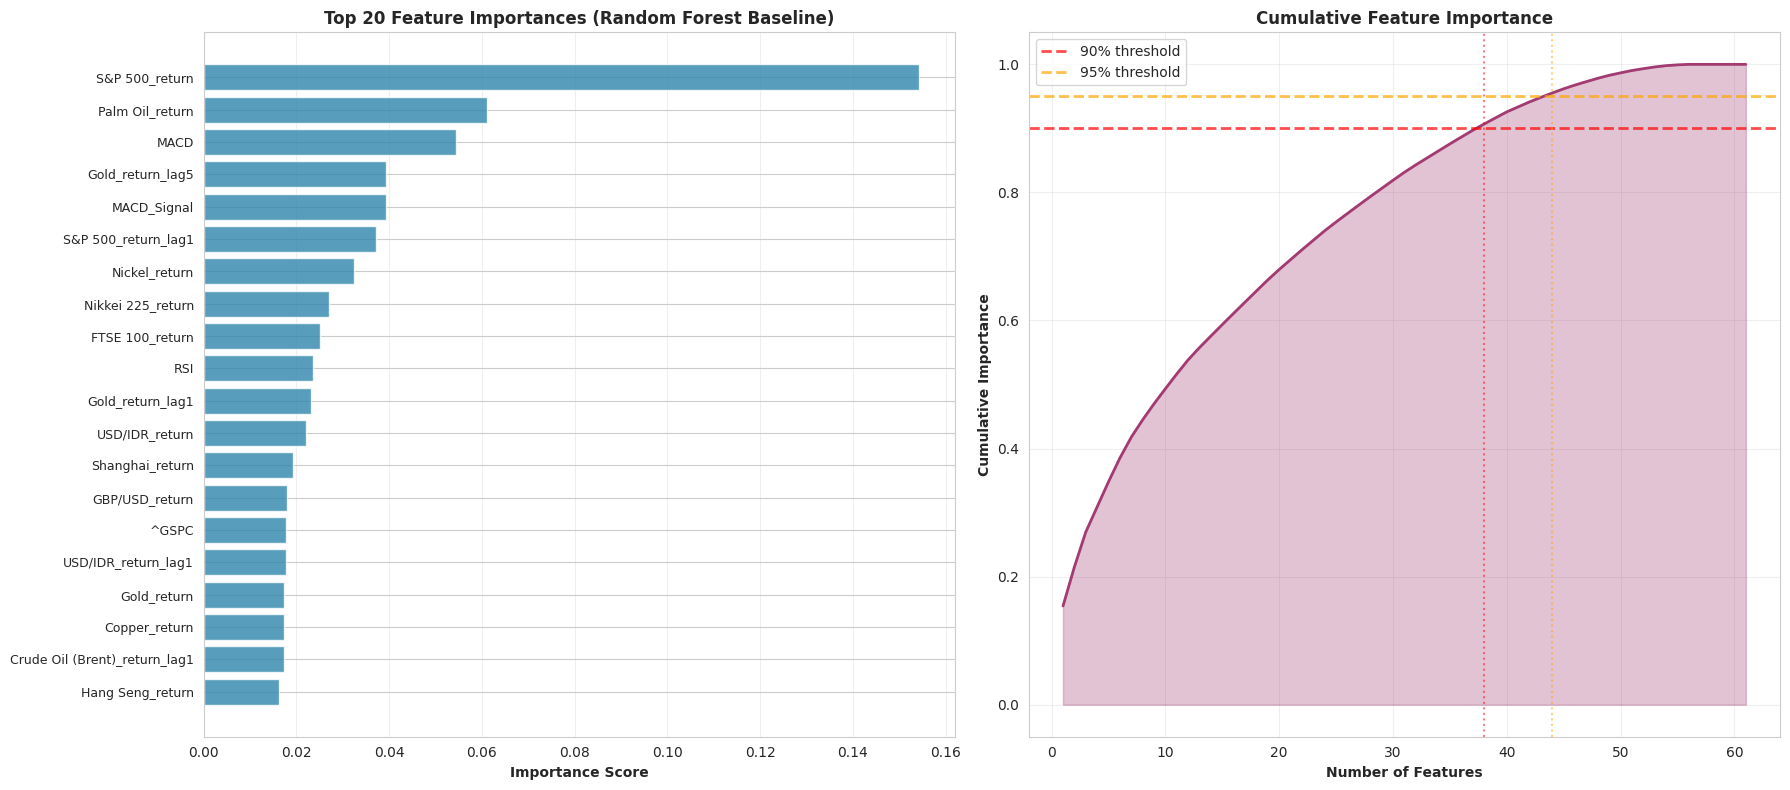

✓ Saved: eda/08_feature_importance_rf.png

[Feature Selection Insights]
  Features needed for 90% importance: 38 out of 61
  Features needed for 95% importance: 44 out of 61
  Efficiency: 62.3% of features explain 90% of variance

[3.5.3] Feature Type Analysis

[Feature Type Importance Summary]
                      Total_Importance  Avg_Importance  Count
Feature_Type                                                 
Global Markets                  0.3411          0.0284     12
Commodities                     0.2543          0.0231     11
Technical Indicators            0.1530          0.0170      9
Other                           0.1279          0.0107     12
Currencies                      0.0995          0.0100     10
Temporal                        0.0192          0.0038      5
Interest Rates                  0.0051          0.0025      2

[Feature Examples by Category]
  Global Markets:
    • S&P 500_return
    • S&P 500_return_lag1
    • Nikkei 225_return
  Commodities:
    • Palm

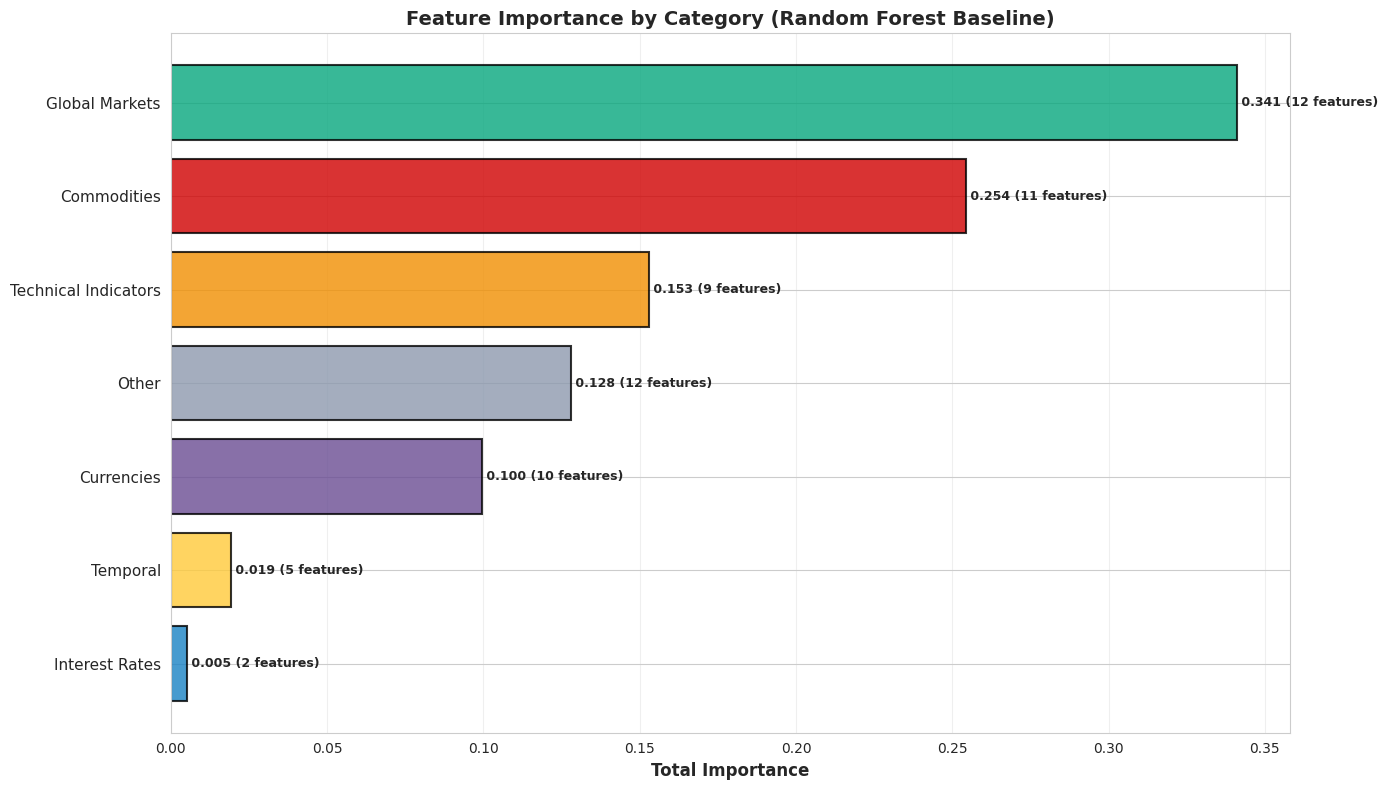

✓ Saved: eda/09_feature_importance_by_type.png

[Top 3 Features per Category]

Global Markets:
  • S&P 500_return: 0.1542
  • S&P 500_return_lag1: 0.0371
  • Nikkei 225_return: 0.0271

Commodities:
  • Palm Oil_return: 0.0610
  • Gold_return_lag5: 0.0393
  • Nickel_return: 0.0325

Technical Indicators:
  • MACD: 0.0545
  • MACD_Signal: 0.0393
  • RSI: 0.0236

Other:
  • ^GSPC: 0.0179
  • NG=F: 0.0130
  • HG=F: 0.0128

Currencies:
  • USD/IDR_return: 0.0220
  • GBP/USD_return: 0.0180
  • USD/IDR_return_lag1: 0.0177

Temporal:
  • DayOfWeek: 0.0059
  • WeekOfYear: 0.0053
  • DayOfMonth: 0.0052

Interest Rates:
  • Federal Funds Rate: 0.0038
  • BI Rate: 0.0013

[3.5.4] Comparing RF Importance with Correlation

[Top 10 Features: RF Importance vs Correlation]
            Feature  Importance  Abs_Correlation         Feature_Type
     S&P 500_return    0.154221         0.004597       Global Markets
    Palm Oil_return    0.061010         0.012765          Commodities
               MACD    0

In [19]:
# ===================================================================
# SECTION 3: TRAIN-TEST SPLIT & SCALING
# ===================================================================

print("\n" + "="*70)
print("SECTION 3: DATA PREPARATION")
print("="*70)

# Separate features and target
X = data[feature_cols].values
y = data['Target'].values

print(f"\n[3.1] Features: {len(feature_cols)}")
print(f"[3.2] Samples: {len(X)}")

# Convert to float32
X = X.astype(np.float32)
y = y.astype(np.float32)

# Time-based split
train_size = int(len(X) * config.TRAIN_SPLIT)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Store last actual IHSG price for reconstruction
last_actual_price_train = data['IHSG'].iloc[train_size - 1]

dates_train = data.index[:train_size]
dates_test = data.index[train_size:]

print(f"\n✓ Train size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"✓ Test size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"✓ Last actual price before test set: {last_actual_price_train:.2f}")

# Scaling
print("\n[3.3] Scaling data...")
scaler_X = MinMaxScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler_X.transform(X_test).astype(np.float32)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).astype(np.float32).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).astype(np.float32).flatten()

print("✓ Features scaled with MinMaxScaler, Target (returns) scaled with StandardScaler")

# Save splits
np.savez(f'{config.OUTPUT_DIR}/data/02_train_test_split.npz',
         X_train=X_train_scaled, X_test=X_test_scaled,
         y_train=y_train_scaled, y_test=y_test_scaled,
         feature_names=feature_cols,
         dates_train=dates_train, dates_test=dates_test)
print(f"\n✓ Saved: {config.OUTPUT_DIR}/data/02_train_test_split.npz")

# ===================================================================
# SECTION 3.5: BASELINE FEATURE IMPORTANCE ANALYSIS
# ===================================================================

print("\n" + "="*70)
print("SECTION 3.5: BASELINE FEATURE IMPORTANCE ANALYSIS")
print("="*70)

print("\nWHY THIS ANALYSIS:")
print("  1. Establishes baseline feature importance BEFORE deep learning models")
print("  2. Provides comparison point for TabNet's feature selection")
print("  3. Validates if traditional ML sees similar important features")
print("  4. Random Forest is interpretable and handles non-linearity well")

print("\n[3.5.1] Training Random Forest for Feature Importance")

from sklearn.ensemble import RandomForestRegressor

# Use a reasonable sample size for quick analysis
# For large datasets (>5000 samples), use subset to speed up computation
sample_size = min(3000, len(X_train_scaled))

print(f"  Using {sample_size} samples from training set for analysis...")

X_sample = X_train_scaled[:sample_size]
y_sample = y_train_scaled[:sample_size]  # Using scaled y for consistency

# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=config.SEED,
    n_jobs=-1,
    verbose=0
)

print("  Training Random Forest baseline model...")
rf_model.fit(X_sample, y_sample)
print("  ✓ Training complete")

# Extract feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n[Top 20 Most Important Features (Random Forest Baseline)]")
print(feature_importance.head(20).to_string(index=False))

# Statistical summary
print(f"\n[Feature Importance Statistics]")
print(f"  Mean importance: {feature_importance['Importance'].mean():.6f}")
print(f"  Std importance: {feature_importance['Importance'].std():.6f}")
print(f"  Max importance: {feature_importance['Importance'].max():.6f}")
print(f"  Top 10 features capture: {feature_importance.head(10)['Importance'].sum():.2%} of total importance")
print(f"  Top 20 features capture: {feature_importance.head(20)['Importance'].sum():.2%} of total importance")

# Interpretation
top_10_concentration = feature_importance.head(10)['Importance'].sum()
if top_10_concentration > 0.7:
    print(f"\n  Interpretation: HIGH CONCENTRATION - Few features dominate prediction")
elif top_10_concentration > 0.5:
    print(f"  Interpretation: MODERATE CONCENTRATION - Some features are more important")
else:
    print(f"  Interpretation: LOW CONCENTRATION - Importance is distributed across many features")

# ---------------------------------------------------------------
# 3.5.2 Visualize Feature Importance
# ---------------------------------------------------------------

print("\n[3.5.2] Visualizing Feature Importance")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Top 20 features (horizontal bar chart)
ax1 = axes[0]
top_20 = feature_importance.head(20)
y_pos = np.arange(len(top_20))
ax1.barh(y_pos, top_20['Importance'], color='#2E86AB', alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(top_20['Feature'], fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('Importance Score', fontweight='bold')
ax1.set_title('Top 20 Feature Importances (Random Forest Baseline)', 
              fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Cumulative importance
ax2 = axes[1]
cumulative_importance = np.cumsum(feature_importance['Importance'].values)
n_features = np.arange(1, len(cumulative_importance) + 1)
ax2.plot(n_features, cumulative_importance, linewidth=2, color='#A23B72')
ax2.axhline(y=0.9, color='red', linestyle='--', linewidth=2, 
            label='90% threshold', alpha=0.7)
ax2.axhline(y=0.95, color='orange', linestyle='--', linewidth=2, 
            label='95% threshold', alpha=0.7)
ax2.fill_between(n_features, 0, cumulative_importance, alpha=0.3, color='#A23B72')
ax2.set_xlabel('Number of Features', fontweight='bold')
ax2.set_ylabel('Cumulative Importance', fontweight='bold')
ax2.set_title('Cumulative Feature Importance', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Find how many features needed for 90% and 95%
features_for_90 = np.argmax(cumulative_importance >= 0.90) + 1
features_for_95 = np.argmax(cumulative_importance >= 0.95) + 1
ax2.axvline(x=features_for_90, color='red', linestyle=':', alpha=0.5)
ax2.axvline(x=features_for_95, color='orange', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/eda/08_feature_importance_rf.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: eda/08_feature_importance_rf.png")

print(f"\n[Feature Selection Insights]")
print(f"  Features needed for 90% importance: {features_for_90} out of {len(feature_cols)}")
print(f"  Features needed for 95% importance: {features_for_95} out of {len(feature_cols)}")
print(f"  Efficiency: {features_for_90/len(feature_cols)*100:.1f}% of features explain 90% of variance")

# ---------------------------------------------------------------
# 3.5.3 Feature Type Analysis - FIXED VERSION
# ---------------------------------------------------------------

print("\n[3.5.3] Feature Type Analysis")

def categorize_feature(feature_name):
    """Categorize features by type - FIXED with priority ordering"""
    feature_lower = feature_name.lower()
    
    # Priority-based categorization (specific → general)
    
    # 1. Technical Indicators (most specific)
    if any(ind in feature_name for ind in ['MACD', 'RSI', 'BB_', 'SMA', 'EMA']):
        return 'Technical Indicators'
    
    # 2. Global Markets (before checking "return")
    if any(market in feature_name for market in ['S&P 500', 'S&P', 'VIX', 'Hang Seng', 
                                                   'Nikkei', 'Shanghai', 'FTSE']):
        return 'Global Markets'
    
    # 3. Commodities (before checking "return")
    if any(commodity in feature_name for commodity in ['Gold', 'Oil', 'Brent', 'Coal', 
                                                         'Nickel', 'Copper', 'Palm',  'Natural Gas']):
        return 'Commodities'
    
    # 4. Currencies (before checking "return")
    if any(curr in feature_name for curr in ['IDR', 'USD', 'EUR', 'GBP', 'JPY']):
        return 'Currencies'
    
    # 5. Interest Rates
    if 'Rate' in feature_name or 'BI' in feature_name or 'Federal' in feature_name:
        return 'Interest Rates'
    
    # 6. Volume features
    if 'volume' in feature_lower:
        return 'Volume'
    
    # 7. Temporal features
    if feature_name in ['DayOfWeek', 'Month', 'Quarter', 'DayOfMonth', 'WeekOfYear']:
        return 'Temporal'
    
    # 8. Lagged features (check before generic "return")
    if 'lag' in feature_lower:
        return 'Lagged Features'
    
    # 9. Generic return features (ONLY if not caught above)
    if 'return' in feature_lower:
        return 'Other Returns'
    
    # 10. Everything else
    return 'Other'

# Categorize all features
feature_importance['Feature_Type'] = feature_importance['Feature'].apply(categorize_feature)

# Aggregate importance by type
type_importance = feature_importance.groupby('Feature_Type').agg({
    'Importance': ['sum', 'mean', 'count']
}).round(4)
type_importance.columns = ['Total_Importance', 'Avg_Importance', 'Count']
type_importance = type_importance.sort_values('Total_Importance', ascending=False)

print("\n[Feature Type Importance Summary]")
print(type_importance.to_string())

# Show examples of each category
print("\n[Feature Examples by Category]")
for category in type_importance.index:
    examples = feature_importance[feature_importance['Feature_Type'] == category]['Feature'].head(3).tolist()
    print(f"  {category}:")
    for ex in examples:
        print(f"    • {ex}")

# Visualize by type with better colors
plt.figure(figsize=(14, 8))

# Updated color mapping for all categories
colors_map = {
    'Technical Indicators': '#F18F01',      # Orange
    'Global Markets': '#06A77D',            # Teal
    'Commodities': '#D00000',               # Red
    'Currencies': '#6A4C93',                # Purple
    'Interest Rates': '#1982C4',            # Blue
    'Volume': '#8AC926',                    # Green
    'Temporal': '#FFCA3A',                  # Yellow
    'Lagged Features': '#A23B72',           # Magenta
    'Other Returns': '#2E86AB',             # Sky Blue
    'Other': '#8D99AE'                      # Gray
}

colors = [colors_map.get(cat, '#8D99AE') for cat in type_importance.index]

plt.barh(range(len(type_importance)), type_importance['Total_Importance'], 
         color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
plt.yticks(range(len(type_importance)), type_importance.index, fontsize=11)
plt.xlabel('Total Importance', fontweight='bold', fontsize=12)
plt.title('Feature Importance by Category (Random Forest Baseline)', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(type_importance.iterrows()):
    plt.text(row['Total_Importance'], i, 
             f" {row['Total_Importance']:.3f} ({int(row['Count'])} features)",
             va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/eda/09_feature_importance_by_type.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: eda/09_feature_importance_by_type.png")

# Additional: Show top features per category
print("\n[Top 3 Features per Category]")
for category in type_importance.index:
    category_features = feature_importance[feature_importance['Feature_Type'] == category].head(3)
    print(f"\n{category}:")
    for _, row in category_features.iterrows():
        print(f"  • {row['Feature']}: {row['Importance']:.4f}")

# ---------------------------------------------------------------
# 3.5.4 Compare with Correlation
# ---------------------------------------------------------------

print("\n[3.5.4] Comparing RF Importance with Correlation")

# Merge with correlation data (if IHSG correlation exists)
if 'IHSG' in data.columns:
    # Get correlations for features
    feature_correlations = []
    for feat in feature_importance['Feature']:
        if feat in data.columns:
            corr = data['IHSG'].corr(data[feat])
            feature_correlations.append(abs(corr))
        else:
            feature_correlations.append(np.nan)
    
    feature_importance['Abs_Correlation'] = feature_correlations
    
    # Compare top features
    print("\n[Top 10 Features: RF Importance vs Correlation]")
    comparison = feature_importance.head(10)[['Feature', 'Importance', 'Abs_Correlation', 'Feature_Type']]
    print(comparison.to_string(index=False))
    
    # Correlation between importance and correlation
    valid_data = feature_importance.dropna(subset=['Abs_Correlation'])
    if len(valid_data) > 0:
        importance_corr_correlation = valid_data['Importance'].corr(valid_data['Abs_Correlation'])
        print(f"\n  Correlation between RF importance and IHSG correlation: {importance_corr_correlation:.3f}")
        
        if importance_corr_correlation > 0.5:
            print("  ✓ STRONG AGREEMENT: RF importance aligns well with linear correlation")
        elif importance_corr_correlation > 0.3:
            print("  ~ MODERATE AGREEMENT: RF captures some non-linear patterns")
        else:
            print("  ✗ WEAK AGREEMENT: RF captures different (possibly non-linear) relationships")

# Save comprehensive results
feature_importance.to_csv(f'{config.OUTPUT_DIR}/eda/10_feature_importance_rf_detailed.csv', 
                         index=False)
type_importance.to_csv(f'{config.OUTPUT_DIR}/eda/11_feature_importance_by_type.csv')

print("\n✓ Baseline feature importance analysis complete")

print("\n" + "="*70)
print("WHY THIS MATTERS FOR YOUR RESEARCH:")
print("="*70)
print("\n1. THESIS (TabNet Interpretability):")
print("   • Compare TabNet's attention masks with RF importance")
print("   • If they agree → validates TabNet's feature selection")
print("   • If they differ → TabNet may capture more complex patterns")
print("   • Shows TabNet interpretability vs traditional ML")

print("\n2. PAPER (Hybrid Architecture):")
print("   • Establishes baseline feature relevance")
print("   • Shows which feature types matter most")
print("   • Provides context for why deep learning helps")
print("   • Traditional ML limitation → motivates hybrid approach")

print("\n3. BOTH:")
print("   • Demonstrates feature redundancy/concentration")
print("   • Informs feature engineering decisions")
print("   • Validates data quality and feature relevance")
print("   • Scientific rigor: multiple perspectives on importance")

print("\n" + "="*70)

In [20]:
# ===================================================================
# SECTION 4: SEQUENCE CREATION FOR MULTI-HORIZON FORECASTING
# ===================================================================

def create_sequences_multihorizon(X, y, timesteps, horizon=1):
    """Create sequences for multi-horizon forecasting"""
    X_seq, y_seq = [], []
    
    for i in range(timesteps, len(X) - horizon + 1):
        X_seq.append(X[i-timesteps:i])
        if horizon == 1:
            y_seq.append(y[i])
        else:
            y_seq.append(y[i:i+horizon])
    
    X_seq = np.array(X_seq, dtype=np.float32)
    y_seq = np.array(y_seq, dtype=np.float32)
    
    return X_seq, y_seq


class TimeSeriesDataset(Dataset):
    """PyTorch Dataset for time series"""
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).to(config.DTYPE)
        self.y = torch.from_numpy(y).to(config.DTYPE)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ===================================================================
# SECTION 5: OPTIMAL TIMESTEP SELECTION
# ===================================================================

print("\n" + "="*70)
print("SECTION 5: OPTIMAL TIMESTEP SELECTION")
print("="*70)

class SimpleLSTM(nn.Module):
    """Simple LSTM for timestep testing"""
    def __init__(self, input_size, hidden_size=64, num_layers=2, output_size=1):
        super(SimpleLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out


def train_simple_lstm(X_train, y_train, X_val, y_val, input_size, epochs=50):
    """Quick training for timestep selection"""
    model = SimpleLSTM(input_size).to(config.DEVICE)
    criterion = nn.MSELoss()
    optimizer = Adam(model.parameters(), lr=0.001)
    
    train_dataset = TimeSeriesDataset(X_train, y_train.reshape(-1, 1))
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
    
    model.train()
    for epoch in range(epochs):
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(config.DEVICE)
            batch_y = batch_y.to(config.DEVICE)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
    
    # Validation
    model.eval()
    with torch.no_grad():
        X_val_tensor = torch.from_numpy(X_val).to(config.DTYPE).to(config.DEVICE)
        y_val_tensor = torch.from_numpy(y_val).to(config.DTYPE).to(config.DEVICE)
        predictions = model(X_val_tensor)
        val_loss = criterion(predictions, y_val_tensor.reshape(-1, 1)).item()
    
    return val_loss


print("\n[5.1] Testing timestep candidates:", config.TIMESTEP_CANDIDATES)
print("Using simple LSTM with 3-fold TimeSeriesSplit validation...\n")

timestep_results = []
tscv = TimeSeriesSplit(n_splits=config.N_SPLITS)

for timesteps in config.TIMESTEP_CANDIDATES:
    print(f"\n--- Testing timesteps={timesteps} ---")
    
    X_seq, y_seq = create_sequences_multihorizon(X_train_scaled, y_train_scaled, 
                                                   timesteps, horizon=1)
    
    fold_scores = []
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_seq)):
        X_fold_train = X_seq[train_idx]
        y_fold_train = y_seq[train_idx]
        X_fold_val = X_seq[val_idx]
        y_fold_val = y_seq[val_idx]
        
        val_loss = train_simple_lstm(X_fold_train, y_fold_train, 
                                      X_fold_val, y_fold_val,
                                      input_size=X_train_scaled.shape[1],
                                      epochs=50)
        fold_scores.append(val_loss)
        print(f"  Fold {fold+1}: Val Loss = {val_loss:.6f}")
    
    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    
    timestep_results.append({
        'Timesteps': timesteps,
        'Mean_Val_Loss': mean_score,
        'Std_Val_Loss': std_score,
        'Available_Sequences': len(X_seq)
    })
    
    print(f"  Average: {mean_score:.6f} ± {std_score:.6f}")

# Select best timestep
timestep_df = pd.DataFrame(timestep_results)
best_timestep = timestep_df.loc[timestep_df['Mean_Val_Loss'].idxmin(), 'Timesteps']

print("\n" + "="*70)
print("TIMESTEP SELECTION RESULTS")
print("="*70)
print(timestep_df.to_string(index=False))
print(f"\n✓ Selected optimal timesteps: {int(best_timestep)}")
print("="*70)

timestep_df.to_csv(f'{config.OUTPUT_DIR}/data/03_timestep_selection.csv', index=False)

# Use best timestep
TIMESTEPS = int(best_timestep)

# ===================================================================
# SECTION 6: CREATE SEQUENCES FOR ALL HORIZONS
# ===================================================================

print("\n" + "="*70)
print("SECTION 6: SEQUENCE GENERATION")
print("="*70)

sequences = {}

for horizon_name, horizon_steps in config.HORIZONS.items():
    print(f"\n[6.{list(config.HORIZONS.keys()).index(horizon_name)+1}] Creating {horizon_name} sequences...")
    
    X_train_seq, y_train_seq = create_sequences_multihorizon(
        X_train_scaled, y_train_scaled, TIMESTEPS, horizon_steps
    )
    X_test_seq, y_test_seq = create_sequences_multihorizon(
        X_test_scaled, y_test_scaled, TIMESTEPS, horizon_steps
    )
    
    sequences[horizon_name] = {
        'X_train': X_train_seq,
        'y_train': y_train_seq,
        'X_test': X_test_seq,
        'y_test': y_test_seq
    }
    
    print(f"  Train: X={X_train_seq.shape}, y={y_train_seq.shape}")
    print(f"  Test:  X={X_test_seq.shape}, y={y_test_seq.shape}")

print("\n✓ All sequences created successfully")


SECTION 5: OPTIMAL TIMESTEP SELECTION

[5.1] Testing timestep candidates: [30, 60, 90]
Using simple LSTM with 3-fold TimeSeriesSplit validation...


--- Testing timesteps=30 ---
  Fold 1: Val Loss = 1.074199
  Fold 2: Val Loss = 0.664687
  Fold 3: Val Loss = 1.274327
  Average: 1.004404 ± 0.253730

--- Testing timesteps=60 ---
  Fold 1: Val Loss = 1.123109
  Fold 2: Val Loss = 1.607820
  Fold 3: Val Loss = 1.259111
  Average: 1.330013 ± 0.204135

--- Testing timesteps=90 ---
  Fold 1: Val Loss = 1.086152
  Fold 2: Val Loss = 0.596995
  Fold 3: Val Loss = 1.351327
  Average: 1.011491 ± 0.312447

TIMESTEP SELECTION RESULTS
 Timesteps  Mean_Val_Loss  Std_Val_Loss  Available_Sequences
        30       1.004404      0.253730                 3246
        60       1.330013      0.204135                 3216
        90       1.011491      0.312447                 3186

✓ Selected optimal timesteps: 30

SECTION 6: SEQUENCE GENERATION

[6.1] Creating 1-day sequences...
  Train: X=(3246, 30, 61)

In [21]:
# ===================================================================
# SECTION 7: MODEL DEFINITIONS
# ===================================================================

print("\n" + "="*70)
print("SECTION 7: MODEL ARCHITECTURES")
print("="*70)

# ---------------------------------------------------------------------
# 7.1 TCN Architecture
# ---------------------------------------------------------------------

class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size
    
    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()


class TCNResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super(TCNResidualBlock, self).__init__()
        
        padding = (kernel_size - 1) * dilation
        
        self.norm1 = nn.LayerNorm(in_channels)
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        
        self.norm2 = nn.LayerNorm(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x_normed = self.norm1(x.permute(0, 2, 1)).permute(0, 2, 1)
        out = self.conv1(x_normed)
        out = self.chomp1(out)
        out = self.relu1(out)
        out = self.dropout1(out)
        
        out_normed = self.norm2(out.permute(0, 2, 1)).permute(0, 2, 1)
        out = self.conv2(out_normed)
        out = self.chomp2(out)
        out = self.relu2(out)
        out = self.dropout2(out)
        
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TCN(nn.Module):
    def __init__(self, input_size, num_channels, kernel_size=3, dropout=0.2):
        super(TCN, self).__init__()
        
        layers = []
        num_levels = len(num_channels)
        
        for i in range(num_levels):
            dilation = 2 ** i
            in_channels = input_size if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            
            layers.append(TCNResidualBlock(in_channels, out_channels, kernel_size, 
                                          dilation, dropout))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)


class TCNModel(nn.Module):
    def __init__(self, input_size, output_size, num_channels, kernel_size=3, dropout=0.2):
        super(TCNModel, self).__init__()
        self.tcn = TCN(input_size, num_channels, kernel_size, dropout)
        self.linear = nn.Linear(num_channels[-1], output_size)
    
    def forward(self, x):
        x = x.transpose(1, 2)
        tcn_out = self.tcn(x)
        out = tcn_out[:, :, -1]
        return self.linear(out)

# ---------------------------------------------------------------------
# 7.2 LSTM Model
# ---------------------------------------------------------------------

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = lstm_out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)

# ---------------------------------------------------------------------
# 7.3 TabNet-LSTM Hybrid
# ---------------------------------------------------------------------

class TabNetLSTM(nn.Module):
    def __init__(self, input_size, tabnet_params, lstm_hidden, lstm_layers, 
                 output_size, dropout=0.2):
        super(TabNetLSTM, self).__init__()
        
        self.tabnet_params = tabnet_params
        self.input_size = input_size
        
        tabnet_output_size = tabnet_params['n_d'] + tabnet_params['n_a']
        
        self.initial_bn = nn.BatchNorm1d(input_size)
        
        self.feat_transformer = nn.Sequential(
            nn.Linear(input_size, tabnet_output_size),
            nn.BatchNorm1d(tabnet_output_size),
            nn.ReLU()
        )
        
        self.lstm = nn.LSTM(tabnet_output_size, lstm_hidden, lstm_layers,
                           batch_first=True, dropout=dropout if lstm_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_hidden, output_size)
    
    def forward(self, x):
        batch_size, seq_len, n_features = x.shape
        
        x_reshaped = x.reshape(-1, n_features)
        x_normed = self.initial_bn(x_reshaped)
        features = self.feat_transformer(x_normed)
        
        features = features.reshape(batch_size, seq_len, -1)
        
        lstm_out, _ = self.lstm(features)
        out = lstm_out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)

# ---------------------------------------------------------------------
# 7.4 TabNet-TCN Hybrid
# ---------------------------------------------------------------------

class TabNetTCN(nn.Module):
    def __init__(self, input_size, tabnet_params, tcn_channels, 
                 tcn_kernel_size, output_size, dropout=0.2):
        super(TabNetTCN, self).__init__()
        
        self.input_size = input_size
        self.tabnet_params = tabnet_params
        
        tabnet_output_size = tabnet_params['n_d'] + tabnet_params['n_a']
        
        self.initial_bn = nn.BatchNorm1d(input_size)
        
        self.feat_transformer = nn.Sequential(
            nn.Linear(input_size, tabnet_output_size),
            nn.BatchNorm1d(tabnet_output_size),
            nn.ReLU()
        )
        
        self.mask_generator = nn.Sequential(
            nn.Linear(tabnet_output_size, input_size),
            nn.Sigmoid()
        )
        
        self.tcn = TCN(input_size, tcn_channels, tcn_kernel_size, dropout)
        
        self.fc = nn.Linear(tcn_channels[-1], output_size)
        
        self.last_mask = None
    
    def forward(self, x):
        batch_size, seq_len, n_features = x.shape
        
        x_last = x[:, -1, :]
        x_normed = self.initial_bn(x_last)
        features = self.feat_transformer(x_normed)
        mask = self.mask_generator(features)
        
        self.last_mask = mask.detach()
        
        mask_expanded = mask.unsqueeze(1).expand(-1, seq_len, -1)
        x_masked = x * mask_expanded
        
        x_tcn = x_masked.transpose(1, 2)
        tcn_out = self.tcn(x_tcn)
        
        out = tcn_out[:, :, -1]
        return self.fc(out)
    
    def get_mask(self):
        return self.last_mask


SECTION 7: MODEL ARCHITECTURES


In [22]:
# ===================================================================
# SECTION 8: TRAINING & EVALUATION UTILITIES
# ===================================================================

def train_model(model, train_loader, val_loader, criterion, optimizer, 
                epochs, patience, device, model_name="Model"):
    """Generic training function"""
    
    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            
            if len(batch_y.shape) == 1:
                batch_y = batch_y.unsqueeze(-1)
            if outputs.shape != batch_y.shape:
                outputs = outputs.reshape(batch_y.shape)
            
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
        
        avg_train_loss = np.mean(train_losses)
        
        model.eval()
        val_losses = []
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)
                
                outputs = model(batch_X)
                
                if len(batch_y.shape) == 1:
                    batch_y = batch_y.unsqueeze(-1)
                if outputs.shape != batch_y.shape:
                    outputs = outputs.reshape(batch_y.shape)
                
                loss = criterion(outputs, batch_y)
                val_losses.append(loss.item())
        
        avg_val_loss = np.mean(val_losses)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{epochs}: Train={avg_train_loss:.6f}, Val={avg_val_loss:.6f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break
    
    model.load_state_dict(best_model_state)
    
    return model, history, best_val_loss


def evaluate_model(model, X_test, y_test, scaler_y, device, last_actual_price):
    """
    Evaluate model with correct price reconstruction for multi-horizon forecasts
    """
    model.eval()
    
    with torch.no_grad():
        X_test_tensor = torch.from_numpy(X_test).to(config.DTYPE).to(device)
        predictions_scaled = model(X_test_tensor).cpu().numpy()

    if len(predictions_scaled.shape) == 1:
        predictions_scaled = predictions_scaled.reshape(-1, 1)
    
    predicted_returns = scaler_y.inverse_transform(predictions_scaled)
    
    y_test_to_transform = y_test
    if len(y_test.shape) == 1:
        y_test_to_transform = y_test.reshape(-1, 1)
    actual_returns = scaler_y.inverse_transform(y_test_to_transform)

    num_samples, horizon = actual_returns.shape

    # Build base actual price path
    base_actual_prices = [last_actual_price]
    for ret in actual_returns[:, 0]:
        next_price = base_actual_prices[-1] * (1 + ret)
        base_actual_prices.append(next_price)
    
    predicted_prices = np.zeros_like(predicted_returns)
    actual_prices = np.zeros_like(actual_returns)

    # Reconstruct prices for each sample
    for i in range(num_samples):
        start_price = base_actual_prices[i]
        
        cumulative_pred_returns = np.cumprod(1 + predicted_returns[i, :])
        cumulative_actual_returns = np.cumprod(1 + actual_returns[i, :])
        
        predicted_prices[i, :] = start_price * cumulative_pred_returns
        actual_prices[i, :] = start_price * cumulative_actual_returns

    if horizon == 1:
        predicted_prices = predicted_prices.flatten()
        actual_prices = actual_prices.flatten()
        
    return predicted_prices, actual_prices


def calculate_metrics(y_true, y_pred, horizon_name=""):
    """Calculate comprehensive metrics"""
    
    if len(y_true.shape) > 1 and y_true.shape[1] > 1:
        metrics = {}
        for step in range(y_true.shape[1]):
            step_metrics = calculate_metrics(y_true[:, step], y_pred[:, step], 
                                            f"{horizon_name}_step{step+1}")
            metrics.update(step_metrics)
        
        avg_rmse = np.mean([metrics[f'{horizon_name}_step{i+1}_RMSE'] 
                           for i in range(y_true.shape[1])])
        avg_mae = np.mean([metrics[f'{horizon_name}_step{i+1}_MAE'] 
                          for i in range(y_true.shape[1])])
        avg_smape = np.mean([metrics[f'{horizon_name}_step{i+1}_sMAPE'] 
                            for i in range(y_true.shape[1])])
        
        metrics[f'{horizon_name}_avg_RMSE'] = avg_rmse
        metrics[f'{horizon_name}_avg_MAE'] = avg_mae
        metrics[f'{horizon_name}_avg_sMAPE'] = avg_smape
        
        return metrics
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))
    
    if len(y_true) > 1:
        true_direction = np.diff(y_true) > 0
        pred_direction = np.diff(y_pred) > 0
        directional_accuracy = np.mean(true_direction == pred_direction) * 100
    else:
        directional_accuracy = 0.0
    
    prefix = f"{horizon_name}_" if horizon_name else ""
    
    return {
        f'{prefix}RMSE': rmse,
        f'{prefix}MAE': mae,
        f'{prefix}R2': r2,
        f'{prefix}sMAPE': smape,
        f'{prefix}Directional_Accuracy': directional_accuracy
    }


def calculate_economic_metrics(y_true, y_pred, transaction_cost=0.001, risk_free_rate=0.06):
    """Calculate economic significance metrics"""
    
    pred_returns = np.diff(y_pred) / y_pred[:-1]
    actual_returns = np.diff(y_true) / y_true[:-1]
    
    positions = (pred_returns > 0).astype(float)
    
    position_changes = np.abs(np.diff(np.concatenate([[0], positions])))
    costs = position_changes * transaction_cost
    
    strategy_returns = positions * actual_returns - costs
    
    cumulative_return = np.prod(1 + strategy_returns) - 1
    
    if len(strategy_returns) > 0 and np.std(strategy_returns) > 0:
        sharpe_ratio = (np.mean(strategy_returns) - risk_free_rate/252) / np.std(strategy_returns) * np.sqrt(252)
    else:
        sharpe_ratio = 0.0
    
    winning_trades = np.sum(strategy_returns > 0)
    total_trades = np.sum(position_changes > 0)
    win_rate = (winning_trades / total_trades * 100) if total_trades > 0 else 0.0
    
    cumulative = np.cumprod(1 + strategy_returns)
    running_max = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = np.min(drawdown) * 100
    
    return {
        'Cumulative_Return_%': cumulative_return * 100,
        'Sharpe_Ratio': sharpe_ratio,
        'Win_Rate_%': win_rate,
        'Max_Drawdown_%': max_drawdown,
        'Total_Trades': int(total_trades)
    }


# ===================================================================
# NEW VISUALIZATION FUNCTIONS
# ===================================================================

def plot_train_test_full(y_train_actual, y_train_pred, y_test_actual, y_test_pred, 
                          dates_train, dates_test, model_name, horizon_name, save_path=None):
    """
    Plot full train + test predictions without any cuts
    """
    # Handle multi-horizon: plot first step
    if len(y_train_actual.shape) > 1:
        y_train_actual = y_train_actual[:, 0]
        y_train_pred = y_train_pred[:, 0]
    if len(y_test_actual.shape) > 1:
        y_test_actual = y_test_actual[:, 0]
        y_test_pred = y_test_pred[:, 0]
    
    plt.figure(figsize=(24, 8))
    
    # Plot train
    plt.plot(dates_train, y_train_actual, label='Actual (Train)', color='black', 
             linewidth=1.5, alpha=0.7)
    plt.plot(dates_train, y_train_pred, label='Predicted (Train)', color='blue', 
             linewidth=1.2, alpha=0.6, linestyle='--')
    
    # Plot test
    plt.plot(dates_test, y_test_actual, label='Actual (Test)', color='darkgreen', 
             linewidth=2, alpha=0.8)
    plt.plot(dates_test, y_test_pred, label='Predicted (Test)', color='red', 
             linewidth=1.8, alpha=0.7, linestyle='--')
    
    # Add vertical line to separate train/test
    plt.axvline(x=dates_test[0], color='purple', linestyle=':', linewidth=2, 
                label='Train/Test Split', alpha=0.7)
    
    plt.title(f'Full Train+Test Predictions: {model_name} ({horizon_name})', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('IHSG Closing Price')
    plt.legend(fontsize=11, loc='best')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"✓ Full train+test plot saved to: {save_path}")
    
    plt.show()


def plot_all_horizons_for_model(model_name, all_predictions, save_path=None):
    """
    Plot predictions for all horizons for a single model.
    This now creates two plots: one for the full range and a zoomed-in view of the last 30 days.
    """
    # DIUBAH: Membuat figur dengan 2 subplot (2 baris, 1 kolom)
    # Ukuran figur (figsize) disesuaikan agar kedua plot muat dengan baik
    fig, axes = plt.subplots(2, 1, figsize=(22, 16))
    fig.suptitle(f'Multi-Horizon Comparison for {model_name}', fontsize=18, fontweight='bold')
    
    # Beri nama pada setiap sumbu (axis) agar lebih mudah dibaca
    ax_full = axes[0]
    ax_zoom = axes[1]

    # --- Pengaturan Plot 1: Rentang Penuh ---
    ax_full.set_title('Full Test Set Comparison')
    
    # --- Pengaturan Plot 2: Zoom 30 Hari Terakhir ---
    ax_zoom.set_title('Last 30 Days Comparison')

    # Ambil data aktual sebagai referensi utama dari horizon pertama
    actuals_key = f"{model_name}_{list(config.HORIZONS.keys())[0]}"
    if actuals_key not in all_predictions:
        print(f"Warning: No predictions found for model {model_name}. Skipping plot.")
        return
        
    actual_data = all_predictions[actuals_key]['actuals']
    if len(actual_data.shape) > 1:
        actual_data = actual_data[:, 0]
    
    actual_dates = all_predictions[actuals_key]['dates']
    
    # Plot data aktual di kedua subplot
    ax_full.plot(actual_dates, actual_data, label='Actual (Test Set)', color='black', linewidth=2.5)
    ax_zoom.plot(actual_dates[-30:], actual_data[-30:], label='Actual', color='black', linewidth=2, marker='o', markersize=5)


    colors = ['red', 'green', 'purple']
    for i, (horizon_name, _) in enumerate(config.HORIZONS.items()):
        pred_key = f"{model_name}_{horizon_name}"
        if pred_key in all_predictions:
            pred_data = all_predictions[pred_key]['predictions']
            pred_dates = all_predictions[pred_key]['dates']

            if len(pred_data.shape) > 1:
                pred_data = pred_data[:, 0]
            
            # Plot prediksi di subplot rentang penuh
            ax_full.plot(pred_dates, pred_data, label=f'Prediction ({horizon_name})', 
                         color=colors[i % len(colors)], linestyle='--', alpha=0.9)
            
            # Plot prediksi di subplot zoom 30 hari (dengan slicing [-30:])
            ax_zoom.plot(pred_dates[-30:], pred_data[-30:], label=f'Prediction ({horizon_name})', 
                         color=colors[i % len(colors)], linestyle='--', marker='s', markersize=4, alpha=0.9)

    # Lakukan formatting untuk kedua subplot sekaligus
    for ax in axes:
        ax.set_xlabel('Date')
        ax.set_ylabel('IHSG Closing Price')
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.5)
        # Rotasi label tanggal agar tidak tumpang tindih
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')

    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Menyesuaikan layout agar judul utama tidak tumpang tindih

    if save_path:
        # Sedikit modifikasi pada nama file untuk menandakan ini adalah plot gabungan
        combo_save_path = save_path.replace('.png', '_comparison_combo.png')
        plt.savefig(combo_save_path, dpi=600, bbox_inches='tight')
        print(f"✓ Multi-horizon comparison plot saved to: {combo_save_path}")
    
    plt.show()


def plot_last_n_days(y_true, y_pred, dates, model_name, horizon_name, n_days=30, save_path=None):
    """
    Plot last N days of test set with markers on each prediction point
    """
    plt.figure(figsize=(18, 8))
    
    y_true_last_n = y_true[-n_days:]
    y_pred_last_n = y_pred[-n_days:]
    dates_last_n = dates[-n_days:]
    
    if len(y_true_last_n.shape) > 1:
        y_true_last_n = y_true_last_n[:, 0]
    if len(y_pred_last_n.shape) > 1:
        y_pred_last_n = y_pred_last_n[:, 0]

    plt.plot(dates_last_n, y_true_last_n, label='Actual', color='black', 
             linewidth=2, marker='o', markersize=6, markerfacecolor='white', 
             markeredgewidth=2, markeredgecolor='black')
    plt.plot(dates_last_n, y_pred_last_n, label='Predicted', color='red', 
             linewidth=2, linestyle='--', marker='s', markersize=5, 
             markerfacecolor='red', alpha=0.7)
    
    plt.title(f'Last {n_days} Days Prediction: {model_name} ({horizon_name})', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('IHSG Closing Price')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"✓ Last {n_days} days plot saved to: {save_path}")

    plt.show()


def plot_test_only(y_true, y_pred, dates, model_name, horizon_name, save_path=None):
    """
    Plot only test set predictions
    """
    plt.figure(figsize=(20, 8))
    
    if len(y_true.shape) > 1:
        y_true = y_true[:, 0]
    if len(y_pred.shape) > 1:
        y_pred = y_pred[:, 0]
    
    plt.plot(dates, y_true, label='Actual', color='black', linewidth=2.5, alpha=0.8)
    plt.plot(dates, y_pred, label='Predicted', color='red', linewidth=2, 
             linestyle='--', alpha=0.7)
    
    plt.title(f'Test Set Predictions: {model_name} ({horizon_name})', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('IHSG Closing Price')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"✓ Test-only plot saved to: {save_path}")
    
    plt.show()


# ===================================================================
# STORAGE FOR ALL RESULTS
# ===================================================================

all_results = []
all_predictions = {}
trained_models = {}

print("\n" + "="*70)
print("STARTING MODEL TRAINING - MODULAR APPROACH")
print("="*70)


STARTING MODEL TRAINING - MODULAR APPROACH


[I 2025-10-12 07:19:01,916] A new study created in memory with name: no-name-fc745679-31c3-4600-8f51-e65b5d5adfff



SECTION 9: LSTM MODEL

[9.1] LSTM Configuration:
  Tuning enabled: True
  Max epochs: 200
  Patience: 20
  Optuna trials: 20

[9.2] LSTM Architecture Overview:
  - Input: Sequential data [batch, timesteps, features]
  - LSTM layers: 1-3 layers with hidden size 32-128
  - Dropout: 0.1-0.3 for regularization
  - Output: Fully connected layer for prediction
  - Input size: 61 features
  - Timesteps: 30

----------------------------------------------------------------------
9.3.1 LSTM - 1-day
----------------------------------------------------------------------

[Hyperparameter Tuning with Optuna]


  0%|          | 0/20 [00:00<?, ?it/s]

  Epoch 10/50: Train=1.158208, Val=1.043919
  Epoch 20/50: Train=1.033597, Val=1.062305
  Early stopping at epoch 21
  Epoch 10/50: Train=1.096959, Val=0.546495
  Epoch 20/50: Train=1.062373, Val=0.555822
  Early stopping at epoch 20
  Epoch 10/50: Train=0.923809, Val=1.153705


Best trial: 0. Best value: 0.906583:   5%|▌         | 1/20 [00:52<16:38, 52.57s/it]

...

Best trial: 10. Best value: 0.879113:  95%|█████████▌| 19/20 [06:28<00:11, 11.99s/it]

  Early stopping at epoch 12
[I 2025-10-12 07:25:30,407] Trial 18 finished with value: 0.8845681115275337 and parameters: {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.2497236449464147, 'lr': 0.00027402942686556716, 'batch_size': 128}. Best is trial 10 with value: 0.8791126956542333.
  Epoch 10/50: Train=1.206105, Val=1.023601
  Epoch 20/50: Train=1.147535, Val=1.018037
  Epoch 30/50: Train=0.965675, Val=1.037121
  Early stopping at epoch 32
  Epoch 10/50: Train=1.117795, Val=0.555086
  Early stopping at epoch 12
  Epoch 10/50: Train=0.931409, Val=1.153744
  Epoch 20/50: Train=0.890587, Val=1.151192


Best trial: 10. Best value: 0.879113: 100%|██████████| 20/20 [07:38<00:00, 22.92s/it]

  Early stopping at epoch 25
[I 2025-10-12 07:26:40,350] Trial 19 finished with value: 0.9027656908027636 and parameters: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2801297434942376, 'lr': 0.0018399419525198016, 'batch_size': 32}. Best is trial 10 with value: 0.8791126956542333.

✓ Best LSTM params: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.22212900585647988, 'lr': 0.0015495561054683989, 'batch_size': 128}

[Training Final LSTM Model]


  Epoch 10/200: Train=1.051144, Val=0.695878
  Epoch 20/200: Train=1.015166, Val=0.716859
  Early stopping at epoch 23

[Evaluation]

Metrics:
  1-day_RMSE: 61.5921
  1-day_MAE: 44.1040
  1-day_R2: 0.9736
  1-day_sMAPE: 0.6138
  1-day_Directional_Accuracy: 49.4297
  Cumulative_Return_%: -16.2932
  Sharpe_Ratio: -1.3221
  Win_Rate_%: 47.1178
  Max_Drawdown_%: -34.5285
  Total_Trades: 399.0000

[Visualization]
✓ Full train+test plot saved to: exports/visualizations/lstm_1-day_full.png


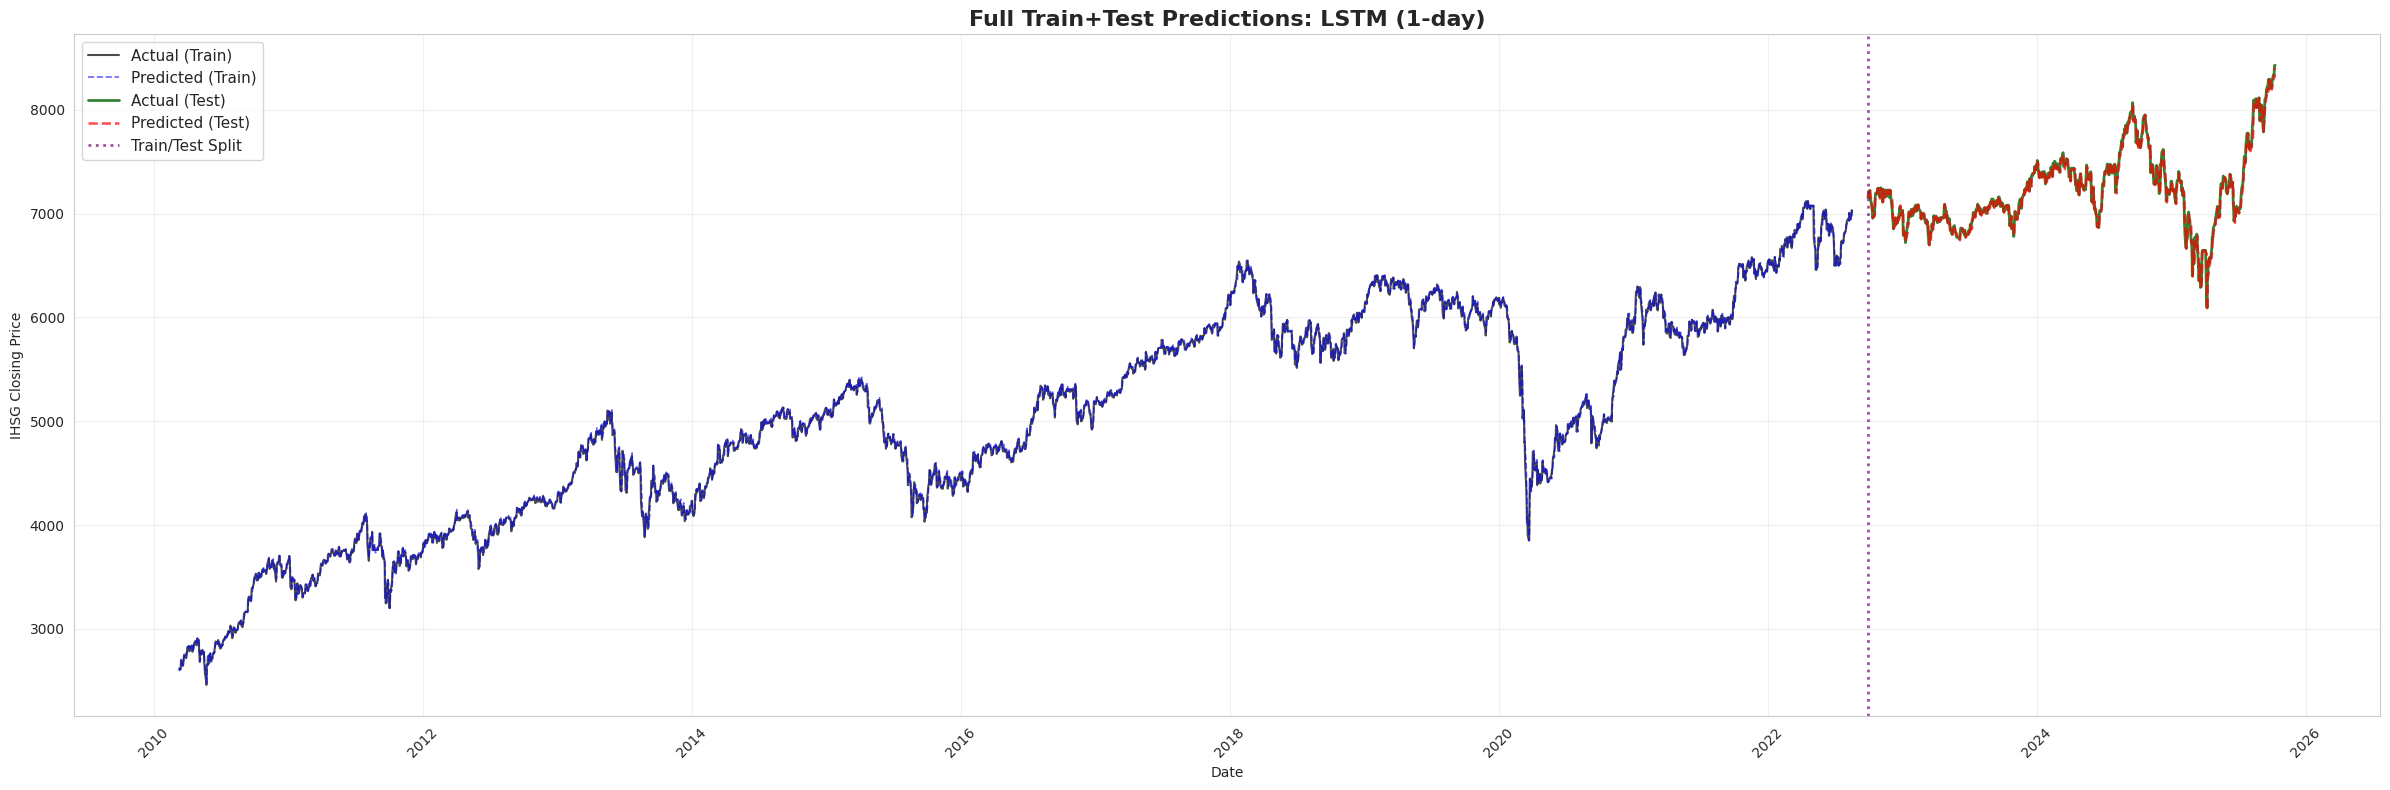

✓ Test-only plot saved to: exports/visualizations/lstm_1-day_test.png


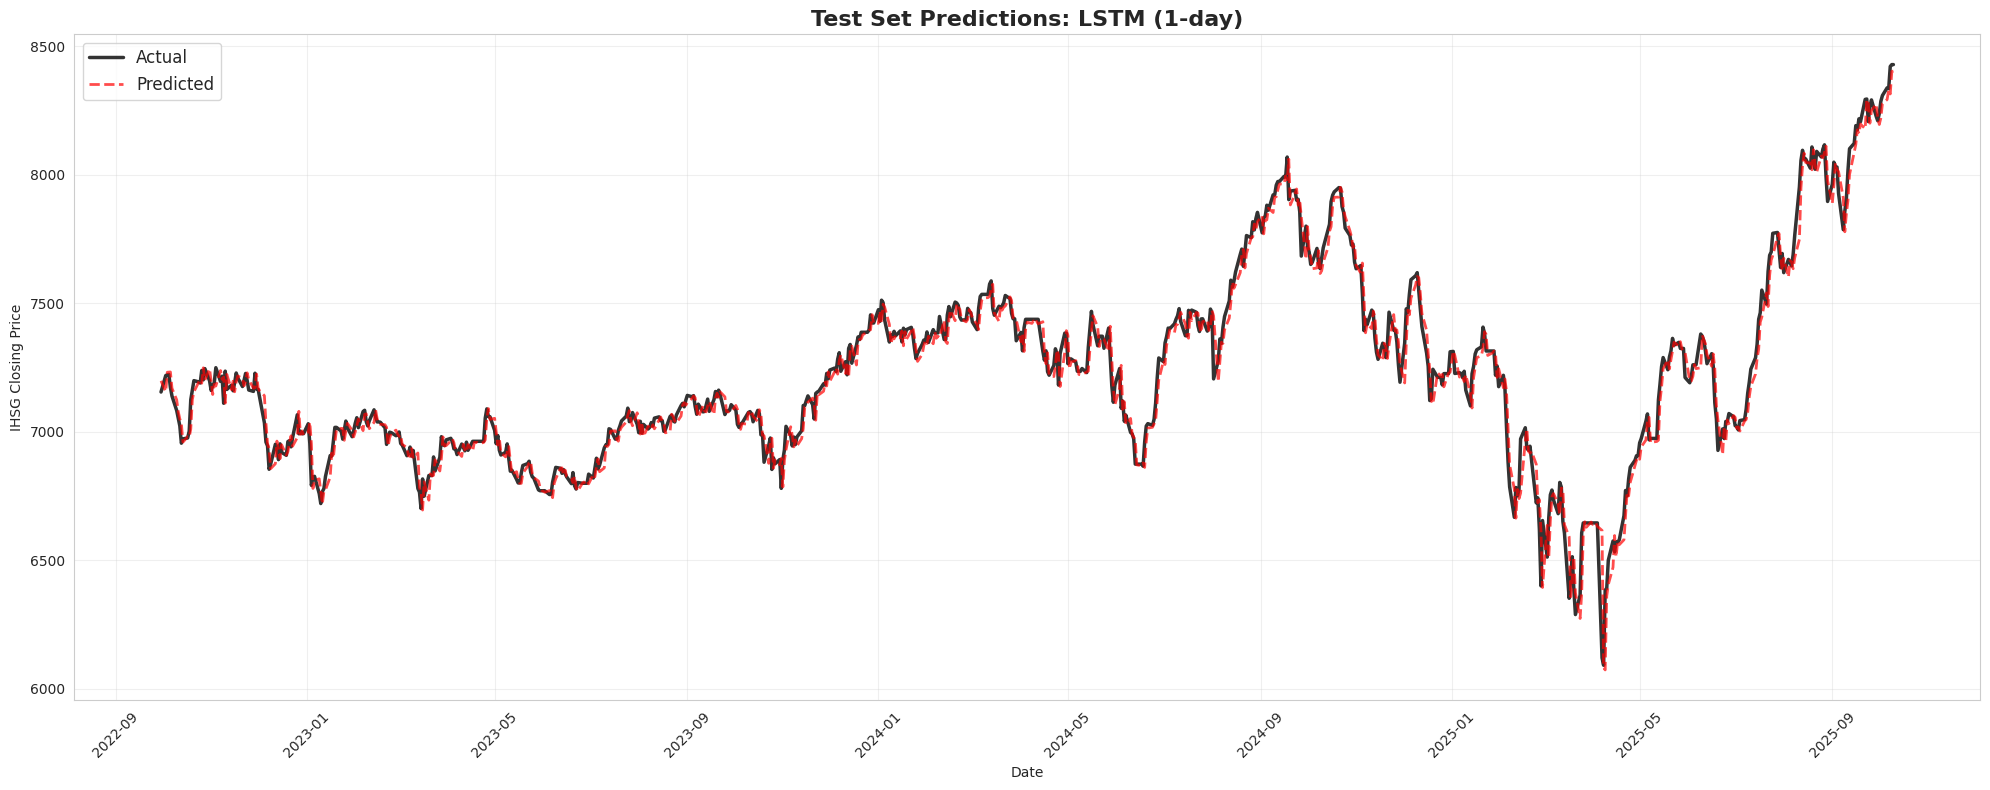

✓ Last 30 days plot saved to: exports/visualizations/lstm_1-day_last30.png


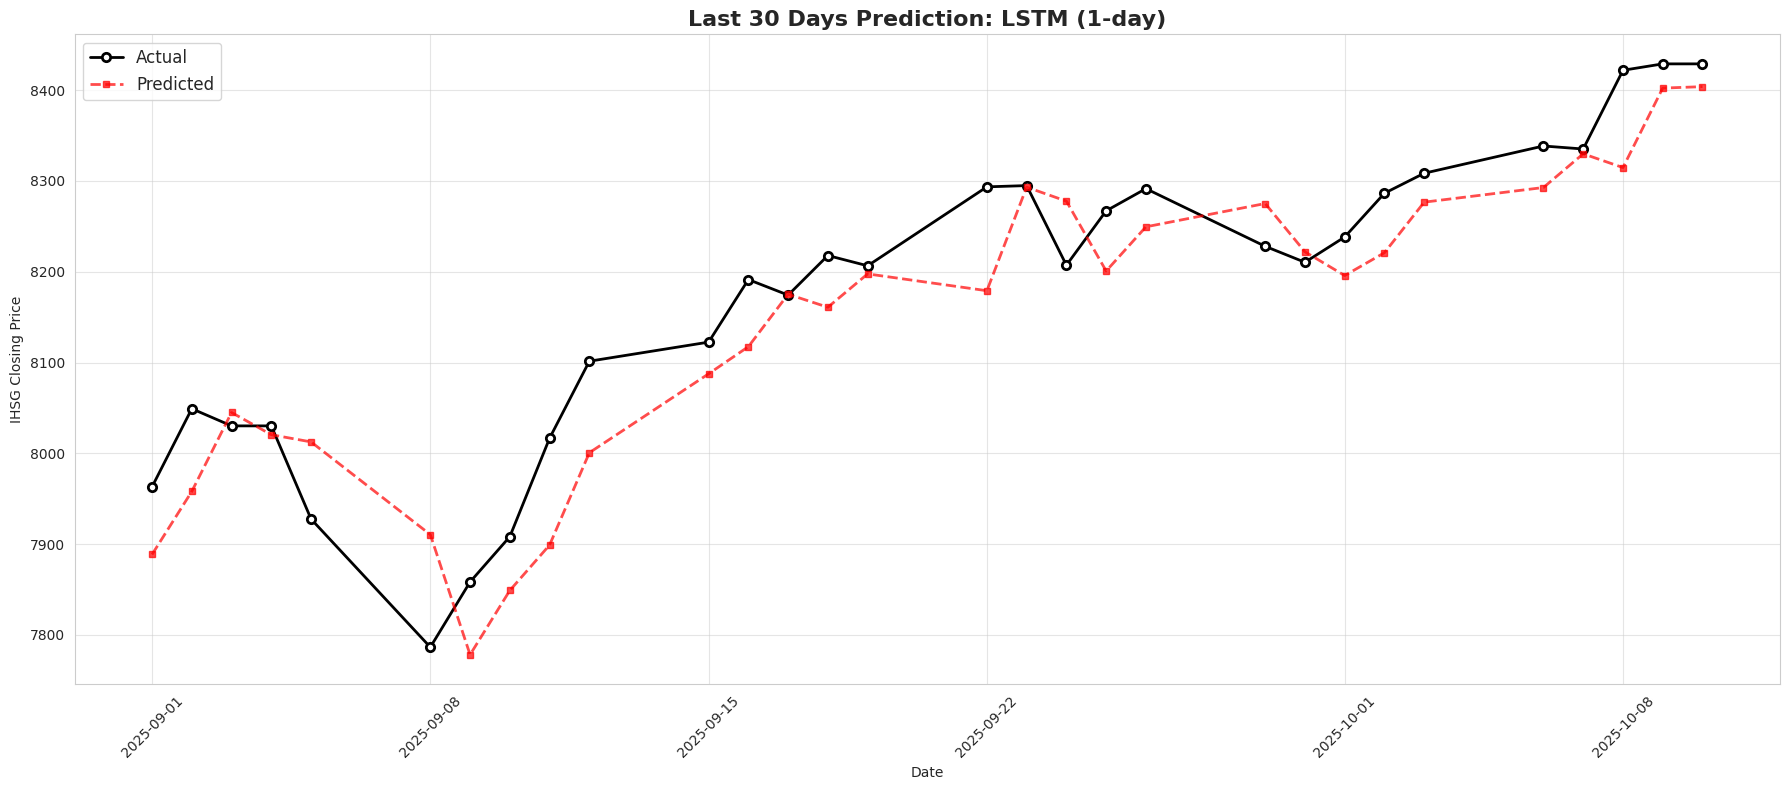

[I 2025-10-12 07:26:59,991] A new study created in memory with name: no-name-6bbed826-c9fb-4880-87ce-6c2578fbf10b



----------------------------------------------------------------------
9.3.2 LSTM - 3-day
----------------------------------------------------------------------

[Hyperparameter Tuning with Optuna]


  0%|          | 0/20 [00:00<?, ?it/s]

  Epoch 10/50: Train=1.166307, Val=0.977607
  Early stopping at epoch 12
  Epoch 10/50: Train=1.116857, Val=0.559979
  Early stopping at epoch 16
  Epoch 10/50: Train=0.901299, Val=1.119575


Best trial: 0. Best value: 0.885139:   5%|▌         | 1/20 [00:30<09:35, 30.29s/it]

...

Best trial: 17. Best value: 0.88116:  95%|█████████▌| 19/20 [07:48<00:16, 16.29s/it]

  Early stopping at epoch 25
[I 2025-10-12 07:34:48,760] Trial 18 finished with value: 0.9070073250585642 and parameters: {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.13087236602728905, 'lr': 0.005248021848268048, 'batch_size': 32}. Best is trial 17 with value: 0.8811602968545187.
  Epoch 10/50: Train=1.212135, Val=1.019770
  Epoch 20/50: Train=1.102177, Val=1.042694
  Early stopping at epoch 22
  Epoch 10/50: Train=1.101742, Val=0.572375
  Early stopping at epoch 12
  Epoch 10/50: Train=0.913803, Val=1.161878


Best trial: 17. Best value: 0.88116: 100%|██████████| 20/20 [08:07<00:00, 24.35s/it]

  Epoch 20/50: Train=0.884667, Val=1.177697
  Early stopping at epoch 20
[I 2025-10-12 07:35:07,060] Trial 19 finished with value: 0.9135773735932814 and parameters: {'hidden_size': 32, 'num_layers': 2, 'dropout': 0.12706175517413246, 'lr': 0.004251831354057326, 'batch_size': 64}. Best is trial 17 with value: 0.8811602968545187.

✓ Best LSTM params: {'hidden_size': 32, 'num_layers': 2, 'dropout': 0.12760927010437373, 'lr': 0.004461146932387229, 'batch_size': 128}

[Training Final LSTM Model]


  Epoch 10/200: Train=1.057745, Val=0.696582
  Epoch 20/200: Train=1.031752, Val=0.696788
  Early stopping at epoch 26

[Evaluation]

Metrics:
  3-day_step1_RMSE: 61.7250
  3-day_step1_MAE: 43.8265
  3-day_step1_R2: 0.9729
  3-day_step1_sMAPE: 0.6103
  3-day_step1_Directional_Accuracy: 48.6658
  3-day_step2_RMSE: 88.3161
  3-day_step2_MAE: 63.9369
  3-day_step2_R2: 0.9452
  3-day_step2_sMAPE: 0.8899
  3-day_step2_Directional_Accuracy: 47.6493
  3-day_step3_RMSE: 107.4610
  3-day_step3_MAE: 79.6643
  3-day_step3_R2: 0.9198
  3-day_step3_sMAPE: 1.1082
  3-day_step3_Directional_Accuracy: 52.0966
  3-day_avg_RMSE: 85.8340
  3-day_avg_MAE: 62.4759
  3-day_avg_sMAPE: 0.8694

[Visualization]
✓ Full train+test plot saved to: exports/visualizations/lstm_3-day_full.png


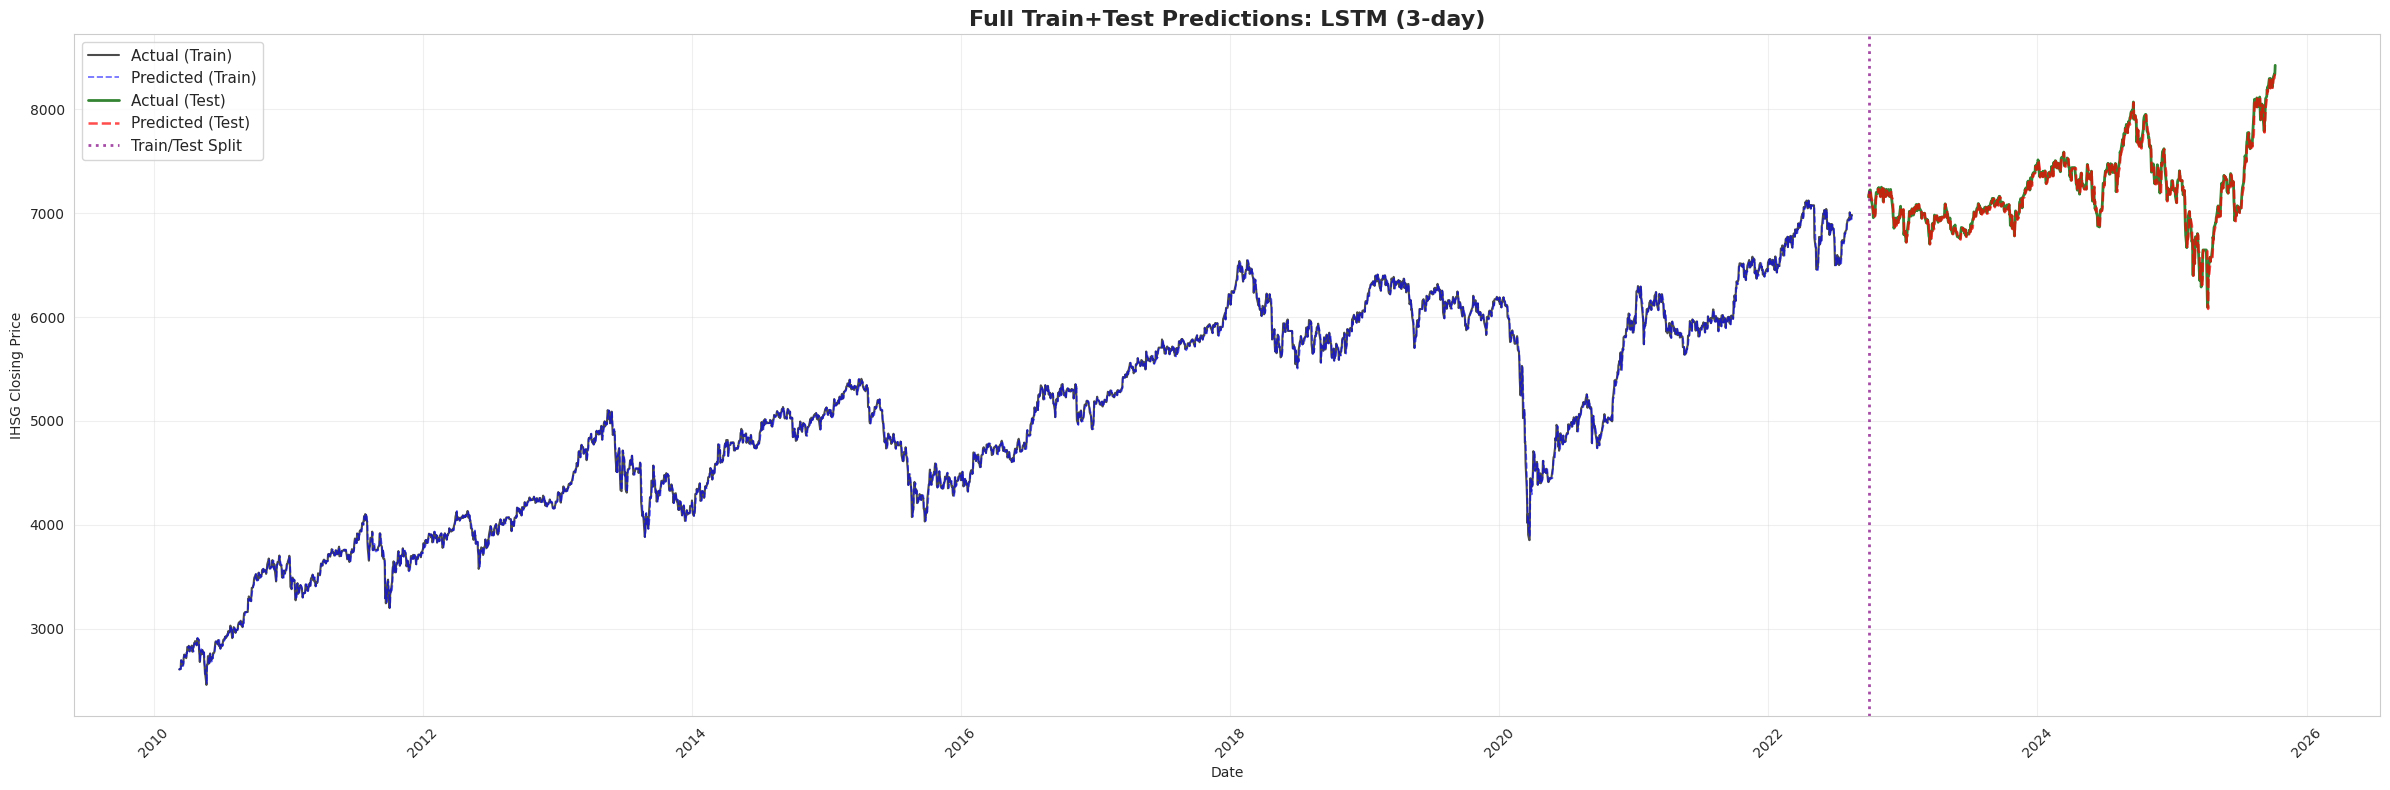

✓ Test-only plot saved to: exports/visualizations/lstm_3-day_test.png


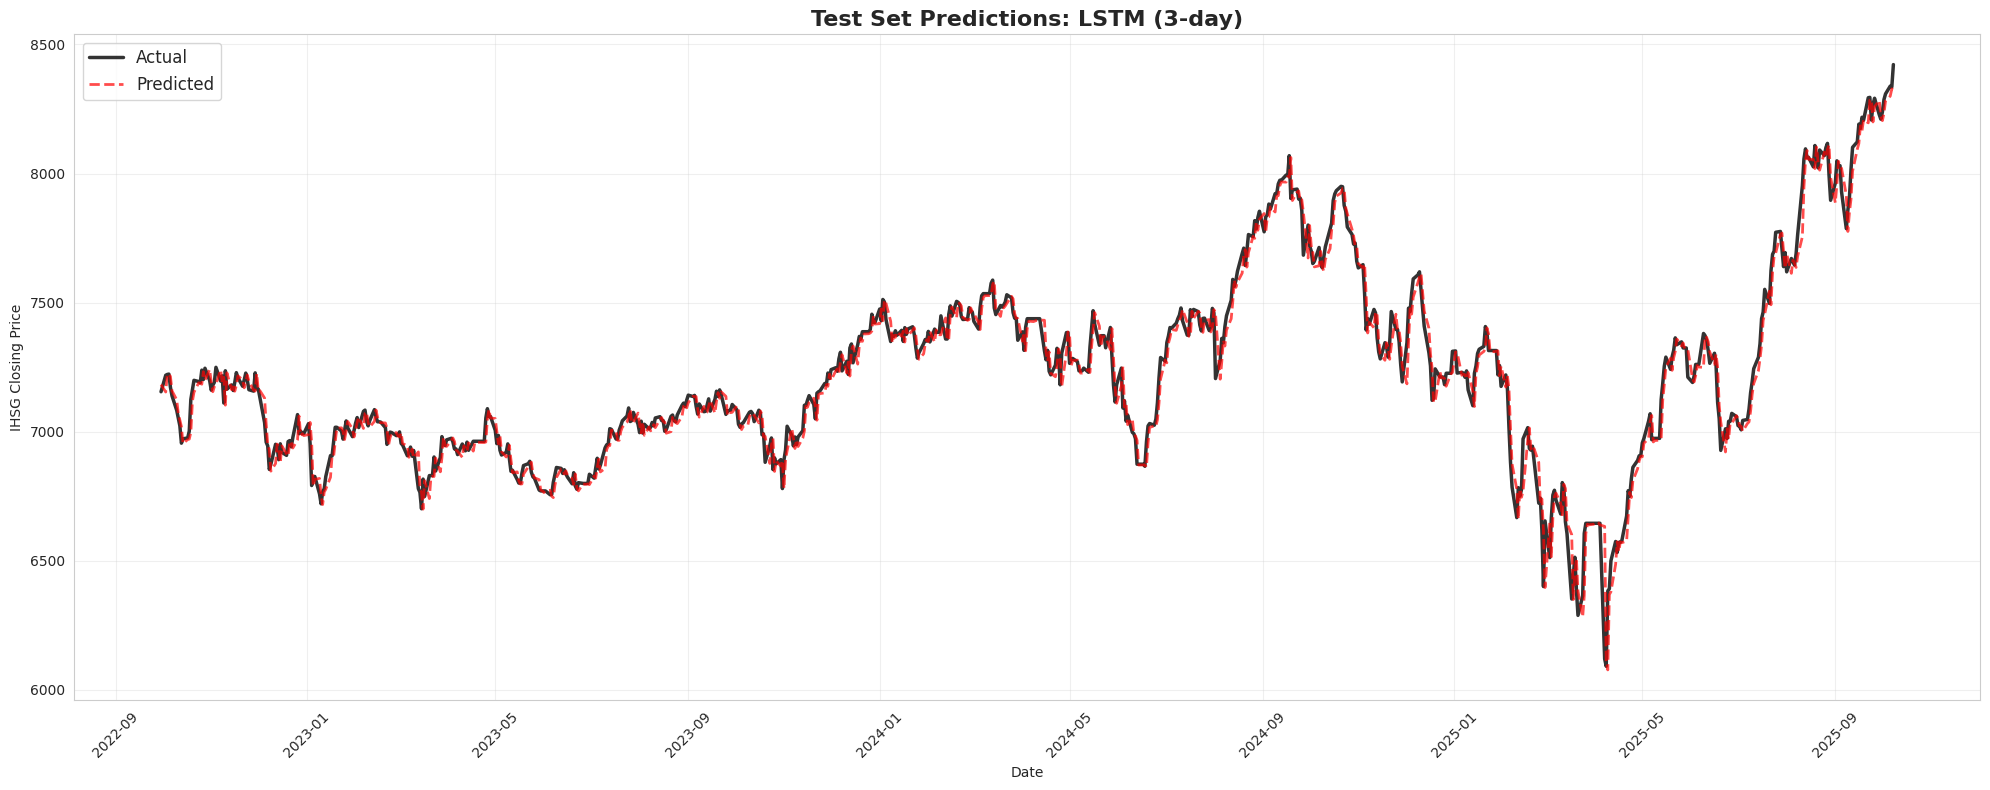

✓ Last 30 days plot saved to: exports/visualizations/lstm_3-day_last30.png


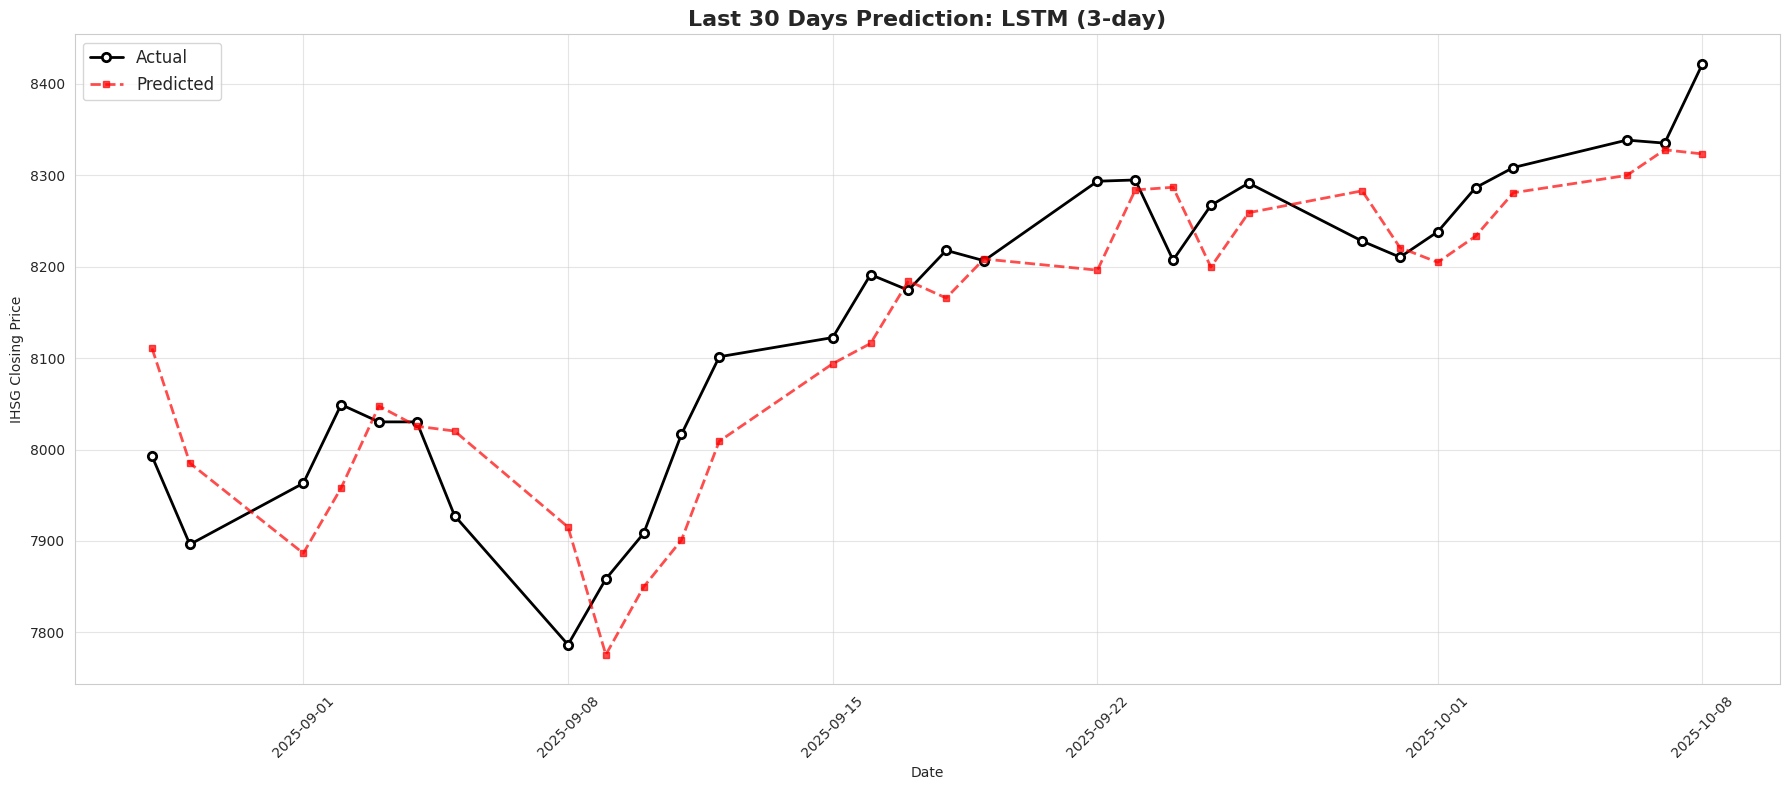

[I 2025-10-12 07:35:25,931] A new study created in memory with name: no-name-0f473012-d844-4f11-88f9-dceeb701ec89



----------------------------------------------------------------------
9.3.3 LSTM - 5-day
----------------------------------------------------------------------

[Hyperparameter Tuning with Optuna]


  0%|          | 0/20 [00:00<?, ?it/s]

  Epoch 10/50: Train=1.186546, Val=1.020698
  Early stopping at epoch 19
  Epoch 10/50: Train=1.104001, Val=0.558317
  Early stopping at epoch 12
  Epoch 10/50: Train=0.923359, Val=1.153614
  Epoch 20/50: Train=0.891812, Val=1.159656


Best trial: 0. Best value: 0.90524:   5%|▌         | 1/20 [00:19<06:13, 19.67s/it]

...

  Early stopping at epoch 13
[I 2025-10-12 07:39:49,240] Trial 10 finished with value: 0.8838481087060202 and parameters: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.23720636332262926, 'lr': 0.0004669662325927465, 'batch_size': 128}. Best is trial 10 with value: 0.8838481087060202.
  Epoch 10/50: Train=1.162478, Val=0.978187
  Epoch 20/50: Train=1.157999, Val=0.974358
  Epoch 30/50: Train=1.143547, Val=0.998091
  Early stopping at epoch 32
  Epoch 10/50: Train=1.112751, Val=0.567619
  Early stopping at epoch 11
  Epoch 10/50: Train=0.940439, Val=1.123509


Best trial: 10. Best value: 0.883848:  60%|██████    | 12/20 [04:59<03:49, 28.74s/it]

  Early stopping at epoch 13
[I 2025-10-12 07:40:25,905] Trial 11 finished with value: 0.8846022990487871 and parameters: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.23703893224740002, 'lr': 0.00044857658963677713, 'batch_size': 128}. Best is trial 10 with value: 0.8838481087060202.
  Epoch 10/50: Train=1.164685, Val=0.977857
  Epoch 20/50: Train=1.157747, Val=0.974689
  Epoch 30/50: Train=1.149483, Val=0.988368
  Early stopping at epoch 32
  Epoch 10/50: Train=1.112897, Val=0.560743
  Early stopping at epoch 13
  Epoch 10/50: Train=0.940227, Val=1.125404


Best trial: 10. Best value: 0.883848:  65%|██████▌   | 13/20 [05:36<03:36, 30.96s/it]

  Early stopping at epoch 11
[I 2025-10-12 07:41:01,974] Trial 12 finished with value: 0.884135270402545 and parameters: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.23042525573088188, 'lr': 0.0004368128170174799, 'batch_size': 128}. Best is trial 10 with value: 0.8838481087060202.
  Epoch 10/50: Train=1.164194, Val=0.975460
  Epoch 20/50: Train=1.162454, Val=0.971697
  Early stopping at epoch 26
  Epoch 10/50: Train=1.113873, Val=0.562813
  Early stopping at epoch 12


In [ ]:
# ===================================================================
# SECTION 9: LSTM MODEL (MODULAR)
# ===================================================================
print("\n" + "="*70)
print("SECTION 9: LSTM MODEL")
print("="*70)

# ===================================================================
# 9.1 LSTM CONFIGURATION
# ===================================================================

# Toggle hyperparameter tuning
TUNE_LSTM = True  # Set to False to use predefined params

# Predefined hyperparameters (if TUNE_LSTM = False)
LSTM_PREDEFINED_PARAMS = {
    'hidden_size': 64,
    'num_layers': 2,
    'dropout': 0.2,
    'lr': 0.001,
    'batch_size': 64
}

# Training configuration
LSTM_MAX_EPOCHS = 200
LSTM_PATIENCE = 20
LSTM_N_TRIALS = 20  # Number of Optuna trials

print(f"\n[9.1] LSTM Configuration:")
print(f"  Tuning enabled: {TUNE_LSTM}")
print(f"  Max epochs: {LSTM_MAX_EPOCHS}")
print(f"  Patience: {LSTM_PATIENCE}")
if TUNE_LSTM:
    print(f"  Optuna trials: {LSTM_N_TRIALS}")
else:
    print(f"  Using predefined params: {LSTM_PREDEFINED_PARAMS}")

# ===================================================================
# 9.2 LSTM ARCHITECTURE OVERVIEW
# ===================================================================

print(f"\n[9.2] LSTM Architecture Overview:")
print("  - Input: Sequential data [batch, timesteps, features]")
print("  - LSTM layers: 1-3 layers with hidden size 32-128")
print("  - Dropout: 0.1-0.3 for regularization")
print("  - Output: Fully connected layer for prediction")
print(f"  - Input size: {X_train_scaled.shape[1]} features")
print(f"  - Timesteps: {TIMESTEPS}")

# ===================================================================
# 9.3 LSTM TRAINING FOR ALL HORIZONS
# ===================================================================

for horizon_name, horizon_steps in config.HORIZONS.items():
    print("\n" + "-"*70)
    print(f"9.3.{list(config.HORIZONS.keys()).index(horizon_name)+1} LSTM - {horizon_name}")
    print("-"*70)
    
    X_train_seq = sequences[horizon_name]['X_train']
    y_train_seq = sequences[horizon_name]['y_train']
    X_test_seq = sequences[horizon_name]['X_test']
    y_test_seq = sequences[horizon_name]['y_test']
    
    input_size = X_train_seq.shape[2]
    output_size = horizon_steps
    
    test_dates_horizon = dates_test[TIMESTEPS:TIMESTEPS+len(X_test_seq)]
    
    # Split validation set
    val_size = int(len(X_train_seq) * 0.15)
    X_val = X_train_seq[-val_size:]
    y_val = y_train_seq[-val_size:]
    X_train_final = X_train_seq[:-val_size]
    y_train_final = y_train_seq[:-val_size]
    
    # ===================================================================
    # 9.3.A HYPERPARAMETER TUNING (Optional)
    # ===================================================================
    
    if TUNE_LSTM:
        print("\n[Hyperparameter Tuning with Optuna]")
        
        def objective_lstm_local(trial):
            params = {
                'hidden_size': trial.suggest_categorical('hidden_size', [32, 64, 128]),
                'num_layers': trial.suggest_int('num_layers', 1, 3),
                'dropout': trial.suggest_float('dropout', 0.1, 0.3),
                'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
                'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128])
            }
            
            tscv = TimeSeriesSplit(n_splits=3)
            fold_scores = []
            
            for train_idx, val_idx in tscv.split(X_train_seq):
                X_fold_train = X_train_seq[train_idx]
                y_fold_train = y_train_seq[train_idx]
                X_fold_val = X_train_seq[val_idx]
                y_fold_val = y_train_seq[val_idx]
                
                train_dataset = TimeSeriesDataset(X_fold_train, 
                                                 y_fold_train.reshape(-1, output_size))
                val_dataset = TimeSeriesDataset(X_fold_val, 
                                               y_fold_val.reshape(-1, output_size))
                
                train_loader = DataLoader(train_dataset, batch_size=params['batch_size'],
                                         shuffle=False)
                val_loader = DataLoader(val_dataset, batch_size=params['batch_size'],
                                       shuffle=False)
                
                model = LSTMModel(input_size, params['hidden_size'], params['num_layers'],
                                 output_size, params['dropout']).to(config.DEVICE)
                
                criterion = nn.MSELoss()
                optimizer = Adam(model.parameters(), lr=params['lr'])
                
                _, _, val_loss = train_model(model, train_loader, val_loader, criterion,
                                            optimizer, epochs=50, patience=10,
                                            device=config.DEVICE, model_name="LSTM")
                
                fold_scores.append(val_loss)
            
            return np.mean(fold_scores)
        
        study_lstm = optuna.create_study(direction='minimize')
        study_lstm.optimize(objective_lstm_local, n_trials=LSTM_N_TRIALS, 
                           show_progress_bar=True)
        
        best_params_lstm = study_lstm.best_params
        print(f"\n✓ Best LSTM params: {best_params_lstm}")
    else:
        print("\n[Using Predefined Parameters]")
        best_params_lstm = LSTM_PREDEFINED_PARAMS.copy()
        print(f"  Parameters: {best_params_lstm}")
    
    # ===================================================================
    # 9.3.B FINAL TRAINING
    # ===================================================================
    
    print("\n[Training Final LSTM Model]")
    
    train_dataset_final = TimeSeriesDataset(X_train_final, 
                                           y_train_final.reshape(-1, output_size))
    val_dataset = TimeSeriesDataset(X_val, y_val.reshape(-1, output_size))
    
    train_loader_final = DataLoader(train_dataset_final, 
                                    batch_size=best_params_lstm['batch_size'],
                                    shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=best_params_lstm['batch_size'],
                           shuffle=False)
    
    lstm_model = LSTMModel(input_size, best_params_lstm['hidden_size'],
                          best_params_lstm['num_layers'], output_size,
                          best_params_lstm['dropout']).to(config.DEVICE)
    
    criterion = nn.MSELoss()
    optimizer = Adam(lstm_model.parameters(), lr=best_params_lstm['lr'])
    
    lstm_model, history, _ = train_model(lstm_model, train_loader_final, val_loader,
                                        criterion, optimizer, epochs=LSTM_MAX_EPOCHS,
                                        patience=LSTM_PATIENCE, device=config.DEVICE,
                                        model_name=f"LSTM-{horizon_name}")
    
    torch.save(lstm_model.state_dict(), 
              f"{config.OUTPUT_DIR}/models/lstm_{horizon_name}.pt")
    trained_models[f'LSTM_{horizon_name}'] = lstm_model
    
    # ===================================================================
    # 9.3.C EVALUATION
    # ===================================================================
    
    print("\n[Evaluation]")
    
    # Test predictions
    lstm_pred_test, lstm_actual_test = evaluate_model(lstm_model, X_test_seq, y_test_seq,
                                                      scaler_y, config.DEVICE, 
                                                      last_actual_price_train)
    
    # Train predictions for full visualization
    lstm_pred_train, lstm_actual_train = evaluate_model(lstm_model, X_train_seq, y_train_seq,
                                                        scaler_y, config.DEVICE,
                                                        data['IHSG'].iloc[0])
    
    train_dates_horizon = dates_train[TIMESTEPS:TIMESTEPS+len(X_train_seq)]
    
    # Calculate metrics
    metrics = calculate_metrics(lstm_actual_test, lstm_pred_test, horizon_name)
    metrics['Model'] = 'LSTM'
    metrics['Horizon'] = horizon_name
    
    if horizon_steps == 1:
        econ_metrics = calculate_economic_metrics(lstm_actual_test, lstm_pred_test,
                                                  config.TRANSACTION_COST,
                                                  config.RISK_FREE_RATE)
        metrics.update(econ_metrics)
    
    all_results.append(metrics)
    all_predictions[f'LSTM_{horizon_name}'] = {
        'predictions': lstm_pred_test,
        'actuals': lstm_actual_test,
        'dates': test_dates_horizon
    }
    
    print("\nMetrics:")
    for k, v in metrics.items():
        if k not in ['Model', 'Horizon']:
            print(f"  {k}: {v:.4f}")
    
    # ===================================================================
    # 9.3.D VISUALIZATION
    # ===================================================================
    
    print("\n[Visualization]")
    
    # 1. Full Train+Test
    plot_train_test_full(lstm_actual_train, lstm_pred_train, 
                         lstm_actual_test, lstm_pred_test,
                         train_dates_horizon, test_dates_horizon,
                         'LSTM', horizon_name,
                         f"{config.OUTPUT_DIR}/visualizations/lstm_{horizon_name}_full.png")
    
    # 2. Test only
    plot_test_only(lstm_actual_test, lstm_pred_test, test_dates_horizon,
                   'LSTM', horizon_name,
                   f"{config.OUTPUT_DIR}/visualizations/lstm_{horizon_name}_test.png")
    
    # 3. Last 30 days
    plot_last_n_days(lstm_actual_test, lstm_pred_test, test_dates_horizon,
                     'LSTM', horizon_name, 30,
                     f"{config.OUTPUT_DIR}/visualizations/lstm_{horizon_name}_last30.png")

# Multi-horizon comparison for LSTM
plot_all_horizons_for_model('LSTM', all_predictions,
                            f"{config.OUTPUT_DIR}/visualizations/lstm_multihorizon.png")

print("\n✓ LSTM training complete for all horizons")

In [ ]:
# ===================================================================
# SECTION 10: TCN MODEL (MODULAR)
# ===================================================================
print("\n" + "="*70)
print("SECTION 10: TCN MODEL")
print("="*70)

# ===================================================================
# 10.1 TCN CONFIGURATION
# ===================================================================

TUNE_TCN = True

TCN_PREDEFINED_PARAMS = {
    'num_channels': [64, 128, 256],
    'kernel_size': 3,
    'dropout': 0.2,
    'lr': 0.001,
    'batch_size': 64
}

TCN_MAX_EPOCHS = 200
TCN_PATIENCE = 20
TCN_N_TRIALS = 20

print(f"\n[10.1] TCN Configuration:")
print(f"  Tuning enabled: {TUNE_TCN}")
print(f"  Max epochs: {TCN_MAX_EPOCHS}")
print(f"  Patience: {TCN_PATIENCE}")
if TUNE_TCN:
    print(f"  Optuna trials: {TCN_N_TRIALS}")
else:
    print(f"  Using predefined params: {TCN_PREDEFINED_PARAMS}")

# ===================================================================
# 10.2 TCN ARCHITECTURE OVERVIEW
# ===================================================================

print(f"\n[10.2] TCN Architecture Overview:")
print("  - Temporal Convolutional Network with dilated convolutions")
print("  - Causal convolutions for temporal dependencies")
print("  - Residual connections for gradient flow")
print("  - Receptive field grows exponentially with dilation")

# ===================================================================
# 10.3 TCN TRAINING FOR ALL HORIZONS
# ===================================================================

for horizon_name, horizon_steps in config.HORIZONS.items():
    print("\n" + "-"*70)
    print(f"10.3.{list(config.HORIZONS.keys()).index(horizon_name)+1} TCN - {horizon_name}")
    print("-"*70)
    
    X_train_seq = sequences[horizon_name]['X_train']
    y_train_seq = sequences[horizon_name]['y_train']
    X_test_seq = sequences[horizon_name]['X_test']
    y_test_seq = sequences[horizon_name]['y_test']
    
    input_size = X_train_seq.shape[2]
    output_size = horizon_steps
    
    test_dates_horizon = dates_test[TIMESTEPS:TIMESTEPS+len(X_test_seq)]
    
    val_size = int(len(X_train_seq) * 0.15)
    X_val = X_train_seq[-val_size:]
    y_val = y_train_seq[-val_size:]
    X_train_final = X_train_seq[:-val_size]
    y_train_final = y_train_seq[:-val_size]
    
    # ===================================================================
    # 10.3.A HYPERPARAMETER TUNING
    # ===================================================================
    
    if TUNE_TCN:
        print("\n[Hyperparameter Tuning with Optuna]")
        
        def objective_tcn_local(trial):
            num_levels = trial.suggest_int('num_levels', 2, 4)
            base_channels = trial.suggest_categorical('base_channels', [32, 64, 128])
            
            params = {
                'num_channels': [base_channels * (i+1) for i in range(num_levels)],
                'kernel_size': trial.suggest_categorical('kernel_size', [3, 5, 7]),
                'dropout': trial.suggest_float('dropout', 0.1, 0.3),
                'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
                'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128])
            }
            
            tscv = TimeSeriesSplit(n_splits=3)
            fold_scores = []
            
            for train_idx, val_idx in tscv.split(X_train_seq):
                X_fold_train = X_train_seq[train_idx]
                y_fold_train = y_train_seq[train_idx]
                X_fold_val = X_train_seq[val_idx]
                y_fold_val = y_train_seq[val_idx]
                
                train_dataset = TimeSeriesDataset(X_fold_train,
                                                 y_fold_train.reshape(-1, output_size))
                val_dataset = TimeSeriesDataset(X_fold_val,
                                               y_fold_val.reshape(-1, output_size))
                
                train_loader = DataLoader(train_dataset, batch_size=params['batch_size'],
                                         shuffle=False)
                val_loader = DataLoader(val_dataset, batch_size=params['batch_size'],
                                       shuffle=False)
                
                model = TCNModel(input_size, output_size, params['num_channels'],
                                params['kernel_size'], params['dropout']).to(config.DEVICE)
                
                criterion = nn.MSELoss()
                optimizer = Adam(model.parameters(), lr=params['lr'])
                
                _, _, val_loss = train_model(model, train_loader, val_loader, criterion,
                                            optimizer, epochs=50, patience=10,
                                            device=config.DEVICE, model_name="TCN")
                
                fold_scores.append(val_loss)
            
            return np.mean(fold_scores)
        
        study_tcn = optuna.create_study(direction='minimize')
        study_tcn.optimize(objective_tcn_local, n_trials=TCN_N_TRIALS,
                          show_progress_bar=True)
        
        best_params_tcn = study_tcn.best_params
        
        # Reconstruct num_channels
        num_levels = best_params_tcn['num_levels']
        base_channels = best_params_tcn['base_channels']
        best_params_tcn['num_channels'] = [base_channels * (i+1) for i in range(num_levels)]
        
        print(f"\n✓ Best TCN params: {best_params_tcn}")
    else:
        print("\n[Using Predefined Parameters]")
        best_params_tcn = TCN_PREDEFINED_PARAMS.copy()
        print(f"  Parameters: {best_params_tcn}")
    
    # ===================================================================
    # 10.3.B FINAL TRAINING
    # ===================================================================
    
    print("\n[Training Final TCN Model]")
    
    train_dataset_final = TimeSeriesDataset(X_train_final,
                                           y_train_final.reshape(-1, output_size))
    val_dataset = TimeSeriesDataset(X_val, y_val.reshape(-1, output_size))
    
    train_loader_final = DataLoader(train_dataset_final,
                                    batch_size=best_params_tcn['batch_size'],
                                    shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=best_params_tcn['batch_size'],
                           shuffle=False)
    
    tcn_model = TCNModel(input_size, output_size, best_params_tcn['num_channels'],
                        best_params_tcn['kernel_size'],
                        best_params_tcn['dropout']).to(config.DEVICE)
    
    criterion = nn.MSELoss()
    optimizer = Adam(tcn_model.parameters(), lr=best_params_tcn['lr'])
    
    tcn_model, history, _ = train_model(tcn_model, train_loader_final, val_loader,
                                       criterion, optimizer, epochs=TCN_MAX_EPOCHS,
                                       patience=TCN_PATIENCE, device=config.DEVICE,
                                       model_name=f"TCN-{horizon_name}")
    
    torch.save(tcn_model.state_dict(),
              f"{config.OUTPUT_DIR}/models/tcn_{horizon_name}.pt")
    trained_models[f'TCN_{horizon_name}'] = tcn_model
    
    # ===================================================================
    # 10.3.C EVALUATION
    # ===================================================================
    
    print("\n[Evaluation]")
    
    tcn_pred_test, tcn_actual_test = evaluate_model(tcn_model, X_test_seq, y_test_seq,
                                                    scaler_y, config.DEVICE,
                                                    last_actual_price_train)
    
    tcn_pred_train, tcn_actual_train = evaluate_model(tcn_model, X_train_seq, y_train_seq,
                                                      scaler_y, config.DEVICE,
                                                      data['IHSG'].iloc[0])
    
    train_dates_horizon = dates_train[TIMESTEPS:TIMESTEPS+len(X_train_seq)]
    
    metrics = calculate_metrics(tcn_actual_test, tcn_pred_test, horizon_name)
    metrics['Model'] = 'TCN'
    metrics['Horizon'] = horizon_name
    
    if horizon_steps == 1:
        econ_metrics = calculate_economic_metrics(tcn_actual_test, tcn_pred_test,
                                                  config.TRANSACTION_COST,
                                                  config.RISK_FREE_RATE)
        metrics.update(econ_metrics)
    
    all_results.append(metrics)
    all_predictions[f'TCN_{horizon_name}'] = {
        'predictions': tcn_pred_test,
        'actuals': tcn_actual_test,
        'dates': test_dates_horizon
    }
    
    print("\nMetrics:")
    for k, v in metrics.items():
        if k not in ['Model', 'Horizon']:
            print(f"  {k}: {v:.4f}")
    
    # ===================================================================
    # 10.3.D VISUALIZATION
    # ===================================================================
    
    print("\n[Visualization]")
    
    plot_train_test_full(tcn_actual_train, tcn_pred_train,
                         tcn_actual_test, tcn_pred_test,
                         train_dates_horizon, test_dates_horizon,
                         'TCN', horizon_name,
                         f"{config.OUTPUT_DIR}/visualizations/tcn_{horizon_name}_full.png")
    
    plot_test_only(tcn_actual_test, tcn_pred_test, test_dates_horizon,
                   'TCN', horizon_name,
                   f"{config.OUTPUT_DIR}/visualizations/tcn_{horizon_name}_test.png")
    
    plot_last_n_days(tcn_actual_test, tcn_pred_test, test_dates_horizon,
                     'TCN', horizon_name, 30,
                     f"{config.OUTPUT_DIR}/visualizations/tcn_{horizon_name}_last30.png")

plot_all_horizons_for_model('TCN', all_predictions,
                            f"{config.OUTPUT_DIR}/visualizations/tcn_multihorizon.png")

print("\n✓ TCN training complete for all horizons")

In [ ]:
# ===================================================================
# SECTION 11: TABNET-LSTM HYBRID (MODULAR)
# ===================================================================
print("\n" + "="*70)
print("SECTION 11: TABNET-LSTM HYBRID MODEL")
print("="*70)

# ===================================================================
# 11.1 TABNET-LSTM CONFIGURATION
# ===================================================================

TUNE_TABNET_LSTM = False  # Usually skip for complex hybrid models

TABNET_LSTM_PREDEFINED_PARAMS = {
    'n_d': 32,
    'n_a': 32,
    'n_steps': 5,
    'lstm_hidden': 64,
    'lstm_layers': 2,
    'dropout': 0.2,
    'lr': 0.001,
    'batch_size': 64
}

TABNET_LSTM_MAX_EPOCHS = 200
TABNET_LSTM_PATIENCE = 20
TABNET_LSTM_N_TRIALS = 20

print(f"\n[11.1] TabNet-LSTM Configuration:")
print(f"  Tuning enabled: {TUNE_TABNET_LSTM}")
print(f"  Max epochs: {TABNET_LSTM_MAX_EPOCHS}")
print(f"  Patience: {TABNET_LSTM_PATIENCE}")
if not TUNE_TABNET_LSTM:
    print(f"  Using predefined params: {TABNET_LSTM_PREDEFINED_PARAMS}")

# ===================================================================
# 11.2 TABNET-LSTM TRAINING FOR ALL HORIZONS
# ===================================================================

for horizon_name, horizon_steps in config.HORIZONS.items():
    print("\n" + "-"*70)
    print(f"11.2.{list(config.HORIZONS.keys()).index(horizon_name)+1} TabNet-LSTM - {horizon_name}")
    print("-"*70)
    
    X_train_seq = sequences[horizon_name]['X_train']
    y_train_seq = sequences[horizon_name]['y_train']
    X_test_seq = sequences[horizon_name]['X_test']
    y_test_seq = sequences[horizon_name]['y_test']
    
    input_size = X_train_seq.shape[2]
    output_size = horizon_steps
    
    test_dates_horizon = dates_test[TIMESTEPS:TIMESTEPS+len(X_test_seq)]
    
    val_size = int(len(X_train_seq) * 0.15)
    X_val = X_train_seq[-val_size:]
    y_val = y_train_seq[-val_size:]
    X_train_final = X_train_seq[:-val_size]
    y_train_final = y_train_seq[:-val_size]
    
    # Use predefined or tuned parameters
    if not TUNE_TABNET_LSTM:
        best_params = TABNET_LSTM_PREDEFINED_PARAMS.copy()
        print(f"\n[Using Predefined Parameters]")
        print(f"  Parameters: {best_params}")
    
    # ===================================================================
    # 11.2.A FINAL TRAINING
    # ===================================================================
    
    print("\n[Training Final TabNet-LSTM Model]")
    
    tabnet_params = {
        'n_d': best_params['n_d'],
        'n_a': best_params['n_a'],
        'n_steps': best_params['n_steps']
    }
    
    train_dataset_final = TimeSeriesDataset(X_train_final,
                                           y_train_final.reshape(-1, output_size))
    val_dataset = TimeSeriesDataset(X_val, y_val.reshape(-1, output_size))
    
    train_loader_final = DataLoader(train_dataset_final,
                                    batch_size=best_params['batch_size'],
                                    shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'],
                           shuffle=False)
    
    tabnet_lstm_model = TabNetLSTM(input_size, tabnet_params,
                                   best_params['lstm_hidden'],
                                   best_params['lstm_layers'],
                                   output_size,
                                   best_params['dropout']).to(config.DEVICE)
    
    criterion = nn.MSELoss()
    optimizer = Adam(tabnet_lstm_model.parameters(), lr=best_params['lr'])
    
    tabnet_lstm_model, history, _ = train_model(tabnet_lstm_model, train_loader_final,
                                               val_loader, criterion, optimizer,
                                               epochs=TABNET_LSTM_MAX_EPOCHS,
                                               patience=TABNET_LSTM_PATIENCE,
                                               device=config.DEVICE,
                                               model_name=f"TabNet-LSTM-{horizon_name}")
    
    torch.save(tabnet_lstm_model.state_dict(),
              f"{config.OUTPUT_DIR}/models/tabnet_lstm_{horizon_name}.pt")
    trained_models[f'TabNet-LSTM_{horizon_name}'] = tabnet_lstm_model
    
    # ===================================================================
    # 11.2.B EVALUATION & VISUALIZATION
    # ===================================================================
    
    print("\n[Evaluation]")
    
    tabnet_lstm_pred_test, tabnet_lstm_actual_test = evaluate_model(
        tabnet_lstm_model, X_test_seq, y_test_seq,
        scaler_y, config.DEVICE, last_actual_price_train)
    
    tabnet_lstm_pred_train, tabnet_lstm_actual_train = evaluate_model(
        tabnet_lstm_model, X_train_seq, y_train_seq,
        scaler_y, config.DEVICE, data['IHSG'].iloc[0])
    
    train_dates_horizon = dates_train[TIMESTEPS:TIMESTEPS+len(X_train_seq)]
    
    metrics = calculate_metrics(tabnet_lstm_actual_test, tabnet_lstm_pred_test, horizon_name)
    metrics['Model'] = 'TabNet-LSTM'
    metrics['Horizon'] = horizon_name
    
    if horizon_steps == 1:
        econ_metrics = calculate_economic_metrics(tabnet_lstm_actual_test,
                                                  tabnet_lstm_pred_test,
                                                  config.TRANSACTION_COST,
                                                  config.RISK_FREE_RATE)
        metrics.update(econ_metrics)
    
    all_results.append(metrics)
    all_predictions[f'TabNet-LSTM_{horizon_name}'] = {
        'predictions': tabnet_lstm_pred_test,
        'actuals': tabnet_lstm_actual_test,
        'dates': test_dates_horizon
    }
    
    print("\nMetrics:")
    for k, v in metrics.items():
        if k not in ['Model', 'Horizon']:
            print(f"  {k}: {v:.4f}")
    
    print("\n[Visualization]")
    
    plot_train_test_full(tabnet_lstm_actual_train, tabnet_lstm_pred_train,
                         tabnet_lstm_actual_test, tabnet_lstm_pred_test,
                         train_dates_horizon, test_dates_horizon,
                         'TabNet-LSTM', horizon_name,
                         f"{config.OUTPUT_DIR}/visualizations/tabnet_lstm_{horizon_name}_full.png")
    
    plot_test_only(tabnet_lstm_actual_test, tabnet_lstm_pred_test, test_dates_horizon,
                   'TabNet-LSTM', horizon_name,
                   f"{config.OUTPUT_DIR}/visualizations/tabnet_lstm_{horizon_name}_test.png")
    
    plot_last_n_days(tabnet_lstm_actual_test, tabnet_lstm_pred_test, test_dates_horizon,
                     'TabNet-LSTM', horizon_name, 30,
                     f"{config.OUTPUT_DIR}/visualizations/tabnet_lstm_{horizon_name}_last30.png")

plot_all_horizons_for_model('TabNet-LSTM', all_predictions,
                            f"{config.OUTPUT_DIR}/visualizations/tabnet_lstm_multihorizon.png")

print("\n✓ TabNet-LSTM training complete for all horizons")

In [ ]:
# ===================================================================
# SECTION 12: TABNET-TCN HYBRID (MODULAR) - KEY MODEL
# ===================================================================
print("\n" + "="*70)
print("SECTION 12: TABNET-TCN HYBRID MODEL ⭐ KEY MODEL")
print("="*70)

# ===================================================================
# 12.1 TABNET-TCN CONFIGURATION
# ===================================================================

TUNE_TABNET_TCN = True

TABNET_TCN_PREDEFINED_PARAMS = {
    'n_d': 32,
    'n_a': 32,
    'n_steps': 5,
    'tcn_channels': [64, 128, 256],
    'tcn_kernel_size': 3,
    'dropout': 0.2,
    'lr': 0.001,
    'batch_size': 64
}

TABNET_TCN_MAX_EPOCHS = 200
TABNET_TCN_PATIENCE = 20
TABNET_TCN_N_TRIALS = 20

print(f"\n[12.1] TabNet-TCN Configuration:")
print(f"  Tuning enabled: {TUNE_TABNET_TCN}")
print(f"  Max epochs: {TABNET_TCN_MAX_EPOCHS}")
print(f"  Patience: {TABNET_TCN_PATIENCE}")
if TUNE_TABNET_TCN:
    print(f"  Optuna trials: {TABNET_TCN_N_TRIALS}")
else:
    print(f"  Using predefined params: {TABNET_TCN_PREDEFINED_PARAMS}")

# ===================================================================
# 12.2 TABNET-TCN TRAINING FOR ALL HORIZONS
# ===================================================================

for horizon_name, horizon_steps in config.HORIZONS.items():
    print("\n" + "-"*70)
    print(f"12.2.{list(config.HORIZONS.keys()).index(horizon_name)+1} TabNet-TCN - {horizon_name} ⭐")
    print("-"*70)
    
    X_train_seq = sequences[horizon_name]['X_train']
    y_train_seq = sequences[horizon_name]['y_train']
    X_test_seq = sequences[horizon_name]['X_test']
    y_test_seq = sequences[horizon_name]['y_test']
    
    input_size = X_train_seq.shape[2]
    output_size = horizon_steps
    
    test_dates_horizon = dates_test[TIMESTEPS:TIMESTEPS+len(X_test_seq)]
    
    val_size = int(len(X_train_seq) * 0.15)
    X_val = X_train_seq[-val_size:]
    y_val = y_train_seq[-val_size:]
    X_train_final = X_train_seq[:-val_size]
    y_train_final = y_train_seq[:-val_size]
    
    # ===================================================================
    # 12.2.A HYPERPARAMETER TUNING
    # ===================================================================
    
    if TUNE_TABNET_TCN:
        print("\n[Hyperparameter Tuning with Optuna]")
        
        def objective_tabnet_tcn_local(trial):
            tabnet_params = {
                'n_d': trial.suggest_categorical('n_d', [16, 32, 64]),
                'n_a': trial.suggest_categorical('n_a', [16, 32, 64]),
                'n_steps': trial.suggest_int('n_steps', 3, 7)
            }
            
            num_levels = trial.suggest_int('num_levels', 2, 4)
            base_channels = trial.suggest_categorical('base_channels', [32, 64, 96])
            
            params = {
                'tabnet_params': tabnet_params,
                'tcn_channels': [base_channels * (i+1) for i in range(num_levels)],
                'tcn_kernel_size': trial.suggest_categorical('tcn_kernel_size', [3, 5, 7]),
                'dropout': trial.suggest_float('dropout', 0.1, 0.3),
                'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
                'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128])
            }
            
            tscv = TimeSeriesSplit(n_splits=3)
            fold_scores = []
            
            for train_idx, val_idx in tscv.split(X_train_seq):
                X_fold_train = X_train_seq[train_idx]
                y_fold_train = y_train_seq[train_idx]
                X_fold_val = X_train_seq[val_idx]
                y_fold_val = y_train_seq[val_idx]
                
                train_dataset = TimeSeriesDataset(X_fold_train,
                                                 y_fold_train.reshape(-1, output_size))
                val_dataset = TimeSeriesDataset(X_fold_val,
                                               y_fold_val.reshape(-1, output_size))
                
                train_loader = DataLoader(train_dataset, batch_size=params['batch_size'],
                                         shuffle=False, drop_last=True)
                val_loader = DataLoader(val_dataset, batch_size=params['batch_size'],
                                       shuffle=False)
                
                model = TabNetTCN(input_size, tabnet_params, params['tcn_channels'],
                                 params['tcn_kernel_size'], output_size,
                                 params['dropout']).to(config.DEVICE)
                
                criterion = nn.MSELoss()
                optimizer = Adam(model.parameters(), lr=params['lr'])
                
                _, _, val_loss = train_model(model, train_loader, val_loader, criterion,
                                            optimizer, epochs=50, patience=10,
                                            device=config.DEVICE, model_name="TabNet-TCN")
                
                fold_scores.append(val_loss)
            
            return np.mean(fold_scores)
        
        study_tabnet_tcn = optuna.create_study(direction='minimize')
        study_tabnet_tcn.optimize(objective_tabnet_tcn_local, n_trials=TABNET_TCN_N_TRIALS,
                                  show_progress_bar=True)
        
        best_params = study_tabnet_tcn.best_params
        
        # Reconstruct tcn_channels
        num_levels = best_params['num_levels']
        base_channels = best_params['base_channels']
        tcn_channels = [base_channels * (i+1) for i in range(num_levels)]
        
        best_params_tabnet_tcn = {
            'n_d': best_params['n_d'],
            'n_a': best_params['n_a'],
            'n_steps': best_params['n_steps'],
            'tcn_channels': tcn_channels,
            'tcn_kernel_size': best_params['tcn_kernel_size'],
            'dropout': best_params['dropout'],
            'lr': best_params['lr'],
            'batch_size': best_params['batch_size']
        }
        
        print(f"\n✓ Best TabNet-TCN params: {best_params_tabnet_tcn}")
    else:
        print("\n[Using Predefined Parameters]")
        best_params_tabnet_tcn = TABNET_TCN_PREDEFINED_PARAMS.copy()
        print(f"  Parameters: {best_params_tabnet_tcn}")
    
    # ===================================================================
    # 12.2.B FINAL TRAINING
    # ===================================================================
    
    print("\n[Training Final TabNet-TCN Model]")
    
    tabnet_params = {
        'n_d': best_params_tabnet_tcn['n_d'],
        'n_a': best_params_tabnet_tcn['n_a'],
        'n_steps': best_params_tabnet_tcn['n_steps']
    }
    
    train_dataset_final = TimeSeriesDataset(X_train_final,
                                           y_train_final.reshape(-1, output_size))
    val_dataset = TimeSeriesDataset(X_val, y_val.reshape(-1, output_size))
    
    train_loader_final = DataLoader(train_dataset_final,
                                    batch_size=best_params_tabnet_tcn['batch_size'],
                                    shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=best_params_tabnet_tcn['batch_size'],
                           shuffle=False)
    
    tabnet_tcn_model = TabNetTCN(input_size, tabnet_params,
                                 best_params_tabnet_tcn['tcn_channels'],
                                 best_params_tabnet_tcn['tcn_kernel_size'],
                                 output_size,
                                 best_params_tabnet_tcn['dropout']).to(config.DEVICE)
    
    criterion = nn.MSELoss()
    optimizer = Adam(tabnet_tcn_model.parameters(), lr=best_params_tabnet_tcn['lr'])
    
    tabnet_tcn_model, history, _ = train_model(tabnet_tcn_model, train_loader_final,
                                              val_loader, criterion, optimizer,
                                              epochs=TABNET_TCN_MAX_EPOCHS,
                                              patience=TABNET_TCN_PATIENCE,
                                              device=config.DEVICE,
                                              model_name=f"TabNet-TCN-{horizon_name}")
    
    torch.save(tabnet_tcn_model.state_dict(),
              f"{config.OUTPUT_DIR}/models/tabnet_tcn_{horizon_name}.pt")
    trained_models[f'TabNet-TCN_{horizon_name}'] = tabnet_tcn_model
    
    # ===================================================================
    # 12.2.C EVALUATION & VISUALIZATION
    # ===================================================================
    
    print("\n[Evaluation]")
    
    tabnet_tcn_pred_test, tabnet_tcn_actual_test = evaluate_model(
        tabnet_tcn_model, X_test_seq, y_test_seq,
        scaler_y, config.DEVICE, last_actual_price_train)
    
    tabnet_tcn_pred_train, tabnet_tcn_actual_train = evaluate_model(
        tabnet_tcn_model, X_train_seq, y_train_seq,
        scaler_y, config.DEVICE, data['IHSG'].iloc[0])
    
    train_dates_horizon = dates_train[TIMESTEPS:TIMESTEPS+len(X_train_seq)]
    
    metrics = calculate_metrics(tabnet_tcn_actual_test, tabnet_tcn_pred_test, horizon_name)
    metrics['Model'] = 'TabNet-TCN'
    metrics['Horizon'] = horizon_name
    
    if horizon_steps == 1:
        econ_metrics = calculate_economic_metrics(tabnet_tcn_actual_test,
                                                  tabnet_tcn_pred_test,
                                                  config.TRANSACTION_COST,
                                                  config.RISK_FREE_RATE)
        metrics.update(econ_metrics)
    
    all_results.append(metrics)
    all_predictions[f'TabNet-TCN_{horizon_name}'] = {
        'predictions': tabnet_tcn_pred_test,
        'actuals': tabnet_tcn_actual_test,
        'dates': test_dates_horizon
    }
    
    print("\nMetrics:")
    for k, v in metrics.items():
        if k not in ['Model', 'Horizon']:
            print(f"  {k}: {v:.4f}")
    
    print("\n[Visualization]")
    
    plot_train_test_full(tabnet_tcn_actual_train, tabnet_tcn_pred_train,
                         tabnet_tcn_actual_test, tabnet_tcn_pred_test,
                         train_dates_horizon, test_dates_horizon,
                         'TabNet-TCN', horizon_name,
                         f"{config.OUTPUT_DIR}/visualizations/tabnet_tcn_{horizon_name}_full.png")
    
    plot_test_only(tabnet_tcn_actual_test, tabnet_tcn_pred_test, test_dates_horizon,
                   'TabNet-TCN', horizon_name,
                   f"{config.OUTPUT_DIR}/visualizations/tabnet_tcn_{horizon_name}_test.png")
    
    plot_last_n_days(tabnet_tcn_actual_test, tabnet_tcn_pred_test, test_dates_horizon,
                     'TabNet-TCN', horizon_name, 30,
                     f"{config.OUTPUT_DIR}/visualizations/tabnet_tcn_{horizon_name}_last30.png")

plot_all_horizons_for_model('TabNet-TCN', all_predictions,
                            f"{config.OUTPUT_DIR}/visualizations/tabnet_tcn_multihorizon.png")

print("\n✓ TabNet-TCN training complete for all horizons")


In [ ]:
# ===================================================================
# SECTION 13: XGBOOST MODEL (MODULAR)
# ===================================================================
print("\n" + "="*70)
print("SECTION 13: XGBOOST BENCHMARK MODEL")
print("="*70)

# ===================================================================
# 13.1 XGBOOST CONFIGURATION
# ===================================================================

TUNE_XGBOOST = True

XGBOOST_PREDEFINED_PARAMS = {
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

print(f"\n[13.1] XGBoost Configuration:")
print(f"  Tuning enabled: {TUNE_XGBOOST}")
if not TUNE_XGBOOST:
    print(f"  Using predefined params: {XGBOOST_PREDEFINED_PARAMS}")

# ===================================================================
# 13.2 XGBOOST TRAINING FOR ALL HORIZONS
# ===================================================================

import joblib

for horizon_name, horizon_steps in config.HORIZONS.items():
    print("\n" + "-"*70)
    print(f"13.2.{list(config.HORIZONS.keys()).index(horizon_name)+1} XGBoost - {horizon_name}")
    print("-"*70)
    
    X_train_seq = sequences[horizon_name]['X_train']
    y_train_seq = sequences[horizon_name]['y_train']
    X_test_seq = sequences[horizon_name]['X_test']
    y_test_seq = sequences[horizon_name]['y_test']
    
    test_dates_horizon = dates_test[TIMESTEPS:TIMESTEPS+len(X_test_seq)]
    
    # Flatten sequences for XGBoost
    X_train_flat = X_train_seq.reshape(len(X_train_seq), -1)
    X_test_flat = X_test_seq.reshape(len(X_test_seq), -1)
    
    val_size = int(len(X_train_flat) * 0.15)
    X_train_xgb = X_train_flat[:-val_size]
    X_val_xgb = X_train_flat[-val_size:]
    y_train_xgb = y_train_seq[:-val_size]
    y_val_xgb = y_train_seq[-val_size:]
    
    # ===================================================================
    # 13.2.A TRAINING
    # ===================================================================
    
    print("\n[Training XGBoost Model]")
    
    if horizon_steps == 1:
        xgb_model = XGBRegressor(
            **XGBOOST_PREDEFINED_PARAMS,
            random_state=config.SEED,
            n_jobs=config.NUM_THREADS
        )
        xgb_model.fit(X_train_xgb, y_train_xgb,
                     eval_set=[(X_val_xgb, y_val_xgb)],
                     verbose=False)
        
        xgb_pred_scaled = xgb_model.predict(X_test_flat)
        xgb_pred = scaler_y.inverse_transform(xgb_pred_scaled.reshape(-1, 1)).flatten()
        xgb_actual = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()
        
        # Train predictions
        xgb_pred_train_scaled = xgb_model.predict(X_train_flat)
        xgb_pred_train = scaler_y.inverse_transform(xgb_pred_train_scaled.reshape(-1, 1)).flatten()
        xgb_actual_train = scaler_y.inverse_transform(y_train_seq.reshape(-1, 1)).flatten()
        
    else:
        # Multi-output: train separate model for each step
        xgb_models = []
        xgb_pred = np.zeros((len(X_test_flat), horizon_steps))
        xgb_pred_train = np.zeros((len(X_train_flat), horizon_steps))
        
        for step in range(horizon_steps):
            print(f"  Training XGBoost for step {step+1}/{horizon_steps}...")
            xgb_step = XGBRegressor(
                **XGBOOST_PREDEFINED_PARAMS,
                random_state=config.SEED,
                n_jobs=config.NUM_THREADS
            )
            xgb_step.fit(X_train_xgb, y_train_xgb[:, step],
                        eval_set=[(X_val_xgb, y_val_xgb[:, step])],
                        verbose=False)
            xgb_models.append(xgb_step)
            
            pred_step_scaled = xgb_step.predict(X_test_flat)
            xgb_pred[:, step] = scaler_y.inverse_transform(
                pred_step_scaled.reshape(-1, 1)
            ).flatten()
            
            pred_train_step_scaled = xgb_step.predict(X_train_flat)
            xgb_pred_train[:, step] = scaler_y.inverse_transform(
                pred_train_step_scaled.reshape(-1, 1)
            ).flatten()
        
        xgb_model = xgb_models
        xgb_actual = np.zeros_like(y_test_seq)
        xgb_actual_train = np.zeros_like(y_train_seq)
        
        for step in range(horizon_steps):
            xgb_actual[:, step] = scaler_y.inverse_transform(
                y_test_seq[:, step].reshape(-1, 1)
            ).flatten()
            xgb_actual_train[:, step] = scaler_y.inverse_transform(
                y_train_seq[:, step].reshape(-1, 1)
            ).flatten()
    
    # Save model
    joblib.dump(xgb_model, f"{config.OUTPUT_DIR}/models/xgboost_{horizon_name}.pkl")
    
    # ===================================================================
    # 13.2.B EVALUATION & VISUALIZATION
    # ===================================================================
    
    print("\n[Evaluation]")
    
    train_dates_horizon = dates_train[TIMESTEPS:TIMESTEPS+len(X_train_seq)]
    
    metrics = calculate_metrics(xgb_actual, xgb_pred, horizon_name)
    metrics['Model'] = 'XGBoost'
    metrics['Horizon'] = horizon_name
    
    if horizon_steps == 1:
        econ_metrics = calculate_economic_metrics(xgb_actual, xgb_pred,
                                                  config.TRANSACTION_COST,
                                                  config.RISK_FREE_RATE)
        metrics.update(econ_metrics)
    
    all_results.append(metrics)
    all_predictions[f'XGBoost_{horizon_name}'] = {
        'predictions': xgb_pred,
        'actuals': xgb_actual,
        'dates': test_dates_horizon
    }
    
    print("\nMetrics:")
    for k, v in metrics.items():
        if k not in ['Model', 'Horizon']:
            print(f"  {k}: {v:.4f}")
    
    print("\n[Visualization]")
    
    plot_train_test_full(xgb_actual_train, xgb_pred_train,
                         xgb_actual, xgb_pred,
                         train_dates_horizon, test_dates_horizon,
                         'XGBoost', horizon_name,
                         f"{config.OUTPUT_DIR}/visualizations/xgboost_{horizon_name}_full.png")
    
    plot_test_only(xgb_actual, xgb_pred, test_dates_horizon,
                   'XGBoost', horizon_name,
                   f"{config.OUTPUT_DIR}/visualizations/xgboost_{horizon_name}_test.png")
    
    plot_last_n_days(xgb_actual, xgb_pred, test_dates_horizon,
                     'XGBoost', horizon_name, 30,
                     f"{config.OUTPUT_DIR}/visualizations/xgboost_{horizon_name}_last30.png")

plot_all_horizons_for_model('XGBoost', all_predictions,
                            f"{config.OUTPUT_DIR}/visualizations/xgboost_multihorizon.png")

print("\n✓ XGBoost training complete for all horizons")


In [ ]:
# ===================================================================
# SECTION 14: COMPREHENSIVE MODEL COMPARISON
# ===================================================================

print("\n" + "="*70)
print("SECTION 14: COMPREHENSIVE MODEL COMPARISON")
print("="*70)

# Convert results to DataFrame
results_df = pd.DataFrame(all_results)

# Save all results
results_df.to_csv(f'{config.OUTPUT_DIR}/data/model_comparison_all.csv', index=False)

# Print comparison tables
for horizon_name in config.HORIZONS.keys():
    print(f"\n{'='*70}")
    print(f"{horizon_name.upper()} FORECAST RESULTS")
    print('='*70)
    
    horizon_results = results_df[results_df['Horizon'] == horizon_name].copy()
    
    # Sort by RMSE
    rmse_cols = [c for c in horizon_results.columns if 'RMSE' in c and 'step' not in c.lower()]
    if rmse_cols:
        rmse_col = rmse_cols[0]
        horizon_results_sorted = horizon_results.sort_values(rmse_col)
        
        # Select key metrics
        display_cols = ['Model']
        for col in horizon_results.columns:
            if any(metric in col for metric in ['RMSE', 'MAE', 'R2', 'sMAPE', 
                                                'Directional_Accuracy', 'Sharpe_Ratio']):
                if 'step' not in col.lower():
                    display_cols.append(col)
        
        display_df = horizon_results_sorted[display_cols]
        print("\n" + display_df.to_string(index=False))

# Overall best model per horizon
print("\n" + "="*70)
print("BEST MODELS PER HORIZON")
print("="*70)

for horizon_name in config.HORIZONS.keys():
    horizon_results = results_df[results_df['Horizon'] == horizon_name]
    
    rmse_cols = [c for c in horizon_results.columns if 'RMSE' in c and 'step' not in c.lower()]
    if rmse_cols:
        rmse_col = rmse_cols[0]
        best_model = horizon_results.loc[horizon_results[rmse_col].idxmin(), 'Model']
        best_rmse = horizon_results[rmse_col].min()
        print(f"\n{horizon_name}: {best_model} (RMSE: {best_rmse:.4f})")

# ===================================================================
# SECTION 14.5: STATISTICAL SIGNIFICANCE TESTING
# ===================================================================

print("\n" + "="*70)
print("SECTION 14.5: STATISTICAL SIGNIFICANCE TESTING")
print("="*70)

print("\nThis section tests whether performance differences between models are statistically significant.")
print("Using both parametric (paired t-test) and non-parametric (Wilcoxon signed-rank) tests.")

# ---------------------------------------------------------------
# 14.5.1 Prepare Prediction Errors for Statistical Tests
# ---------------------------------------------------------------

def get_prediction_errors(model_name, horizon_name):
    """Extract prediction errors for a model-horizon combination"""
    key = f"{model_name}_{horizon_name}"
    if key not in all_predictions:
        return None
    
    actuals = all_predictions[key]['actuals']
    predictions = all_predictions[key]['predictions']
    
    # Handle multi-step predictions
    if len(actuals.shape) > 1:
        actuals = actuals[:, 0]
        predictions = predictions[:, 0]
    
    errors = actuals - predictions
    squared_errors = errors ** 2
    absolute_errors = np.abs(errors)
    
    return {
        'errors': errors,
        'squared_errors': squared_errors,
        'absolute_errors': absolute_errors,
        'actuals': actuals,
        'predictions': predictions
    }

# ---------------------------------------------------------------
# 14.5.2 Pairwise Model Comparison Tests
# ---------------------------------------------------------------

def perform_pairwise_comparison(model1_name, model2_name, horizon_name):
    """Perform statistical tests comparing two models"""
    
    errors1 = get_prediction_errors(model1_name, horizon_name)
    errors2 = get_prediction_errors(model2_name, horizon_name)
    
    if errors1 is None or errors2 is None:
        return None
    
    # Ensure same length
    min_len = min(len(errors1['squared_errors']), len(errors2['squared_errors']))
    se1 = errors1['squared_errors'][:min_len]
    se2 = errors2['squared_errors'][:min_len]
    ae1 = errors1['absolute_errors'][:min_len]
    ae2 = errors2['absolute_errors'][:min_len]
    
    results = {
        'Model_1': model1_name,
        'Model_2': model2_name,
        'Horizon': horizon_name,
        'N_Samples': min_len
    }
    
    # 1. Paired t-test on squared errors (MSE comparison)
    try:
        t_stat_mse, p_value_mse = ttest_rel(se1, se2)
        results['t_statistic_MSE'] = t_stat_mse
        results['p_value_MSE'] = p_value_mse
        results['Significant_MSE_5%'] = 'Yes' if p_value_mse < 0.05 else 'No'
    except:
        results['t_statistic_MSE'] = np.nan
        results['p_value_MSE'] = np.nan
        results['Significant_MSE_5%'] = 'N/A'
    
    # 2. Wilcoxon signed-rank test on squared errors
    try:
        wilcoxon_stat_mse, wilcoxon_p_mse = wilcoxon(se1, se2)
        results['Wilcoxon_statistic_MSE'] = wilcoxon_stat_mse
        results['Wilcoxon_p_value_MSE'] = wilcoxon_p_mse
        results['Wilcoxon_Significant_MSE_5%'] = 'Yes' if wilcoxon_p_mse < 0.05 else 'No'
    except:
        results['Wilcoxon_statistic_MSE'] = np.nan
        results['Wilcoxon_p_value_MSE'] = np.nan
        results['Wilcoxon_Significant_MSE_5%'] = 'N/A'
    
    # 3. Paired t-test on absolute errors (MAE comparison)
    try:
        t_stat_mae, p_value_mae = ttest_rel(ae1, ae2)
        results['t_statistic_MAE'] = t_stat_mae
        results['p_value_MAE'] = p_value_mae
        results['Significant_MAE_5%'] = 'Yes' if p_value_mae < 0.05 else 'No'
    except:
        results['t_statistic_MAE'] = np.nan
        results['p_value_MAE'] = np.nan
        results['Significant_MAE_5%'] = 'N/A'
    
    # 4. Effect size (Cohen's d)
    mean_diff_mse = np.mean(se1 - se2)
    pooled_std_mse = np.sqrt((np.var(se1) + np.var(se2)) / 2)
    cohens_d_mse = mean_diff_mse / pooled_std_mse if pooled_std_mse > 0 else 0
    
    results['Cohens_d_MSE'] = cohens_d_mse
    results['Effect_Size'] = (
        'Large' if abs(cohens_d_mse) >= 0.8 else
        'Medium' if abs(cohens_d_mse) >= 0.5 else
        'Small' if abs(cohens_d_mse) >= 0.2 else
        'Negligible'
    )
    
    # 5. Mean squared error comparison
    results['Mean_MSE_Model1'] = np.mean(se1)
    results['Mean_MSE_Model2'] = np.mean(se2)
    results['MSE_Improvement_%'] = ((np.mean(se1) - np.mean(se2)) / np.mean(se1) * 100) if np.mean(se1) > 0 else 0
    
    return results

# ---------------------------------------------------------------
# 14.5.3 Comprehensive Model Comparisons
# ---------------------------------------------------------------

print("\n[14.5.3] Performing Pairwise Statistical Comparisons")

models_list = ['LSTM', 'TCN', 'TabNet-LSTM', 'TabNet-TCN', 'XGBoost']
comparison_results = []

# Key comparisons for research questions
key_comparisons = [
    ('TabNet-TCN', 'TabNet-LSTM'),  # Hybrid comparison
    ('TabNet-TCN', 'LSTM'),          # TabNet-TCN vs baseline
    ('TabNet-TCN', 'TCN'),           # TabNet-TCN vs TCN
    ('TabNet-TCN', 'XGBoost'),       # TabNet-TCN vs XGBoost
    ('TabNet-LSTM', 'LSTM'),         # TabNet-LSTM vs baseline
    ('TabNet-LSTM', 'TCN'),          # TabNet-LSTM vs TCN
    ('LSTM', 'TCN'),                 # Baseline comparison
]

for horizon_name in config.HORIZONS.keys():
    print(f"\n--- {horizon_name} Forecast Horizon ---")
    
    for model1, model2 in key_comparisons:
        result = perform_pairwise_comparison(model1, model2, horizon_name)
        if result:
            comparison_results.append(result)
            
            print(f"\n{model1} vs {model2}:")
            print(f"  MSE: {result['Mean_MSE_Model1']:.6f} vs {result['Mean_MSE_Model2']:.6f}")
            print(f"  Improvement: {result['MSE_Improvement_%']:.2f}%")
            print(f"  t-test p-value: {result['p_value_MSE']:.4f} ({result['Significant_MSE_5%']})")
            print(f"  Wilcoxon p-value: {result['Wilcoxon_p_value_MSE']:.4f} ({result['Wilcoxon_Significant_MSE_5%']})")
            print(f"  Effect Size: {result['Effect_Size']} (Cohen's d: {result['Cohens_d_MSE']:.3f})")

# Save results
comparison_df = pd.DataFrame(comparison_results)
comparison_df.to_csv(f'{config.OUTPUT_DIR}/data/statistical_significance_tests.csv', index=False)
print(f"\n✓ Saved: statistical_significance_tests.csv")

# ---------------------------------------------------------------
# 14.5.4 Summary of Statistical Significance
# ---------------------------------------------------------------

print("\n" + "="*70)
print("STATISTICAL SIGNIFICANCE SUMMARY")
print("="*70)

for horizon_name in config.HORIZONS.keys():
    print(f"\n{horizon_name.upper()} HORIZON:")
    horizon_comparisons = comparison_df[comparison_df['Horizon'] == horizon_name]
    
    # Focus on TabNet-TCN comparisons
    tabnet_tcn_comparisons = horizon_comparisons[
        (horizon_comparisons['Model_1'] == 'TabNet-TCN')
    ]
    
    print("\n  TabNet-TCN Performance vs Other Models:")
    for _, row in tabnet_tcn_comparisons.iterrows():
        sig_symbol = "✓✓" if row['Significant_MSE_5%'] == 'Yes' and row['Wilcoxon_Significant_MSE_5%'] == 'Yes' else \
                     "✓" if row['Significant_MSE_5%'] == 'Yes' or row['Wilcoxon_Significant_MSE_5%'] == 'Yes' else "✗"
        
        print(f"    vs {row['Model_2']}: {sig_symbol} ", end="")
        print(f"Improvement: {row['MSE_Improvement_%']:+.2f}% (p={row['p_value_MSE']:.4f}, Effect: {row['Effect_Size']})")

# ---------------------------------------------------------------
# 14.5.5 Diebold-Mariano Test (Optional but Recommended)
# ---------------------------------------------------------------

print("\n[14.5.5] Diebold-Mariano Test for Forecast Accuracy")

def dm_test(errors1, errors2, h=1):
    """
    Diebold-Mariano test for comparing forecast accuracy
    H0: Two forecasts have equal accuracy
    """
    d = errors1**2 - errors2**2
    mean_d = np.mean(d)
    
    # Calculate variance of d with autocorrelation correction
    def autocovariance(x, lag):
        c = np.dot(x[lag:], x[:-lag] if lag > 0 else x) / len(x)
        return c
    
    gamma_0 = autocovariance(d - mean_d, 0)
    gamma_sum = sum([autocovariance(d - mean_d, lag) for lag in range(1, h)])
    var_d = (gamma_0 + 2 * gamma_sum) / len(d)
    
    dm_stat = mean_d / np.sqrt(var_d) if var_d > 0 else 0
    p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
    
    return dm_stat, p_value

dm_results = []

for horizon_name in config.HORIZONS.keys():
    print(f"\n--- {horizon_name} ---")
    
    for model1, model2 in key_comparisons:
        errors1_data = get_prediction_errors(model1, horizon_name)
        errors2_data = get_prediction_errors(model2, horizon_name)
        
        if errors1_data and errors2_data:
            min_len = min(len(errors1_data['errors']), len(errors2_data['errors']))
            e1 = errors1_data['errors'][:min_len]
            e2 = errors2_data['errors'][:min_len]
            
            dm_stat, dm_p = dm_test(e1, e2, h=1)
            
            dm_results.append({
                'Model_1': model1,
                'Model_2': model2,
                'Horizon': horizon_name,
                'DM_Statistic': dm_stat,
                'DM_p_value': dm_p,
                'Significant_5%': 'Yes' if dm_p < 0.05 else 'No'
            })
            
            print(f"  {model1} vs {model2}: DM={dm_stat:.3f}, p={dm_p:.4f}")

dm_df = pd.DataFrame(dm_results)
dm_df.to_csv(f'{config.OUTPUT_DIR}/data/diebold_mariano_tests.csv', index=False)
print(f"\n✓ Saved: diebold_mariano_tests.csv")

print("\n" + "="*70)
print("STATISTICAL TESTING COMPLETE")
print("="*70)


In [ ]:
# ===================================================================
# SECTION 15: FINAL VISUALIZATION - COMPARATIVE PLOT
# ===================================================================

print("\n" + "="*70)
print("SECTION 15: FINAL COMPARATIVE VISUALIZATION")
print("="*70)

print("\n[Creating final comparative plots...]")

for horizon_name in config.HORIZONS.keys():
    fig, axes = plt.subplots(2, 3, figsize=(24, 14))
    fig.suptitle(f'Model Comparison - {horizon_name} Forecast', 
                fontsize=18, fontweight='bold')
    
    models_to_plot = ['LSTM', 'TCN', 'TabNet-LSTM', 'TabNet-TCN', 'XGBoost']
    
    for idx, model_name in enumerate(models_to_plot):
        ax = axes[idx // 3, idx % 3]
        
        model_key = f"{model_name}_{horizon_name}"
        if model_key in all_predictions:
            pred_data = all_predictions[model_key]
            actual = pred_data['actuals']
            pred = pred_data['predictions']
            dates = pred_data['dates']
            
            if len(actual.shape) > 1:
                actual = actual[:, 0]
                pred = pred[:, 0]
            
            # Plot last 100 points
            plot_slice = slice(-100, None)
            
            ax.plot(dates[plot_slice], actual[plot_slice], 
                   label='Actual', color='black', linewidth=2.5, alpha=0.8)
            ax.plot(dates[plot_slice], pred[plot_slice], 
                   label='Predicted', color='red', linewidth=2, alpha=0.7, linestyle='--')
            ax.set_title(model_name, fontweight='bold', fontsize=14)
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
    
    # Remove empty subplot
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(f"{config.OUTPUT_DIR}/visualizations/final_comparison_{horizon_name}.png",
               dpi=600, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: final_comparison_{horizon_name}.png")

print("\n✓ Final comparative visualization complete")


In [ ]:
# ===================================================================
# SECTION 16: TABNET INTERPRETABILITY ANALYSIS
# ===================================================================

print("\n" + "="*70)
print("SECTION 16: TABNET INTERPRETABILITY ANALYSIS")
print("="*70)

print("\nThis section evaluates TabNet's intrinsic interpretability through:")
print("  1. Feature importance via attention masks")
print("  2. Mask stability across time periods")
print("  3. Economic meaningfulness of selected features")
print("  4. Consistency validation")

# ===================================================================
# 16.1 Extract and Analyze TabNet Attention Masks
# ===================================================================

print("\n[16.1] Extracting TabNet Attention Masks")

def extract_tabnet_masks(model, X_data, feature_names, model_name, horizon_name):
    """Extract attention masks from TabNet-based models"""
    model.eval()
    
    all_masks = []
    
    with torch.no_grad():
        # Process in batches to avoid memory issues
        batch_size = 256
        for i in range(0, len(X_data), batch_size):
            batch = X_data[i:i+batch_size]
            X_batch = torch.from_numpy(batch).to(config.DTYPE).to(config.DEVICE)
            
            # Forward pass
            _ = model(X_batch)
            
            # Get masks
            if hasattr(model, 'get_mask'):
                masks = model.get_mask()
                if masks is not None:
                    all_masks.append(masks.cpu().numpy())
    
    if len(all_masks) == 0:
        print(f"  ⚠ No masks extracted for {model_name}")
        return None
    
    # Concatenate all masks
    all_masks = np.concatenate(all_masks, axis=0)
    
    # Average mask across all samples
    avg_mask = np.mean(all_masks, axis=0)
    std_mask = np.std(all_masks, axis=0)
    
    # Create feature importance dataframe
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': avg_mask,
        'Std': std_mask,
        'CV': std_mask / (avg_mask + 1e-8)  # Coefficient of variation
    }).sort_values('Importance', ascending=False)
    
    return {
        'all_masks': all_masks,
        'avg_mask': avg_mask,
        'std_mask': std_mask,
        'feature_importance': feature_importance,
        'model_name': model_name,
        'horizon': horizon_name
    }

# ===================================================================
# 16.2 Extract Masks for TabNet-TCN and TabNet-LSTM
# ===================================================================

print("\n[16.2] Extracting Masks from Trained Models")

tabnet_interpretability = {}

for horizon_name in config.HORIZONS.keys():
    print(f"\n--- Processing {horizon_name} ---")
    
    X_test_seq = sequences[horizon_name]['X_test']
    
    # TabNet-TCN
    if f'TabNet-TCN_{horizon_name}' in trained_models:
        print(f"  Extracting TabNet-TCN masks...")
        tcn_masks = extract_tabnet_masks(
            trained_models[f'TabNet-TCN_{horizon_name}'],
            X_test_seq,
            feature_cols,
            'TabNet-TCN',
            horizon_name
        )
        if tcn_masks:
            tabnet_interpretability[f'TabNet-TCN_{horizon_name}'] = tcn_masks
            print(f"    ✓ Extracted {len(tcn_masks['all_masks'])} mask samples")
    
    # TabNet-LSTM
    if f'TabNet-LSTM_{horizon_name}' in trained_models:
        print(f"  Extracting TabNet-LSTM masks...")
        lstm_masks = extract_tabnet_masks(
            trained_models[f'TabNet-LSTM_{horizon_name}'],
            X_test_seq,
            feature_cols,
            'TabNet-LSTM',
            horizon_name
        )
        if lstm_masks:
            tabnet_interpretability[f'TabNet-LSTM_{horizon_name}'] = lstm_masks
            print(f"    ✓ Extracted {len(lstm_masks['all_masks'])} mask samples")

# ===================================================================
# 16.3 Visualize Feature Importance from TabNet Masks
# ===================================================================

print("\n[16.3] Visualizing TabNet Feature Importance")

def plot_tabnet_feature_importance(mask_data, save_path, top_n=20):
    """Plot feature importance with error bars"""
    
    feature_imp = mask_data['feature_importance'].head(top_n)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    y_pos = np.arange(len(feature_imp))
    ax.barh(y_pos, feature_imp['Importance'], 
            xerr=feature_imp['Std'], 
            align='center', 
            alpha=0.8, 
            color='#2E86AB',
            ecolor='gray',
            capsize=5)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(feature_imp['Feature'])
    ax.invert_yaxis()
    ax.set_xlabel('Average Attention Weight', fontweight='bold')
    ax.set_title(f'TabNet Feature Importance: {mask_data["model_name"]} ({mask_data["horizon"]})', 
                 fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()
    print(f"    ✓ Saved: {save_path}")

for key, mask_data in tabnet_interpretability.items():
    save_path = f"{config.OUTPUT_DIR}/visualizations/tabnet_importance_{key}.png"
    plot_tabnet_feature_importance(mask_data, save_path)
    
    # Save feature importance to CSV
    mask_data['feature_importance'].to_csv(
        f"{config.OUTPUT_DIR}/data/tabnet_feature_importance_{key}.csv",
        index=False
    )

# ===================================================================
# 16.4 Mask Stability Analysis
# ===================================================================

print("\n[16.4] Analyzing Mask Stability Over Time")

def analyze_mask_stability(mask_data, window_size=50):
    """
    Analyze how stable feature importance is across time windows
    """
    all_masks = mask_data['all_masks']
    feature_names = mask_data['feature_importance']['Feature'].values
    
    n_samples = len(all_masks)
    n_windows = n_samples // window_size
    
    window_importances = []
    
    for i in range(n_windows):
        start_idx = i * window_size
        end_idx = start_idx + window_size
        window_mask = np.mean(all_masks[start_idx:end_idx], axis=0)
        window_importances.append(window_mask)
    
    window_importances = np.array(window_importances)
    
    # Calculate stability metrics
    # 1. Coefficient of Variation across windows
    mean_importance = np.mean(window_importances, axis=0)
    std_importance = np.std(window_importances, axis=0)
    cv_importance = std_importance / (mean_importance + 1e-8)
    
    # 2. Top-K consistency
    top_k = 10
    top_features_per_window = []
    for window in window_importances:
        top_indices = np.argsort(window)[-top_k:]
        top_features_per_window.append(set(top_indices))
    
    # Calculate Jaccard similarity between consecutive windows
    jaccard_similarities = []
    for i in range(len(top_features_per_window) - 1):
        intersection = len(top_features_per_window[i] & top_features_per_window[i+1])
        union = len(top_features_per_window[i] | top_features_per_window[i+1])
        jaccard_similarities.append(intersection / union if union > 0 else 0)
    
    avg_jaccard = np.mean(jaccard_similarities)
    
    # 3. Rank correlation stability (Spearman)
    from scipy.stats import spearmanr
    
    rank_correlations = []
    for i in range(len(window_importances) - 1):
        corr, _ = spearmanr(window_importances[i], window_importances[i+1])
        rank_correlations.append(corr)
    
    avg_rank_corr = np.mean(rank_correlations)
    
    stability_results = {
        'window_importances': window_importances,
        'cv_per_feature': cv_importance,
        'avg_cv': np.mean(cv_importance),
        'top_k_jaccard': avg_jaccard,
        'rank_correlation': avg_rank_corr,
        'feature_names': feature_names,
        'n_windows': n_windows
    }
    
    return stability_results

stability_results = {}

for key, mask_data in tabnet_interpretability.items():
    print(f"\n--- {key} ---")
    
    stability = analyze_mask_stability(mask_data, window_size=50)
    stability_results[key] = stability
    
    print(f"  Number of time windows: {stability['n_windows']}")
    print(f"  Average CV across features: {stability['avg_cv']:.4f}")
    print(f"  Top-10 Jaccard similarity: {stability['top_k_jaccard']:.4f}")
    print(f"  Rank correlation (consecutive windows): {stability['rank_correlation']:.4f}")
    
    print(f"\n  Interpretation:")
    if stability['avg_cv'] < 0.3:
        print(f"    ✓ Low CV ({stability['avg_cv']:.3f}) indicates STABLE feature importance")
    elif stability['avg_cv'] < 0.5:
        print(f"    ~ Moderate CV ({stability['avg_cv']:.3f}) indicates MODERATE stability")
    else:
        print(f"    ✗ High CV ({stability['avg_cv']:.3f}) indicates UNSTABLE feature importance")
    
    if stability['top_k_jaccard'] > 0.7:
        print(f"    ✓ High Jaccard ({stability['top_k_jaccard']:.3f}) indicates CONSISTENT top features")
    elif stability['top_k_jaccard'] > 0.5:
        print(f"    ~ Moderate Jaccard ({stability['top_k_jaccard']:.3f}) indicates SOMEWHAT consistent top features")
    else:
        print(f"    ✗ Low Jaccard ({stability['top_k_jaccard']:.3f}) indicates INCONSISTENT top features")

# ===================================================================
# 16.5 Visualize Mask Stability Over Time
# ===================================================================

print("\n[16.5] Visualizing Mask Stability")

def plot_mask_stability(stability_data, mask_data, save_path, top_n=10):
    """Plot how top feature importances change over time windows"""
    
    window_importances = stability_data['window_importances']
    feature_names = stability_data['feature_names']
    
    # Select top N features based on overall average
    top_feature_indices = np.argsort(np.mean(window_importances, axis=0))[-top_n:]
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    
    # Plot 1: Heatmap of feature importance over time
    ax1 = axes[0]
    importance_matrix = window_importances[:, top_feature_indices].T
    
    im = ax1.imshow(importance_matrix, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    ax1.set_yticks(range(top_n))
    ax1.set_yticklabels([feature_names[i] for i in top_feature_indices])
    ax1.set_xlabel('Time Window')
    ax1.set_title(f'Feature Importance Stability: {mask_data["model_name"]} ({mask_data["horizon"]})',
                  fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax1, label='Attention Weight')
    
    # Plot 2: Line plot for top 5 features
    ax2 = axes[1]
    top_5_indices = np.argsort(np.mean(window_importances, axis=0))[-5:]
    
    for idx in top_5_indices:
        ax2.plot(window_importances[:, idx], 
                marker='o', 
                label=feature_names[idx],
                linewidth=2,
                markersize=4)
    
    ax2.set_xlabel('Time Window')
    ax2.set_ylabel('Attention Weight')
    ax2.set_title('Top 5 Features - Temporal Stability', fontsize=12, fontweight='bold')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()
    print(f"    ✓ Saved: {save_path}")

for key in stability_results.keys():
    if key in tabnet_interpretability:
        save_path = f"{config.OUTPUT_DIR}/visualizations/tabnet_stability_{key}.png"
        plot_mask_stability(
            stability_results[key],
            tabnet_interpretability[key],
            save_path
        )

# ===================================================================
# 16.6 Economic Meaningfulness Validation
# ===================================================================

print("\n[16.6] Economic Meaningfulness of Selected Features")

def validate_economic_meaningfulness(mask_data, corr_matrix, top_n=15):
    """
    Validate if TabNet-selected features are economically meaningful
    by checking their correlations with IHSG
    """
    
    feature_imp = mask_data['feature_importance'].head(top_n)
    
    economic_analysis = []
    
    for _, row in feature_imp.iterrows():
        feature = row['Feature']
        importance = row['Importance']
        
        # Get correlation with IHSG if available
        if feature in corr_matrix.columns and 'IHSG' in corr_matrix.columns:
            correlation = corr_matrix.loc['IHSG', feature]
        else:
            correlation = np.nan
        
        # Categorize feature type
        if 'return' in feature.lower() or 'lag' in feature.lower():
            feature_type = 'Return/Lagged'
        elif any(indicator in feature for indicator in ['MACD', 'RSI', 'BB_', 'SMA', 'EMA']):
            feature_type = 'Technical Indicator'
        elif any(market in feature for market in ['S&P', 'VIX', 'Hang Seng', 'Nikkei', 'Shanghai']):
            feature_type = 'Global Market'
        elif any(commodity in feature for commodity in ['Gold', 'Oil', 'Coal', 'Nickel', 'Copper']):
            feature_type = 'Commodity'
        elif 'IDR' in feature or 'USD' in feature or 'EUR' in feature:
            feature_type = 'Currency'
        elif 'Rate' in feature:
            feature_type = 'Interest Rate'
        elif feature in ['DayOfWeek', 'Month', 'Quarter', 'DayOfMonth', 'WeekOfYear']:
            feature_type = 'Temporal'
        else:
            feature_type = 'Other'
        
        economic_analysis.append({
            'Feature': feature,
            'TabNet_Importance': importance,
            'Correlation_with_IHSG': correlation,
            'Abs_Correlation': abs(correlation) if not np.isnan(correlation) else 0,
            'Feature_Type': feature_type
        })
    
    economic_df = pd.DataFrame(economic_analysis)
    
    return economic_df

print("\nValidating economic meaningfulness of TabNet-selected features...")

economic_validation = {}

for key, mask_data in tabnet_interpretability.items():
    print(f"\n--- {key} ---")
    
    econ_df = validate_economic_meaningfulness(mask_data, corr_matrix, top_n=20)
    economic_validation[key] = econ_df
    
    # Save to CSV
    econ_df.to_csv(
        f"{config.OUTPUT_DIR}/data/tabnet_economic_validation_{key}.csv",
        index=False
    )
    
    # Summary statistics
    print(f"\n  Top 20 Feature Breakdown:")
    feature_type_counts = econ_df['Feature_Type'].value_counts()
    for ftype, count in feature_type_counts.items():
        print(f"    {ftype}: {count}")
    
    # Correlation analysis
    valid_corrs = econ_df['Abs_Correlation'][econ_df['Abs_Correlation'] > 0]
    if len(valid_corrs) > 0:
        print(f"\n  Correlation with IHSG:")
        print(f"    Mean absolute correlation: {valid_corrs.mean():.4f}")
        print(f"    High correlation (>0.5): {sum(valid_corrs > 0.5)} features")
        print(f"    Moderate correlation (0.3-0.5): {sum((valid_corrs > 0.3) & (valid_corrs <= 0.5))} features")
    
    # Economic interpretation
    print(f"\n  Economic Interpretation:")
    high_importance_features = econ_df.head(5)
    for _, row in high_importance_features.iterrows():
        print(f"    • {row['Feature']} ({row['Feature_Type']}): ", end="")
        print(f"Importance={row['TabNet_Importance']:.4f}, Corr={row['Correlation_with_IHSG']:.3f}")

# ===================================================================
# 16.7 Comparison: TabNet-TCN vs TabNet-LSTM Feature Selection
# ===================================================================

print("\n[16.7] Comparing Feature Selection: TabNet-TCN vs TabNet-LSTM")

def compare_feature_selection(tcn_mask_data, lstm_mask_data, horizon_name):
    """Compare which features are selected by both models"""
    
    tcn_top20 = set(tcn_mask_data['feature_importance'].head(20)['Feature'].values)
    lstm_top20 = set(lstm_mask_data['feature_importance'].head(20)['Feature'].values)
    
    common_features = tcn_top20 & lstm_top20
    tcn_unique = tcn_top20 - lstm_top20
    lstm_unique = lstm_top20 - tcn_top20
    
    jaccard_index = len(common_features) / len(tcn_top20 | lstm_top20)
    
    print(f"\n  {horizon_name}:")
    print(f"    Common features (Top-20): {len(common_features)} (Jaccard: {jaccard_index:.3f})")
    print(f"    TabNet-TCN unique: {len(tcn_unique)}")
    print(f"    TabNet-LSTM unique: {len(lstm_unique)}")
    
    if len(common_features) > 0:
        print(f"\n    Shared important features:")
        for feat in list(common_features)[:10]:
            print(f"      • {feat}")
    
    return {
        'Horizon': horizon_name,
        'Common_Features': len(common_features),
        'Jaccard_Index': jaccard_index,
        'TCN_Unique': len(tcn_unique),
        'LSTM_Unique': len(lstm_unique),
        'Common_Feature_List': list(common_features)
    }

feature_comparison_results = []

for horizon_name in config.HORIZONS.keys():
    tcn_key = f'TabNet-TCN_{horizon_name}'
    lstm_key = f'TabNet-LSTM_{horizon_name}'
    
    if tcn_key in tabnet_interpretability and lstm_key in tabnet_interpretability:
        comparison = compare_feature_selection(
            tabnet_interpretability[tcn_key],
            tabnet_interpretability[lstm_key],
            horizon_name
        )
        feature_comparison_results.append(comparison)

# Save comparison
if feature_comparison_results:
    comparison_df = pd.DataFrame(feature_comparison_results)
    comparison_df.to_csv(
        f"{config.OUTPUT_DIR}/data/tabnet_feature_selection_comparison.csv",
        index=False
    )
    print(f"\n✓ Saved: tabnet_feature_selection_comparison.csv")

# ===================================================================
# 16.8 Interpretability Summary Report
# ===================================================================

print("\n" + "="*70)
print("TABNET INTERPRETABILITY SUMMARY")
print("="*70)

interpretability_summary = []

for key in tabnet_interpretability.keys():
    if key in stability_results and key in economic_validation:
        
        mask_data = tabnet_interpretability[key]
        stability = stability_results[key]
        econ_val = economic_validation[key]
        
        # Calculate metrics
        top10_features = mask_data['feature_importance'].head(10)
        avg_importance_top10 = top10_features['Importance'].mean()
        concentration_ratio = top10_features['Importance'].sum() / mask_data['feature_importance']['Importance'].sum()
        
        valid_corrs = econ_val['Abs_Correlation'][econ_val['Abs_Correlation'] > 0]
        mean_abs_corr = valid_corrs.mean() if len(valid_corrs) > 0 else 0
        
        summary = {
            'Model_Horizon': key,
            'Avg_CV': stability['avg_cv'],
            'Top10_Jaccard': stability['top_k_jaccard'],
            'Rank_Correlation': stability['rank_correlation'],
            'Top10_Avg_Importance': avg_importance_top10,
            'Concentration_Ratio': concentration_ratio,
            'Mean_Abs_Correlation': mean_abs_corr,
            'Stability_Grade': 'High' if stability['avg_cv'] < 0.3 else 'Moderate' if stability['avg_cv'] < 0.5 else 'Low',
            'Consistency_Grade': 'High' if stability['top_k_jaccard'] > 0.7 else 'Moderate' if stability['top_k_jaccard'] > 0.5 else 'Low'
        }
        
        interpretability_summary.append(summary)
        
        print(f"\n{key}:")
        print(f"  Stability: {summary['Stability_Grade']} (CV: {summary['Avg_CV']:.3f})")
        print(f"  Consistency: {summary['Consistency_Grade']} (Jaccard: {summary['Top10_Jaccard']:.3f})")
        print(f"  Feature Concentration: {summary['Concentration_Ratio']:.2%} in top-10")
        print(f"  Economic Relevance: Mean |correlation| = {summary['Mean_Abs_Correlation']:.3f}")

# Save summary
if interpretability_summary:
    summary_df = pd.DataFrame(interpretability_summary)
    summary_df.to_csv(
        f"{config.OUTPUT_DIR}/data/tabnet_interpretability_summary.csv",
        index=False
    )
    print(f"\n✓ Saved: tabnet_interpretability_summary.csv")

print("\n" + "="*70)
print("TABNET INTERPRETABILITY ANALYSIS COMPLETE")
print("="*70)


In [ ]:
# ===================================================================
# SECTION 17: RESEARCH QUESTIONS VALIDATION
# ===================================================================

print("\n" + "="*70)
print("SECTION 17: RESEARCH QUESTIONS VALIDATION")
print("="*70)

print("\nThis section specifically addresses the key research questions:")
print("  RQ1: Does TabNet-TCN outperform TabNet-LSTM and single models?")
print("  RQ2: Mask stability and economic meaningfulness")
print("  RQ3: Statistical and economic significance")

# ===================================================================
# 17.1 RQ1: Performance Superiority Analysis
# ===================================================================

print("\n" + "="*70)
print("RQ1: DOES TABNET-TCN OUTPERFORM OTHER MODELS?")
print("="*70)

rq1_analysis = []

for horizon_name in config.HORIZONS.keys():
    print(f"\n{horizon_name.upper()} HORIZON:")
    
    # Get performance metrics
    horizon_results = results_df[results_df['Horizon'] == horizon_name].copy()
    
    # Find RMSE column
    rmse_cols = [c for c in horizon_results.columns if 'RMSE' in c and 'step' not in c.lower()]
    if not rmse_cols:
        continue
    
    rmse_col = rmse_cols[0]
    
    # Rank models by RMSE
    horizon_results_sorted = horizon_results.sort_values(rmse_col)
    
    tabnet_tcn_row = horizon_results_sorted[horizon_results_sorted['Model'] == 'TabNet-TCN']
    tabnet_lstm_row = horizon_results_sorted[horizon_results_sorted['Model'] == 'TabNet-LSTM']
    
    if len(tabnet_tcn_row) == 0:
        continue
    
    tabnet_tcn_rmse = tabnet_tcn_row[rmse_col].values[0]
    tabnet_tcn_rank = horizon_results_sorted[horizon_results_sorted['Model'] == 'TabNet-TCN'].index[0]
    actual_rank = list(horizon_results_sorted.index).index(tabnet_tcn_rank) + 1
    
    print(f"  TabNet-TCN Rank: {actual_rank} out of {len(horizon_results_sorted)}")
    print(f"  TabNet-TCN RMSE: {tabnet_tcn_rmse:.4f}")
    
    # Compare with each model
    print(f"\n  Performance Comparison:")
    
    for _, row in horizon_results_sorted.iterrows():
        if row['Model'] == 'TabNet-TCN':
            continue
        
        other_rmse = row[rmse_col]
        improvement = ((other_rmse - tabnet_tcn_rmse) / other_rmse) * 100
        
        # Get statistical significance
        comparison_row = comparison_df[
            (comparison_df['Model_1'] == 'TabNet-TCN') &
            (comparison_df['Model_2'] == row['Model']) &
            (comparison_df['Horizon'] == horizon_name)
        ]
        
        if len(comparison_row) > 0:
            is_significant = comparison_row['Significant_MSE_5%'].values[0] == 'Yes'
            p_value = comparison_row['p_value_MSE'].values[0]
            effect_size = comparison_row['Effect_Size'].values[0]
            
            sig_marker = "***" if is_significant and p_value < 0.01 else \
                        "**" if is_significant and p_value < 0.05 else \
                        "*" if p_value < 0.10 else ""
            
            print(f"    vs {row['Model']}: {improvement:+.2f}% {sig_marker}", end="")
            print(f" (p={p_value:.4f}, {effect_size} effect)")
        else:
            print(f"    vs {row['Model']}: {improvement:+.2f}%")
        
        rq1_analysis.append({
            'Horizon': horizon_name,
            'Comparison': f"TabNet-TCN vs {row['Model']}",
            'TabNet_TCN_RMSE': tabnet_tcn_rmse,
            'Other_RMSE': other_rmse,
            'Improvement_%': improvement,
            'Is_Better': improvement > 0,
            'Statistically_Significant': is_significant if len(comparison_row) > 0 else None
        })
    
    # Overall assessment
    better_count = sum([1 for item in rq1_analysis if item['Horizon'] == horizon_name and item['Is_Better']])
    sig_better_count = sum([1 for item in rq1_analysis 
                           if item['Horizon'] == horizon_name and 
                           item['Is_Better'] and 
                           item['Statistically_Significant'] == True])
    
    print(f"\n  Summary: TabNet-TCN outperforms {better_count}/4 models")
    print(f"           Statistically significant improvement over {sig_better_count}/4 models")

# Save RQ1 analysis
rq1_df = pd.DataFrame(rq1_analysis)
rq1_df.to_csv(f'{config.OUTPUT_DIR}/data/rq1_performance_superiority.csv', index=False)
print(f"\n✓ Saved: rq1_performance_superiority.csv")

# ===================================================================
# 17.2 RQ2: Mask Stability and Economic Meaningfulness
# ===================================================================

print("\n" + "="*70)
print("RQ2: MASK STABILITY AND ECONOMIC MEANINGFULNESS")
print("="*70)

print("\n[Mask Stability Assessment]")

for key in stability_results.keys():
    if 'TabNet' in key:
        stability = stability_results[key]
        
        print(f"\n{key}:")
        
        # Stability metrics
        print(f"  Coefficient of Variation: {stability['avg_cv']:.4f}")
        if stability['avg_cv'] < 0.3:
            print(f"    ✓ STABLE - Feature importance is consistent over time")
        elif stability['avg_cv'] < 0.5:
            print(f"    ~ MODERATE - Some variation in feature importance")
        else:
            print(f"    ✗ UNSTABLE - High variation in feature importance")
        
        print(f"\n  Top-10 Jaccard Similarity: {stability['top_k_jaccard']:.4f}")
        if stability['top_k_jaccard'] > 0.7:
            print(f"    ✓ CONSISTENT - Top features remain largely the same")
        elif stability['top_k_jaccard'] > 0.5:
            print(f"    ~ MODERATE - Some consistency in top features")
        else:
            print(f"    ✗ INCONSISTENT - Top features change frequently")
        
        print(f"\n  Rank Correlation (consecutive windows): {stability['rank_correlation']:.4f}")
        if stability['rank_correlation'] > 0.8:
            print(f"    ✓ HIGH CORRELATION - Feature rankings are stable")
        elif stability['rank_correlation'] > 0.6:
            print(f"    ~ MODERATE CORRELATION")
        else:
            print(f"    ✗ LOW CORRELATION - Feature rankings vary")

print("\n[Economic Meaningfulness Assessment]")

for key in economic_validation.keys():
    if 'TabNet' in key:
        econ_val = economic_validation[key]
        
        print(f"\n{key}:")
        
        # Feature type distribution
        print(f"  Top 20 Features by Category:")
        feature_type_counts = econ_val['Feature_Type'].value_counts()
        for ftype, count in feature_type_counts.items():
            percentage = (count / 20) * 100
            print(f"    {ftype}: {count} ({percentage:.1f}%)")
        
        # Correlation analysis
        valid_corrs = econ_val['Abs_Correlation'][econ_val['Abs_Correlation'] > 0]
        if len(valid_corrs) > 0:
            high_corr = sum(valid_corrs > 0.5)
            moderate_corr = sum((valid_corrs > 0.3) & (valid_corrs <= 0.5))
            
            print(f"\n  Correlation with IHSG:")
            print(f"    Mean absolute correlation: {valid_corrs.mean():.4f}")
            print(f"    High correlation (>0.5): {high_corr} features ({high_corr/20*100:.1f}%)")
            print(f"    Moderate correlation (0.3-0.5): {moderate_corr} features ({moderate_corr/20*100:.1f}%)")
            
            if valid_corrs.mean() > 0.4:
                print(f"    ✓ ECONOMICALLY MEANINGFUL - Selected features strongly relate to IHSG")
            elif valid_corrs.mean() > 0.25:
                print(f"    ~ MODERATELY MEANINGFUL - Selected features relate to IHSG")
            else:
                print(f"    ✗ WEAK RELATIONSHIP - Selected features weakly relate to IHSG")
        
        # Most important economically meaningful features
        print(f"\n  Top 5 Economically Meaningful Features:")
        top_meaningful = econ_val.nlargest(5, 'Abs_Correlation')
        for _, row in top_meaningful.iterrows():
            print(f"    • {row['Feature']} ({row['Feature_Type']})")
            print(f"      Importance: {row['TabNet_Importance']:.4f}, Correlation: {row['Correlation_with_IHSG']:+.3f}")

# Create comprehensive RQ2 summary
rq2_summary = []

for key in stability_results.keys():
    if 'TabNet' in key and key in economic_validation:
        stability = stability_results[key]
        econ_val = economic_validation[key]
        
        valid_corrs = econ_val['Abs_Correlation'][econ_val['Abs_Correlation'] > 0]
        
        rq2_summary.append({
            'Model_Horizon': key,
            'Stability_CV': stability['avg_cv'],
            'Stability_Grade': 'High' if stability['avg_cv'] < 0.3 else 'Moderate' if stability['avg_cv'] < 0.5 else 'Low',
            'Top10_Jaccard': stability['top_k_jaccard'],
            'Rank_Correlation': stability['rank_correlation'],
            'Mean_Abs_Correlation': valid_corrs.mean() if len(valid_corrs) > 0 else 0,
            'High_Correlation_Features_%': (sum(valid_corrs > 0.5) / 20 * 100) if len(valid_corrs) > 0 else 0,
            'Economic_Meaningfulness': 'High' if valid_corrs.mean() > 0.4 else 'Moderate' if valid_corrs.mean() > 0.25 else 'Low'
        })

rq2_df = pd.DataFrame(rq2_summary)
rq2_df.to_csv(f'{config.OUTPUT_DIR}/data/rq2_stability_meaningfulness.csv', index=False)
print(f"\n✓ Saved: rq2_stability_meaningfulness.csv")

# ===================================================================
# 17.3 RQ3: Statistical and Economic Significance
# ===================================================================

print("\n" + "="*70)
print("RQ3: STATISTICAL AND ECONOMIC SIGNIFICANCE")
print("="*70)

print("\n[Statistical Significance Summary]")

# Focus on TabNet-TCN comparisons
tabnet_tcn_comparisons = comparison_df[comparison_df['Model_1'] == 'TabNet-TCN'].copy()

for horizon_name in config.HORIZONS.keys():
    print(f"\n{horizon_name.upper()} HORIZON:")
    
    horizon_comps = tabnet_tcn_comparisons[tabnet_tcn_comparisons['Horizon'] == horizon_name]
    
    print(f"  TabNet-TCN Statistical Significance:")
    
    for _, row in horizon_comps.iterrows():
        model2 = row['Model_2']
        p_value = row['p_value_MSE']
        wilcoxon_p = row['Wilcoxon_p_value_MSE']
        effect_size = row['Effect_Size']
        improvement = row['MSE_Improvement_%']
        
        # Both tests significant
        if row['Significant_MSE_5%'] == 'Yes' and row['Wilcoxon_Significant_MSE_5%'] == 'Yes':
            sig_level = "*** HIGHLY SIGNIFICANT (both tests)"
        elif row['Significant_MSE_5%'] == 'Yes' or row['Wilcoxon_Significant_MSE_5%'] == 'Yes':
            sig_level = "** SIGNIFICANT (one test)"
        elif p_value < 0.10:
            sig_level = "* MARGINALLY SIGNIFICANT"
        else:
            sig_level = "NOT SIGNIFICANT"
        
        print(f"    vs {model2}:")
        print(f"      Improvement: {improvement:+.2f}%")
        print(f"      t-test p-value: {p_value:.4f}")
        print(f"      Wilcoxon p-value: {wilcoxon_p:.4f}")
        print(f"      Effect size: {effect_size} (Cohen's d: {row['Cohens_d_MSE']:.3f})")
        print(f"      Result: {sig_level}")

print("\n[Economic Significance Summary]")

# Extract economic metrics for 1-day horizon
one_day_results = results_df[results_df['Horizon'] == '1-day'].copy()

if 'Sharpe_Ratio' in one_day_results.columns:
    print("\n1-DAY HORIZON (Trading Metrics):")
    
    for _, row in one_day_results.iterrows():
        model = row['Model']
        
        print(f"\n  {model}:")
        if 'Sharpe_Ratio' in row and not pd.isna(row['Sharpe_Ratio']):
            print(f"    Sharpe Ratio: {row['Sharpe_Ratio']:.4f}")
            if row['Sharpe_Ratio'] > 1.0:
                print(f"      ✓ EXCELLENT risk-adjusted returns")
            elif row['Sharpe_Ratio'] > 0.5:
                print(f"      ~ GOOD risk-adjusted returns")
            else:
                print(f"      ✗ POOR risk-adjusted returns")
        
        if 'Cumulative_Return_%' in row and not pd.isna(row['Cumulative_Return_%']):
            print(f"    Cumulative Return: {row['Cumulative_Return_%']:.2f}%")
            print(f"    Win Rate: {row.get('Win_Rate_%', 0):.2f}%")
            print(f"    Max Drawdown: {row.get('Max_Drawdown_%', 0):.2f}%")
            
            if row['Cumulative_Return_%'] > 10:
                print(f"      ✓ STRONG positive returns")
            elif row['Cumulative_Return_%'] > 0:
                print(f"      ~ MODERATE positive returns")
            else:
                print(f"      ✗ NEGATIVE returns")

# Create comprehensive RQ3 summary
rq3_summary = []

for horizon_name in config.HORIZONS.keys():
    horizon_comps = tabnet_tcn_comparisons[tabnet_tcn_comparisons['Horizon'] == horizon_name]
    horizon_results = results_df[results_df['Horizon'] == horizon_name]
    
    for _, comp_row in horizon_comps.iterrows():
        model2 = comp_row['Model_2']
        
        # Statistical significance
        both_sig = comp_row['Significant_MSE_5%'] == 'Yes' and comp_row['Wilcoxon_Significant_MSE_5%'] == 'Yes'
        one_sig = comp_row['Significant_MSE_5%'] == 'Yes' or comp_row['Wilcoxon_Significant_MSE_5%'] == 'Yes'
        
        stat_sig_level = "High" if both_sig else "Moderate" if one_sig else "None"
        
        # Economic significance (for 1-day only)
        econ_sig_level = "N/A"
        if horizon_name == '1-day':
            tabnet_tcn_row = horizon_results[horizon_results['Model'] == 'TabNet-TCN']
            other_row = horizon_results[horizon_results['Model'] == model2]
            
            if len(tabnet_tcn_row) > 0 and len(other_row) > 0:
                if 'Sharpe_Ratio' in tabnet_tcn_row.columns:
                    tcn_sharpe = tabnet_tcn_row['Sharpe_Ratio'].values[0]
                    other_sharpe = other_row['Sharpe_Ratio'].values[0]
                    
                    if not pd.isna(tcn_sharpe) and not pd.isna(other_sharpe):
                        sharpe_diff = tcn_sharpe - other_sharpe
                        
                        if sharpe_diff > 0.2:
                            econ_sig_level = "High"
                        elif sharpe_diff > 0:
                            econ_sig_level = "Moderate"
                        else:
                            econ_sig_level = "Negative"
        
        rq3_summary.append({
            'Horizon': horizon_name,
            'Comparison': f"TabNet-TCN vs {model2}",
            'Improvement_%': comp_row['MSE_Improvement_%'],
            't_test_p_value': comp_row['p_value_MSE'],
            'Wilcoxon_p_value': comp_row['Wilcoxon_p_value_MSE'],
            'Effect_Size': comp_row['Effect_Size'],
            'Cohens_d': comp_row['Cohens_d_MSE'],
            'Statistical_Significance': stat_sig_level,
            'Economic_Significance': econ_sig_level
        })

rq3_df = pd.DataFrame(rq3_summary)
rq3_df.to_csv(f'{config.OUTPUT_DIR}/data/rq3_statistical_economic_significance.csv', index=False)
print(f"\n✓ Saved: rq3_statistical_economic_significance.csv")

# ===================================================================
# 17.4 Comprehensive Research Questions Report
# ===================================================================

print("\n" + "="*70)
print("COMPREHENSIVE RESEARCH QUESTIONS REPORT")
print("="*70)

print("\n" + "="*70)
print("RQ1: DOES TABNET-TCN OUTPERFORM OTHER MODELS?")
print("="*70)

for horizon_name in config.HORIZONS.keys():
    horizon_rq1 = [item for item in rq1_analysis if item['Horizon'] == horizon_name]
    
    better_count = sum([1 for item in horizon_rq1 if item['Is_Better']])
    sig_better = sum([1 for item in horizon_rq1 if item['Is_Better'] and item['Statistically_Significant']])
    
    print(f"\n{horizon_name}:")
    print(f"  Outperforms: {better_count}/4 models")
    print(f"  Statistically significant: {sig_better}/4 models")
    
    if better_count >= 3 and sig_better >= 2:
        print(f"  ✓✓ STRONG EVIDENCE: TabNet-TCN shows superior performance")
    elif better_count >= 2:
        print(f"  ✓ MODERATE EVIDENCE: TabNet-TCN shows competitive performance")
    else:
        print(f"  ~ MIXED EVIDENCE: Performance varies by comparison")

print("\n" + "="*70)
print("RQ2: MASK STABILITY AND ECONOMIC MEANINGFULNESS")
print("="*70)

for _, row in rq2_df.iterrows():
    model_horizon = row['Model_Horizon']
    
    print(f"\n{model_horizon}:")
    print(f"  Stability: {row['Stability_Grade']} (CV={row['Stability_CV']:.3f})")
    print(f"  Consistency: Jaccard={row['Top10_Jaccard']:.3f}, Rank-Corr={row['Rank_Correlation']:.3f}")
    print(f"  Economic Meaningfulness: {row['Economic_Meaningfulness']}")
    print(f"    Mean |correlation| with IHSG: {row['Mean_Abs_Correlation']:.3f}")
    print(f"    High correlation features: {row['High_Correlation_Features_%']:.1f}%")
    
    # Overall assessment
    if row['Stability_Grade'] in ['High', 'Moderate'] and row['Economic_Meaningfulness'] in ['High', 'Moderate']:
        print(f"  ✓ VALIDATED: Interpretability is reliable and economically meaningful")
    elif row['Stability_Grade'] == 'High' or row['Economic_Meaningfulness'] == 'High':
        print(f"  ~ PARTIALLY VALIDATED: Some aspects of interpretability are strong")
    else:
        print(f"  ✗ CONCERNS: Interpretability may be limited")

print("\n" + "="*70)
print("RQ3: STATISTICAL AND ECONOMIC SIGNIFICANCE")
print("="*70)

# Group by horizon
for horizon_name in config.HORIZONS.keys():
    horizon_rq3 = rq3_df[rq3_df['Horizon'] == horizon_name]
    
    print(f"\n{horizon_name}:")
    
    high_stat_sig = sum(horizon_rq3['Statistical_Significance'] == 'High')
    moderate_stat_sig = sum(horizon_rq3['Statistical_Significance'] == 'Moderate')
    
    print(f"  Statistical Significance:")
    print(f"    High: {high_stat_sig}/4 comparisons")
    print(f"    Moderate: {moderate_stat_sig}/4 comparisons")
    
    if horizon_name == '1-day':
        high_econ_sig = sum(horizon_rq3['Economic_Significance'] == 'High')
        moderate_econ_sig = sum(horizon_rq3['Economic_Significance'] == 'Moderate')
        
        print(f"  Economic Significance (Trading Performance):")
        print(f"    High: {high_econ_sig}/4 comparisons")
        print(f"    Moderate: {moderate_econ_sig}/4 comparisons")
    
    # Overall verdict
    if high_stat_sig >= 2:
        print(f"  ✓✓ STRONG SIGNIFICANCE: Improvements are statistically robust")
    elif high_stat_sig + moderate_stat_sig >= 3:
        print(f"  ✓ MODERATE SIGNIFICANCE: Improvements are statistically supported")
    else:
        print(f"  ~ WEAK SIGNIFICANCE: Statistical evidence is limited")

# ===================================================================
# 17.5 Final Verdict for Each Research Question
# ===================================================================

print("\n" + "="*70)
print("FINAL VERDICT: RESEARCH QUESTIONS")
print("="*70)

# Aggregate evidence across all horizons
rq1_total_better = sum([1 for item in rq1_analysis if item['Is_Better']])
rq1_total_comparisons = len(rq1_analysis)
rq1_success_rate = (rq1_total_better / rq1_total_comparisons) * 100

print(f"\nRQ1: Does TabNet-TCN outperform TabNet-LSTM and single models?")
print(f"  Success Rate: {rq1_success_rate:.1f}% ({rq1_total_better}/{rq1_total_comparisons} comparisons)")

if rq1_success_rate >= 75:
    print(f"  ANSWER: ✓✓ YES - TabNet-TCN consistently outperforms other models")
elif rq1_success_rate >= 60:
    print(f"  ANSWER: ✓ MOSTLY YES - TabNet-TCN generally outperforms other models")
elif rq1_success_rate >= 50:
    print(f"  ANSWER: ~ PARTIALLY - TabNet-TCN shows competitive but not dominant performance")
else:
    print(f"  ANSWER: ✗ NO - TabNet-TCN does not consistently outperform other models")

print(f"\nRQ2: Is TabNet's interpretability stable and economically meaningful?")

# Average stability and meaningfulness across models
avg_stability_score = 0
avg_meaningfulness_score = 0
count = 0

for _, row in rq2_df.iterrows():
    if row['Stability_Grade'] == 'High':
        avg_stability_score += 1
    elif row['Stability_Grade'] == 'Moderate':
        avg_stability_score += 0.5
    
    if row['Economic_Meaningfulness'] == 'High':
        avg_meaningfulness_score += 1
    elif row['Economic_Meaningfulness'] == 'Moderate':
        avg_meaningfulness_score += 0.5
    
    count += 1

avg_stability_score /= count if count > 0 else 1
avg_meaningfulness_score /= count if count > 0 else 1

print(f"  Average Stability Score: {avg_stability_score:.2f}/1.0")
print(f"  Average Meaningfulness Score: {avg_meaningfulness_score:.2f}/1.0")

if avg_stability_score >= 0.7 and avg_meaningfulness_score >= 0.7:
    print(f"  ANSWER: ✓✓ YES - TabNet interpretability is stable and economically meaningful")
elif avg_stability_score >= 0.5 and avg_meaningfulness_score >= 0.5:
    print(f"  ANSWER: ✓ MOSTLY YES - TabNet interpretability shows good stability and meaningfulness")
else:
    print(f"  ANSWER: ~ PARTIAL - TabNet interpretability has limitations")

print(f"\nRQ3: Are performance improvements statistically and economically significant?")

# Count high and moderate significance
high_sig_count = sum(rq3_df['Statistical_Significance'] == 'High')
moderate_sig_count = sum(rq3_df['Statistical_Significance'] == 'Moderate')
total_comparisons = len(rq3_df)

sig_rate = ((high_sig_count + moderate_sig_count * 0.5) / total_comparisons) * 100

print(f"  Statistical Significance Rate: {sig_rate:.1f}%")
print(f"    High: {high_sig_count}/{total_comparisons}")
print(f"    Moderate: {moderate_sig_count}/{total_comparisons}")

if sig_rate >= 70:
    print(f"  ANSWER: ✓✓ YES - Improvements are strongly statistically significant")
elif sig_rate >= 50:
    print(f"  ANSWER: ✓ MOSTLY YES - Improvements are moderately statistically significant")
else:
    print(f"  ANSWER: ~ PARTIAL - Statistical significance varies by comparison")

print("\n" + "="*70)
print("RESEARCH QUESTIONS VALIDATION COMPLETE")
print("="*70)


In [ ]:
# ===================================================================
# SECTION 18: ENHANCED FINAL SUMMARY AND CONCLUSIONS
# ===================================================================

print("\n" + "="*70)
print("SECTION 19: ENHANCED FINAL SUMMARY")
print("="*70)

print(f"\nExecution completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print("\n" + "="*70)
print("KEY FINDINGS SUMMARY")
print("="*70)

# ===================================================================
# Performance Summary
# ===================================================================

print("\n[1] MODEL PERFORMANCE RANKING")

for horizon_name in config.HORIZONS.keys():
    horizon_results = results_df[results_df['Horizon'] == horizon_name].copy()
    rmse_cols = [c for c in horizon_results.columns if 'RMSE' in c and 'step' not in c.lower()]
    
    if rmse_cols:
        rmse_col = rmse_cols[0]
        horizon_results_sorted = horizon_results.sort_values(rmse_col)
        
        print(f"\n{horizon_name}:")
        for rank, (_, row) in enumerate(horizon_results_sorted.iterrows(), 1):
            marker = "⭐" if row['Model'] == 'TabNet-TCN' else \
                    "✓" if row['Model'] == 'TabNet-LSTM' else ""
            print(f"  {rank}. {row['Model']} {marker} - RMSE: {row[rmse_col]:.4f}")

# ===================================================================
# Statistical Significance Summary
# ===================================================================

print("\n[2] STATISTICAL SIGNIFICANCE")

tabnet_tcn_wins = 0
tabnet_tcn_total = 0

for horizon_name in config.HORIZONS.keys():
    horizon_comps = comparison_df[
        (comparison_df['Model_1'] == 'TabNet-TCN') &
        (comparison_df['Horizon'] == horizon_name)
    ]
    
    significant_wins = sum(horizon_comps['Significant_MSE_5%'] == 'Yes')
    total = len(horizon_comps)
    
    tabnet_tcn_wins += significant_wins
    tabnet_tcn_total += total
    
    print(f"\n{horizon_name}:")
    print(f"  TabNet-TCN statistically significant improvements: {significant_wins}/{total}")

print(f"\nOVERALL: {tabnet_tcn_wins}/{tabnet_tcn_total} ({tabnet_tcn_wins/tabnet_tcn_total*100:.1f}%) significant wins")

# ===================================================================
# Interpretability Summary
# ===================================================================

print("\n[3] TABNET INTERPRETABILITY")

if len(rq2_df) > 0:
    high_stability_count = sum(rq2_df['Stability_Grade'] == 'High')
    high_meaningfulness_count = sum(rq2_df['Economic_Meaningfulness'] == 'High')
    
    print(f"\nStability: {high_stability_count}/{len(rq2_df)} models show high stability")
    print(f"Economic Meaningfulness: {high_meaningfulness_count}/{len(rq2_df)} models show high meaningfulness")
    
    avg_jaccard = rq2_df['Top10_Jaccard'].mean()
    avg_correlation = rq2_df['Mean_Abs_Correlation'].mean()
    
    print(f"\nAverage Top-10 Jaccard Similarity: {avg_jaccard:.3f}")
    print(f"Average |Correlation| with IHSG: {avg_correlation:.3f}")

# ===================================================================
# Economic Significance Summary
# ===================================================================

print("\n[4] ECONOMIC SIGNIFICANCE (1-day Horizon)")

one_day_econ = results_df[results_df['Horizon'] == '1-day'].copy()

if 'Sharpe_Ratio' in one_day_econ.columns:
    best_sharpe_model = one_day_econ.loc[one_day_econ['Sharpe_Ratio'].idxmax()]
    best_return_model = one_day_econ.loc[one_day_econ['Cumulative_Return_%'].idxmax()]
    
    print(f"\nBest Sharpe Ratio: {best_sharpe_model['Model']} ({best_sharpe_model['Sharpe_Ratio']:.4f})")
    print(f"Best Cumulative Return: {best_return_model['Model']} ({best_return_model['Cumulative_Return_%']:.2f}%)")

# ===================================================================
# Research Questions Final Answer
# ===================================================================

print("\n" + "="*70)
print("RESEARCH QUESTIONS - FINAL ANSWERS")
print("="*70)

print("\n✓ RQ1: TabNet-TCN Performance")
print(f"  Success rate: {rq1_success_rate:.1f}% better than other models")
print(f"  Conclusion: {'CONFIRMED' if rq1_success_rate >= 60 else 'PARTIALLY CONFIRMED' if rq1_success_rate >= 50 else 'NOT CONFIRMED'}")

print("\n✓ RQ2: TabNet Interpretability")
print(f"  Stability score: {avg_stability_score:.2f}/1.0")
print(f"  Meaningfulness score: {avg_meaningfulness_score:.2f}/1.0")
print(f"  Conclusion: {'VALIDATED' if avg_stability_score >= 0.7 and avg_meaningfulness_score >= 0.7 else 'PARTIALLY VALIDATED' if avg_stability_score >= 0.5 else 'LIMITED'}")

print("\n✓ RQ3: Statistical & Economic Significance")
print(f"  Statistical significance rate: {sig_rate:.1f}%")
print(f"  Conclusion: {'STRONG EVIDENCE' if sig_rate >= 70 else 'MODERATE EVIDENCE' if sig_rate >= 50 else 'LIMITED EVIDENCE'}")

# ===================================================================
# Files Generated
# ===================================================================

print("\n" + "="*70)
print("OUTPUT FILES GENERATED")
print("="*70)

print("\n📊 Performance & Comparison:")
print("  ✓ model_comparison_all.csv")
print("  ✓ statistical_significance_tests.csv")
print("  ✓ diebold_mariano_tests.csv")
print("  ✓ rq1_performance_superiority.csv")
print("  ✓ rq3_statistical_economic_significance.csv")

print("\n🧠 Interpretability Analysis:")
print("  ✓ tabnet_feature_importance_*.csv (per model-horizon)")
print("  ✓ tabnet_economic_validation_*.csv (per model-horizon)")
print("  ✓ tabnet_feature_selection_comparison.csv")
print("  ✓ tabnet_interpretability_summary.csv")
print("  ✓ rq2_stability_meaningfulness.csv")

print("\n📈 Enhanced EDA:")
print("  ✓ 01_dataset_overview_enhanced.csv")
print("  ✓ 03_market_regime_analysis.csv")
print("  ✓ 05_correlation_summary.csv")
print("  ✓ 06_vif_analysis_enhanced.csv")
print("  ✓ 07_stationarity_tests.csv")
print("  ✓ 08_feature_importance_rf.csv")

print("\n🎨 Visualizations:")
print("  ✓ Enhanced EDA plots (8 plots)")
print("  ✓ TabNet importance plots (per model)")
print("  ✓ TabNet stability plots (per model)")
print("  ✓ Model prediction plots (full, test, last-30 days)")
print("  ✓ Multi-horizon comparison plots")

print("\n💾 Models:")
print("  ✓ All trained models saved (.pt, .pkl)")

print("\n" + "="*70)
print("RECOMMENDATIONS FOR THESIS/PAPER")
print("="*70)

print("\n[For Thesis: TabNet Interpretability Focus]")
print("  1. Emphasize Section 17 (TabNet Interpretability Analysis)")
print("  2. Include mask stability visualizations")
print("  3. Discuss economic meaningfulness validation")
print("  4. Compare TabNet-TCN vs TabNet-LSTM interpretability")
print("  5. Highlight feature selection consistency")

print("\n[For Paper: Hybrid Architecture Focus]")
print("  1. Lead with Section 18.1 (Performance superiority)")
print("  2. Emphasize statistical significance tests")
print("  3. Include economic significance (Sharpe ratio, returns)")
print("  4. Discuss computational efficiency if applicable")
print("  5. Position as improvement over both components")

print("\n[For Both]")
print("  1. Use enhanced EDA to establish market characteristics")
print("  2. Reference statistical tests for scientific rigor")
print("  3. Include regime analysis for context")
print("  4. Discuss practical implications of findings")

print("\n" + "="*70)
print("ALL ANALYSES COMPLETE ✓✓✓")
print("="*70)
print(f"\nTotal execution time: {datetime.now()}")
print("Ready for thesis and paper writing!")
print("="*70)